# Wikipedia Thanks Recipient Analysis

[J. Nathan Matias](https://natematias.com) and [Psyche (Wanqing) He](https://www.linkedin.com/in/psyche-wanqing-he-24b66a199), May 2026

Key documents:
* [pre-analysis plan: Receiving Thanks on Wikipedia](https://osf.io/c67rg/)
* [data format description](https://docs.google.com/document/d/1plhoDbQryYQ32vZMXu8YmlLSp30QTdup43k6uTePOT4/edit#heading=h.fxaguwxn13cj)
* Tresorit data in `Tresors/CivilServant/projects/wikipedia-integration/gratitude-study`

This script is designed to run with local paths. If the data folders are stored elsewhere, you can account for this with the `WIKIPEDIA_DATA_DIR` and `WIKIPEDIA_ACTIVE_USER_DIR` environment variables.

# Load Libraries and Data

In [ ]:
# --- Package setup -----------------------------------------------------------
# Install any missing CRAN packages this notebook depends on. Idempotent:
# already-installed packages are skipped. Comment out this block once your R
# environment is set up.
.required_packages <- c(
  "AER", "DHARMa", "MASS", "dplyr", "estimatr", "ggplot2", "ggpubr",
  "ggridges", "glmmTMB", "gmodels", "gridExtra", "knitr", "lme4",
  "lmerTest", "lubridate", "magrittr", "patchwork", "performance",
  "plyr", "png", "ri2", "scales", "sysfonts", "tidyr", "tidyverse"
)
.to_install <- .required_packages[!vapply(.required_packages, requireNamespace,
                                          logical(1), quietly = TRUE)]
if (length(.to_install) > 0) {
  install.packages(.to_install, repos = "https://cloud.r-project.org")
}
# -----------------------------------------------------------------------------

library(plyr)
library(AER)
library(tidyverse)
library(magrittr)
library(gmodels)
library(MASS)
library(estimatr)
library(gridExtra)
library(dplyr)
library(ri2)
library(ggplot2)
library(lme4)
library(lmerTest)
library(ggpubr)   # contains ggarrange
library(png)      # to load logo
library(grid)
library(knitr)
library("glmmTMB")
library(performance)
library(DHARMa)
library(ggridges)
library(lubridate)

### Add Source Sans as a font for ggplot2
library(sysfonts) # to load source sans pro
# https://rdrr.io/github/kjhealy/sourcesans/src/R/sourcesans.r

## Set visual style
catpalette   <- c("#333333", "#E69F00", "#56B4E9", "#7D868C", "#BDBBBB", "#F2F2F2","#F6F2EB")
chartpalette <- c("#E69F00", "#56B4E9", "#7D868C", "#333333", "#F2F2F2","#BDBBBB", "#F6F2EB")

cat.theme <-  theme_bw() +
              theme(plot.title = element_text(size=13, face="bold", color=catpalette[3]),
                    axis.title.x =element_text(size=10, hjust = -0.01, color = catpalette[1]),
                    axis.title.y =element_text(size=10, color = catpalette[1]),
                    panel.background = element_rect(fill=catpalette[6]))

In [ ]:
# Tresorit data in Tresors/CivilServant/projects/wikipedia-integration/gratitude-study
data.path = Sys.getenv('TRESORDIR', '~/Tresors')
tresor.path = 'CivilServant/projects/wikipedia-integration/gratitude-study/Data Drills/thankee/post_experiment_analysis'
fname           = 'grat-thankee-all-pre-post-treatment-vars.csv'
fname2          = 'grat-thankee-all-pre-post-treatment-vars-max-cols.csv'
thank.fname     = '2021-04-30-secondary-thanks.csv'
all.thanks.fname = 'gratitude-second-gen-thanks-analysis-with-reciprocal.csv'
f.path = file.path(data.path, tresor.path, fname)
all.participants     <- read.csv(f.path)
all.participants.max <- read.csv(file.path(data.path, tresor.path, fname2))
all.thanks           <- read.csv(file.path(data.path, tresor.path, all.thanks.fname))
participant.thanks  <- read.csv(file.path(data.path, tresor.path, thank.fname))

In [ ]:
# # --- Determine RData output directory (run from osf-submission/code/ or project root). ---
# rdata.out <- Sys.getenv("WIKIPEDIA_RDATA_DIR", "")
# if (rdata.out == "" || !dir.exists(rdata.out)) {
#   for (.d in c("data", "../data", "osf-submission/data")) {
#     if (dir.exists(.d)) { rdata.out <- .d; break }
#   }
# # }
# if (!dir.exists(rdata.out)) dir.create(rdata.out, recursive = TRUE, showWarnings = FALSE)


In [ ]:
# # Ensure output folders exist (created relative to the working directory).
# for (.d in c("figs", "tables")) if (!dir.exists(.d)) dir.create(.d, recursive = TRUE, showWarnings = FALSE)


In [ ]:
# # --- Determine RData output directory ---
# rdata.out <- 'data'
# if (!dir.exists(rdata.out)) dir.create(rdata.out, recursive = TRUE, showWarnings = FALSE)

In [ ]:
# # --- Output directories ---
# figs.dir   <- 'figs'
# tables.dir <- 'tables'
# dir.create(figs.dir,   showWarnings = FALSE, recursive = TRUE)
# dir.create(tables.dir, showWarnings = FALSE, recursive = TRUE)


## Merge two datasets by ID

In [7]:
pre.post.labor.hour <- all.participants.max[,c("labor.hours.pre.treatment", "labor.hours.post.treatment", "labor.hours.per.day.pre.treatment", "labor.hours.per.day.post.treatment", "participant.wave.id")]
all.participants <- merge(all.participants, pre.post.labor.hour, by = "participant.wave.id")

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000000 0.000000 0.000000 0.025561 0.002844 7.766482 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000000 0.000000 0.002844 0.031956 0.019041 6.143128 

In [8]:
summary(all.participants$labor.hours.per.day.post.treatment)
summary(all.participants$labor.hours.per.day.pre.treatment)

In [9]:
start.date = "2019-08-02"
end.date   = "2020-02-11"

end.caption.text = "Details at: citizensandtech.org/research/how-do-wikipedians-thank-each-other/


Citizens & Technology Lab - citizensandtech.org
© Creative Commons International Attribution 4.0"

lab.anewc <- "all newcomers"
lab.newc <- "newcomers"
lab.exp <- "experienced"

[1] 15558

In [ ]:
### Load the logo for non-academic blog posts
# cat.logo.filename <- "../../assets/CAT-Logo-Horizontal-social-media-preview-color.png"
# logo.img <- readPNG(cat.logo.filename)
# logo.pngob <- rasterGrob(logo.img)

## Print the number of partiicpants in the experiment, before
## any randomization blocks are removed for analysis
nrow(all.participants)

### Convert columns to column names and formats from the experiment plan

In [11]:
all.participants$two.week.retention  %<>% as.logical
all.participants$complier  %<>% as.logical
all.participants$has.email  %<>% as.logical
all.participants$thanks.not.received.skipped %<>% as.logical
all.participants$thanks.not.received.not.seen  %<>% as.logical
all.participants$thanks.not.received.error  %<>% as.logical
all.participants$thanks.not.received.user.deleted  %<>% as.logical
all.participants$received.multiple.thanks  %<>% as.logical
all.participants$complier.app.any.reason  %<>% as.logical

all.participants$TREAT <- all.participants$randomization.arm %>% as.factor
all.participants$block <- all.participants$randomization.block.id %>% as.factor
all.participants$prev.experience <- all.participants$prev.experience.assignment
all.participants$newcomer <- all.participants$prev.experience=="bin_0"

all.participants$prev.experience.assignment.days <-
    as.numeric(str_replace(all.participants$prev.experience, "bin_", ""))

0    1 
7779 7779

In [ ]:
summary(all.participants$TREAT)

### Remove blocks that include accounts that were deleted

In [ ]:
blocks.to.omit.deleted <- subset(all.participants, thanks.not.received.user.deleted)$block

#### Remove Blocks that were Multiply Thanked

In [ ]:
length(unique(subset(all.participants,received.multiple.thanks)$block))
blocks.to.omit.multiple.thanks <- unique(subset(all.participants,received.multiple.thanks)$block)

#### Remove blocks that were deleted at the time

In [ ]:
length(unique(c(blocks.to.omit.multiple.thanks,blocks.to.omit.deleted)))

#### Count omitted participants

In [16]:
nrow(subset(all.participants, block %in% blocks.to.omit.deleted | block %in% blocks.to.omit.multiple.thanks))
nrow(all.participants)

[1] 15274

In [ ]:
participants <- subset(all.participants,
                       (block %in% blocks.to.omit.deleted)!=TRUE &
                       (block %in% blocks.to.omit.multiple.thanks)!=TRUE
                      )
nrow(participants)

### Create counts of accounts by language and newcomer
These counts are used in the table of participants.

In [18]:
# Center labor hours pre treatment
participants$centered.labor.hours.pre.treatment <- scale(participants$labor.hours.pre.treatment, center = TRUE, scale = FALSE)
participants$centered.labor.hours.per.day.pre.treatment <- scale(participants$labor.hours.per.day.pre.treatment, center = TRUE, scale = FALSE)

summary(participants$centered.labor.hours.pre.treatment)
summary(participants$centered.labor.hours.per.day.pre.treatment)

newcomer,lang,TREAT
<lgl>,<chr>,<int>
TRUE,ar,3072
TRUE,de,5434
FALSE,fa,2416
FALSE,pl,2996
TRUE,pl,1640


In [19]:
aggregate(all.participants[c("TREAT")], by=list(newcomer=all.participants$newcomer, lang=all.participants$lang), FUN=length)

[1] "Polish newcomer % thanked 14 %"
[1] "German newcomer % thanked 49 %"
[1] "Arabic newcomer % thanked 13 %"
[1] "Newcomer % thanked 32 %"
[1] "Polish experienced % thanked 72 %"
[1] "Persian experienced % thanked 7.3 %"
[1] "Experienced % thanked 43 %"


In [20]:
print(paste("Polish newcomer % thanked", prettyNum((nrow(subset(all.participants, newcomer=="TRUE" & lang=="pl" & number.thanks.received>0 & TREAT==1)) / nrow(subset(all.participants, newcomer=="TRUE" & lang=="pl" & TREAT==1)))*100, digits=2),"%"))
print(paste("German newcomer % thanked", prettyNum((nrow(subset(all.participants, newcomer=="TRUE" & lang=="de" & number.thanks.received>0 & TREAT==1)) / nrow(subset(all.participants, newcomer=="TRUE" & lang=="de" & TREAT==1)))*100, digits=2),"%"))
print(paste("Arabic newcomer % thanked", prettyNum((nrow(subset(all.participants, newcomer=="TRUE" & lang=="ar" & number.thanks.received>0 & TREAT==1)) / nrow(subset(all.participants, newcomer=="TRUE" & lang=="ar" & TREAT==1)))*100, digits=2),"%"))

print(paste("Newcomer % thanked", prettyNum((nrow(subset(all.participants, newcomer=="TRUE" & number.thanks.received>0 & TREAT==1)) / nrow(subset(all.participants, newcomer=="TRUE" & TREAT==1)))*100, digits=2),"%"))


print(paste("Polish experienced % thanked", prettyNum((nrow(subset(all.participants, newcomer=="FALSE" & lang=="pl" & number.thanks.received>0 & TREAT==1)) / nrow(subset(all.participants, newcomer=="FALSE" & lang=="pl" & TREAT==1)))*100, digits=2),"%"))
print(paste("Persian experienced % thanked", prettyNum((nrow(subset(all.participants, newcomer=="FALSE" & lang=="fa" & number.thanks.received>0 & TREAT==1)) / nrow(subset(all.participants, newcomer=="FALSE" & lang=="fa" & TREAT==1)))*100, digits=2),"%"))
print(paste("Experienced % thanked", prettyNum((nrow(subset(all.participants, newcomer=="FALSE" & number.thanks.received>0 & TREAT==1)) / nrow(subset(all.participants, newcomer=="FALSE" & TREAT==1)))*100, digits=2),"%"))


[1] "Polish newcomer two week retention rate 0.1963415"
[1] "German newcomer two week retention rate 0.1818182"
[1] "Arabic newcomer two week retention rate 0.109375"
[1] "Polish experienced two week retention rate 0.441255"
[1] "Persian experienced two week retention rate 0.3071192"


In [21]:
print(paste("Polish newcomer two week retention rate", prettyNum(nrow(subset(all.participants, newcomer=="TRUE" & lang=="pl" & TREAT==0 & two.week.retention))/
                                                                 nrow(subset(all.participants, newcomer=="TRUE" & lang=="pl" & TREAT==0))
                                                                )))

print(paste("German newcomer two week retention rate", prettyNum(nrow(subset(all.participants, newcomer=="TRUE" & lang=="de" & TREAT==0 & two.week.retention))/
                                                                 nrow(subset(all.participants, newcomer=="TRUE" & lang=="de" & TREAT==0))
                                                                )))

print(paste("Arabic newcomer two week retention rate", prettyNum(nrow(subset(all.participants, newcomer=="TRUE" & lang=="ar" & TREAT==0 & two.week.retention))/
                                                                 nrow(subset(all.participants, newcomer=="TRUE" & lang=="ar" & TREAT==0))
                                                                )))

print(paste("Polish experienced two week retention rate", prettyNum(nrow(subset(all.participants, newcomer=="FALSE" & lang=="pl" & TREAT==0 & two.week.retention))/
                                                                 nrow(subset(all.participants, newcomer=="FALSE" & lang=="pl" & TREAT==0))
                                                                )))

print(paste("Persian experienced two week retention rate", prettyNum(nrow(subset(all.participants, newcomer=="FALSE" & lang=="fa" & TREAT==0 & two.week.retention))/
                                                                 nrow(subset(all.participants, newcomer=="FALSE" & lang=="fa" & TREAT==0))
                                                                )))

[1] "Polish newcomer labor hours per day (control) 0.012"
[1] "German newcomer labor hours per day (control) 0.012"
[1] "Arabic newcomer labor hours per day (control) 0.01"
[1] "Total newcomer labor hours per day (control) 0.012"
[1] "Polish experienced labor hours per day (control) 0.056"
[1] "Persian experienced labor hours per day (control) 0.035"
[1] "Total experienced labor hours per day (control) 0.047"


In [22]:
print(paste("Polish newcomer labor hours per day (control)", prettyNum(mean(subset(all.participants, newcomer=="TRUE" & lang=="pl" & TREAT==0)$labor.hours.per.day.post.treatment, na.rm=TRUE), digits=2)))

print(paste("German newcomer labor hours per day (control)", prettyNum(mean(subset(all.participants, newcomer=="TRUE" & lang=="de" & TREAT==0)$labor.hours.per.day.post.treatment, na.rm=TRUE), digits=2)))

print(paste("Arabic newcomer labor hours per day (control)", prettyNum(mean(subset(all.participants, newcomer=="TRUE" & lang=="ar" & TREAT==0)$labor.hours.per.day.post.treatment, na.rm=TRUE), digits=2)))

print(paste("Total newcomer labor hours per day (control)", prettyNum(mean(subset(all.participants, newcomer=="TRUE" & TREAT==0)$labor.hours.per.day.post.treatment, na.rm=TRUE), digits=2)))

print(paste("Polish experienced labor hours per day (control)", prettyNum(mean(subset(all.participants, newcomer=="FALSE" & lang=="pl" & TREAT==0)$labor.hours.per.day.post.treatment, na.rm=TRUE), digits=2)))

print(paste("Persian experienced labor hours per day (control)", prettyNum(mean(subset(all.participants, newcomer=="FALSE" & lang=="fa" & TREAT==0)$labor.hours.per.day.post.treatment, na.rm=TRUE), digits=2)))

print(paste("Total experienced labor hours per day (control)", prettyNum(mean(subset(all.participants, newcomer=="FALSE" & TREAT==0)$labor.hours.per.day.post.treatment, na.rm=TRUE), digits=2)))

[1] 0.06477865

In [ ]:
nrow(subset(all.participants, newcomer=="TRUE" & lang=="ar" & number.thanks.received>0)) / nrow(subset(all.participants, newcomer=="TRUE" & lang=="ar"))

# Baseline Descriptive Information
Included for anyone who wants to review further details in the study, particularly balance in various variables, but commented out since they are not reported in the paper.

## Survey Compliance

In [ ]:

print(paste("Rate at which participants completed the survey: ", sum(participants$complier)/nrow(participants)*100, "%", sep=""))

## Distribution of Thanks
Summarize who received thanks, both first-gen (sent by volunteers) and second-gen (sent by participants after they received thanks in the study).

In [ ]:
# Step 1: Get earliest first.thank.dt per block from all.participants.max
# Exclude invalid thanks: skipped, not seen, error, user deleted, multiple thanks

# First, check which exclusion columns exist in all.participants.max
cat("Columns in all.participants.max:\n")
grep("thanks.not|multiple", colnames(all.participants.max), value = TRUE)

# Get valid participants (no errors/issues with thanks) using participant.wave.id
# Convert to logical if needed, or compare as strings
valid.thanks.participants <- all.participants %>%
  filter(
    thanks.not.received.skipped != TRUE & thanks.not.received.skipped != "True" &
    thanks.not.received.not.seen != TRUE & thanks.not.received.not.seen != "True" &
    thanks.not.received.error != TRUE & thanks.not.received.error != "True" &
    thanks.not.received.user.deleted != TRUE & thanks.not.received.user.deleted != "True" &
    received.multiple.thanks != TRUE & received.multiple.thanks != "True"
  ) %>%
  dplyr::select(participant.wave.id) %>%
  distinct()

cat("Valid thanks participants:", nrow(valid.thanks.participants), "\n")


# Filter all.participants.max to only valid participants before computing earliest
first.gen.received.by.block <- all.participants.max %>%
  filter(first.thank.dt != "") %>%
  filter(participant.wave.id %in% valid.thanks.participants$participant.wave.id) %>%
  group_by(randomization.block.id) %>%
  summarise(
    earliest.first.gen.thank.in.block.ts = min(first.thank.dt, na.rm = TRUE),
    .groups = "drop"
  )

cat("Unique first-gen thank recipients after filtering:",
    all.participants.max %>%
      filter(first.thank.dt != "") %>%
      filter(participant.wave.id %in% valid.thanks.participants$participant.wave.id) %>%
      nrow(), "\n")

# Step 2: Get block.id for each second-gen sender from all.participants.max
second.gen.sent.by.block <- all.thanks %>%
  inner_join(
    all.participants.max %>%
      dplyr::select(user.id.anonymous, randomization.block.id) %>%
      distinct(user.id.anonymous, .keep_all = TRUE),
    by = c("second.gen.sender.user.id.anonymous" = "user.id.anonymous")
  ) %>%
  group_by(randomization.block.id) %>%
  summarise(
    earliest.second.gen.thank.in.block.ts = min(second.gen.thank.ts, na.rm = TRUE),
    .groups = "drop"
  )

# Step 3: Get earliest behavior.start.dt per block
earliest.behavior.by.block <- all.participants.max %>%
  group_by(randomization.block.id) %>%
  summarise(
    earliest.behavior.start.in.block.dt = min(behavior.start.dt, na.rm = TRUE),
    .groups = "drop"
  )

# Drop columns if they already exist (for re-running)
all.participants.max <- all.participants.max %>%
  dplyr::select(-any_of(c("earliest.first.gen.thank.in.block.ts", "earliest.second.gen.thank.in.block.ts", "earliest.behavior.start.in.block.dt")))

# Step 4: Merge back to all.participants.max
all.participants.max <- all.participants.max %>%
  left_join(first.gen.received.by.block, by = "randomization.block.id") %>%
  left_join(second.gen.sent.by.block, by = "randomization.block.id") %>%
  left_join(earliest.behavior.by.block, by = "randomization.block.id")

In [26]:
# Find participants with first-gen thanks who are excluded from formal analysis

# All participants with first.thank.dt (received first-gen thanks)
all.first.gen.recipients <- all.participants.max %>%
  filter(first.thank.dt != "") %>%
  dplyr::select(participant.wave.id, user.id.anonymous, first.thank.dt, randomization.block.id, lang)

cat("Total participants with first.thank.dt:", nrow(all.first.gen.recipients), "\n")

# Get exclusion reasons from all.participants
exclusion.info <- all.participants %>%
  dplyr::select(
    participant.wave.id,
    thanks.not.received.skipped,
    thanks.not.received.not.seen,
    thanks.not.received.error,
    thanks.not.received.user.deleted,
    received.multiple.thanks
  )

# Join to get exclusion info for first-gen recipients
excluded.participants <- all.first.gen.recipients %>%
  inner_join(exclusion.info, by = "participant.wave.id") %>%
  filter(
    thanks.not.received.skipped == TRUE | thanks.not.received.skipped == "True" |
    thanks.not.received.not.seen == TRUE | thanks.not.received.not.seen == "True" |
    thanks.not.received.error == TRUE | thanks.not.received.error == "True" |
    thanks.not.received.user.deleted == TRUE | thanks.not.received.user.deleted == "True" |
    received.multiple.thanks == TRUE | received.multiple.thanks == "True"
  )

cat("Excluded participants:", nrow(excluded.participants), "\n")
cat("Treatment group participants who received one thanks in the treatment:", nrow(all.first.gen.recipients) - nrow(excluded.participants), "\n")

# Summary by exclusion reason
cat("\n--- Exclusion Reasons Summary ---\n")
cat("Skipped:", sum(excluded.participants$thanks.not.received.skipped == TRUE | excluded.participants$thanks.not.received.skipped == "True"), "\n")
cat("Not seen:", sum(excluded.participants$thanks.not.received.not.seen == TRUE | excluded.participants$thanks.not.received.not.seen == "True"), "\n")
cat("Error:", sum(excluded.participants$thanks.not.received.error == TRUE | excluded.participants$thanks.not.received.error == "True"), "\n")
cat("User deleted:", sum(excluded.participants$thanks.not.received.user.deleted == TRUE | excluded.participants$thanks.not.received.user.deleted == "True"), "\n")
cat("Multiple thanks in treatment:", sum(excluded.participants$received.multiple.thanks == TRUE | excluded.participants$received.multiple.thanks == "True"), "\n")

# Show excluded participants details with full datetime
# cat("\n--- Excluded Participants Details ---\n")
# excluded.participants %>%
#   dplyr::select(user.id.anonymous, first.thank.dt, lang, randomization.block.id,
#                 thanks.not.received.skipped, thanks.not.received.not.seen,
#                 thanks.not.received.error, thanks.not.received.user.deleted,
#                 received.multiple.thanks) %>%
#   mutate(first.thank.dt = as.character(first.thank.dt)) %>%
#   as_tibble() %>%
#   print(n = 200, width = Inf)

lang,count
<chr>,<int>
ar,378
de,2546
fa,152
pl,2352


In [27]:
# Count participants per language where first gen are not NA
print("Participants in blocks where the treatment received a first gen thanks, by language:")
all.participants.max %>%
  filter(!is.na(earliest.first.gen.thank.in.block.ts) &
         !is.na(earliest.behavior.start.in.block.dt)) %>%
  group_by(lang) %>%
  summarise(count = n(), .groups = "drop")

lang,count
<chr>,<int>
ar,72
de,242
fa,190
pl,386


In [28]:
# Count participants per language where second gen are not NA
print("Participants receiving second gen thanks by language")
all.participants.max %>%
  filter(!is.na(earliest.second.gen.thank.in.block.ts) &
         !is.na(earliest.behavior.start.in.block.dt)) %>%
  group_by(lang) %>%
  summarise(count = n(), .groups = "drop")

[1] 488


FALSE  TRUE 
12752  2806 

Unique first-gen thank recipients: 488 
Unique groups (blocks) they belong to: 445 
Recipients with missing group id: 0 


In [ ]:
# Count unique first-gen recipients from reciprocity data
# nrow(all.thanks['first.gen.recipient.user.id.anonymous'] %>% distinct())

# Count participants with first.thank.dt from max cols
# table(all.participants.max['first.thank.dt'] != "")

# Extract all usernames with first-gen thanks received
first_gen_recipients <- unique(all.thanks$first.gen.recipient.user.id.anonymous)

# Find their corresponding group id
recipients_with_blocks <- data.frame(user.id.anonymous = first_gen_recipients) %>%
  left_join(
    all.participants.max %>% dplyr::select(user.id.anonymous, randomization.block.id) %>% distinct(user.id.anonymous, .keep_all = TRUE),
    by = "user.id.anonymous"
  )

# Report results
cat("Unique first-gen recipients who later sent >=1 second-gen thanks:", length(first_gen_recipients), "\n")
cat("Unique groups (blocks) they belong to:", length(unique(recipients_with_blocks$randomization.block.id[!is.na(recipients_with_blocks$randomization.block.id)])), "\n")
cat("Recipients with missing group id:", sum(is.na(recipients_with_blocks$randomization.block.id)), "\n")

# Show any with missing group id
if(sum(is.na(recipients_with_blocks$randomization.block.id)) > 0) {
  cat("\nUsernames with missing group id:\n")
  print(recipients_with_blocks$user.id.anonymous[is.na(recipients_with_blocks$randomization.block.id)])
}

### Summary of Second Gen Thanks 
(note from Nathan: am I right to believe that this is redundant and can be removed, as we have a summary of second gen thanks later?)

In [ ]:
# Number of second-gen thanks sent (edge-level, unfiltered by condition; treatment-only aggregate counts are computed later from participant.thanks / treat.reciprocal.thanks.df)
all.thanks %>%
  filter(second.gen.thank.ts != "" & !is.na(second.gen.thank.ts)) %>%
  nrow()

# Unique second-gen thank recipients
all.thanks %>%
  filter(second.gen.thank.ts != "" & !is.na(second.gen.thank.ts)) %>%
  distinct(second.gen.recipient.user.id.anonymous) %>%
  nrow()

# Count reciprocal second-gen thanks
all.thanks %>%
  filter(second.gen.thank.ts != "" & !is.na(second.gen.thank.ts)) %>%
  filter(second.gen.recipient.user.id.anonymous == first.gen.sender.user.id.anonymous) %>%
  nrow()


## Distribution of First-Gen Thanks Given and Received

In [ ]:
# Pre-drop accounting of all delivered first-gen thanks (includes blocks later dropped during balance cleanup; for delivery audit, not for analytic counts)
# Prepare data: join all.participants.max with newcomer info from all.participants
first.gen.data <- all.participants.max %>%
  filter(first.thank.dt != "" & !is.na(first.thank.dt)) %>%
  mutate(
    thank.date = as.Date(first.thank.dt),
    newcomer   = prev.experience.assignment == "bin_0",
    experience = ifelse(newcomer, "Newcomer", "Experienced")
  )

# Total first-gen thanks received
cat("=== First-Gen Thanks Received ===\n")
cat("Total:", nrow(first.gen.data), "\n\n")

# By experience level
cat("By Experience Level:\n")
first.gen.data %>%
  group_by(experience) %>%
  summarise(count = n(), .groups = "drop") %>%
  print()

# By language
cat("\nBy Language:\n")
first.gen.data %>%
  group_by(lang) %>%
  summarise(count = n(), .groups = "drop") %>%
  print()

# By language and experience
cat("\nBy Language and Experience:\n")
first.gen.data %>%
  group_by(lang, experience) %>%
  summarise(count = n(), .groups = "drop") %>%
  tidyr::pivot_wider(names_from = experience, values_from = count, values_fill = 0) %>%
  mutate(Total = Newcomer + Experienced) %>%
  print()


## Time Series Plot of First Gen Thanks

In [ ]:
# Daily counts by experience
daily.counts <- first.gen.data %>%
  group_by(thank.date, experience) %>%
  summarise(count = n(), .groups = "drop")

# Publication-quality theme for LaTeX
theme_pub <- theme_minimal() +
  theme(
    text = element_text(size = 11),
    axis.text = element_text(size = 9),
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text = element_text(size = 10, face = "bold"),
    legend.position = "bottom",
    legend.text = element_text(size = 9),
    panel.spacing = unit(0.5, "lines")
  )


# Plot: All participants
p1 <- ggplot(first.gen.data %>% group_by(thank.date) %>% summarise(count = n(), .groups = "drop"),
             aes(x = thank.date, y = count)) +
  geom_line(color = "#56B4E9") +
  geom_point(size = 1, alpha = 0.5) +
  labs(title = "First-Gen Thanks Received Over Time (All)",
       x = "Date", y = "Count") +
  theme_pub

# Plot: By experience level
p2 <- ggplot(daily.counts, aes(x = thank.date, y = count, color = experience)) +
  geom_line() +
  geom_point(size = 1, alpha = 0.5) +
  labs(title = "First-Gen Thanks Received Over Time by Experience",
       x = "Date", y = "Count", color = "Experience") +
  scale_color_manual(values = c("Newcomer" = "#E69F00", "Experienced" = "#56B4E9")) +
  theme_pub

# Plot: By language
daily.by.lang <- first.gen.data %>%
  group_by(thank.date, lang) %>%
  summarise(count = n(), .groups = "drop")

p3 <- ggplot(daily.by.lang, aes(x = thank.date, y = count, color = lang)) +
  geom_line() +
  geom_point(size = 1, alpha = 0.5) +
  labs(title = "First-Gen Thanks Received Over Time by Language",
       x = "Date", y = "Count", color = "Language") +
  scale_color_manual(values = palette.colors(4)) +
  theme_pub

# Plot: Faceted by language and experience
daily.by.lang.exp <- first.gen.data %>%
  group_by(thank.date, lang, experience) %>%
  summarise(count = n(), .groups = "drop")

p4 <- ggplot(daily.by.lang.exp, aes(x = thank.date, y = count, color = experience)) +
  geom_line() +
  geom_point(size = 1, alpha = 0.3) +
  facet_wrap(~lang, scales = "free_y") +
  labs(title = "First-Gen Thanks Received by Language and Experience",
       x = "Date", y = "Count", color = "Experience") +
  scale_color_manual(values = c("Newcomer" = "#E69F00", "Experienced" = "#56B4E9")) +
  theme_pub

print(p1)
print(p2)
print(p3)
print(p4)

## Distribution of Second-Gen Thanks Given and Received


In [ ]:
# Prepare data: join all.thanks with participant info from all.participants.max

second.gen.data <- all.thanks %>%
  filter(second.gen.thank.ts != "" & !is.na(second.gen.thank.ts)) %>%
  mutate(thank.dt = as.POSIXct(second.gen.thank.ts, tz = "UTC"),
         .row_id  = dplyr::row_number()) %>%
  inner_join(
    all.participants.max %>%
      dplyr::select(user.id.anonymous, participant.wave.id, randomization.block.id,
                    lang, prev.experience.assignment, randomization.arm, behavior.start.dt) %>%
      rename(wave.behavior.start.dt = behavior.start.dt),
    by = c("second.gen.sender.user.id.anonymous" = "user.id.anonymous"),
    relationship = "many-to-many"
  ) %>%
  mutate(wave.start.dt = as.POSIXct(wave.behavior.start.dt, tz = "UTC"),
         eligibility_distance = dplyr::case_when(
           is.na(wave.start.dt)      ~ 1e16,
           wave.start.dt <= thank.dt ~ as.numeric(difftime(thank.dt, wave.start.dt, units = "secs")),
           TRUE                      ~ 1e15 + as.numeric(difftime(wave.start.dt, thank.dt, units = "secs"))
         )) %>%
  group_by(.row_id) %>%
  slice_min(eligibility_distance, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  mutate(thank.date = as.Date(second.gen.thank.ts),
         newcomer   = prev.experience.assignment == "bin_0",
         experience = ifelse(newcomer, "Newcomer", "Experienced")) %>%
  dplyr::select(-.row_id, -wave.start.dt, -thank.dt, -eligibility_distance,
                -wave.behavior.start.dt)

# --- Summary Tables ---

# Total second-gen thanks sent
cat("=== Second-Gen Thanks Sent ===\n")
cat("Total:", nrow(second.gen.data), "\n\n")

# By experience level
cat("By Experience Level:\n")
second.gen.data %>%
  group_by(experience) %>%
  summarise(count = n(), .groups = "drop") %>%
  print()

# By language
# Using lang.y instead of lang.x: The second-gen sender is the first-gen recipient who is now sending thanks. So lang.y is the language of the participant who received first-gen thanks and is now sending second-gen thanks.
cat("\nBy Language:\n")
second.gen.data %>%
  group_by(lang.y) %>%
  summarise(count = n(), .groups = "drop") %>%
  print()

# By language and experience
cat("\nBy Language and Experience:\n")
second.gen.data %>%
  group_by(lang.y, experience) %>%
  summarise(count = n(), .groups = "drop") %>%
  tidyr::pivot_wider(names_from = experience, values_from = count, values_fill = 0) %>%
  mutate(Total = Newcomer + ifelse("Experienced" %in% colnames(.), Experienced, 0)) %>%
  print()


## Time Series Plot for Second-Gen Thanks

In [ ]:
# Daily counts by experience
daily.counts.2nd <- second.gen.data %>%
group_by(thank.date, experience) %>%
summarise(count = n(), .groups = "drop")

# Plot: All participants
p1.2nd <- ggplot(second.gen.data %>% group_by(thank.date) %>% summarise(count = n(), .groups = "drop"),
aes(x = thank.date, y = count)) +
geom_line(color = "#56B4E9") +
geom_point(size = 1, alpha = 0.5) +
labs(title = "Second-Gen Thanks Sent Over Time (All)",
x = "Date", y = "Count") +
theme_minimal()

# Plot: By experience level
p2.2nd <- ggplot(daily.counts.2nd, aes(x = thank.date, y = count, color = experience)) +
geom_line() +
geom_point(size = 1, alpha = 0.5) +
labs(title = "Second-Gen Thanks Sent Over Time by Experience",
x = "Date", y = "Count", color = "Experience") +
scale_color_manual(values = c("Newcomer" = "#E69F00", "Experienced" = "#56B4E9")) +
theme_minimal()

# Plot: By language
daily.by.lang.2nd <- second.gen.data %>%
group_by(thank.date, lang.y) %>%
summarise(count = n(), .groups = "drop")

p3.2nd <- ggplot(daily.by.lang.2nd, aes(x = thank.date, y = count, color = lang.y)) +
geom_line() +
geom_point(size = 1, alpha = 0.5) +
labs(title = "Second-Gen Thanks Sent Over Time by Language",
x = "Date", y = "Count", color = "Language") +
scale_color_manual(values = palette.colors(4)) +
theme_minimal()

# Plot: Faceted by language and experience
daily.by.lang.exp.2nd <- second.gen.data %>%
group_by(thank.date, lang.y, experience) %>%
summarise(count = n(), .groups = "drop")

p4.2nd <- ggplot(daily.by.lang.exp.2nd, aes(x = thank.date, y = count, color = experience)) +
geom_line() +
geom_point(size = 1, alpha = 0.3) +
facet_wrap(~lang.y, scales = "free_y") +
labs(title = "Second-Gen Thanks Sent by Language and Experience",
x = "Date", y = "Count", color = "Experience") +
scale_color_manual(values = c("Newcomer" = "#E69F00", "Experienced" = "#56B4E9")) +
theme_minimal()

print(p1.2nd)
print(p2.2nd)
print(p3.2nd)
print(p4.2nd)

## Additional plots for first gen thanks

In [ ]:
# 1. CUMULATIVE DISTRIBUTION - Shows growth over time
p.cumulative <- first.gen.data %>%
  arrange(thank.date) %>%
  group_by(lang) %>%
  mutate(cumulative = row_number()) %>%
  ggplot(aes(x = thank.date, y = cumulative, color = lang)) +
  geom_line(linewidth = 1) +
  labs(title = "Cumulative First-Gen Thanks Over Time",
       x = "Date", y = "Cumulative Count") +
  scale_color_manual(values = palette.colors(4)) +
  theme_pub

# 2. HISTOGRAM - Better for showing distribution shape
p.hist <- ggplot(first.gen.data, aes(x = thank.date, fill = lang)) +
  geom_histogram(bins = 30, alpha = 0.7, position = "dodge") +
  labs(title = "Distribution of First-Gen Thanks",
       x = "Date", y = "Count") +
  scale_fill_manual(values = palette.colors(4)) +
  theme_pub

# 3. DENSITY PLOT - Smooth distribution comparison
p.density <- ggplot(first.gen.data, aes(x = thank.date, fill = lang)) +
  geom_density(alpha = 0.5) +
  labs(title = "Density of First-Gen Thanks by Language",
       x = "Date", y = "Density") +
  scale_fill_manual(values = palette.colors(4)) +
  theme_pub

# 4. WEEKLY AGGREGATED BAR - Less noisy than daily
# p.weekly <- first.gen.data %>%
#   mutate(week = floor_date(thank.date, "week")) %>%
#   group_by(week, lang, experience) %>%
#   summarise(count = n(), .groups = "drop") %>%
#   ggplot(aes(x = week, y = count, fill = experience)) +
#   geom_col(position = "stack") +
#   facet_wrap(~lang) +
#   labs(title = "Weekly First-Gen Thanks by Language & Experience",
#        x = "Week", y = "Count") +
#   theme_pub

p.weekly <- first.gen.data %>%
  mutate(week = floor_date(thank.date, "week")) %>%
  group_by(week, lang, experience) %>%
  summarise(count = n(), .groups = "drop") %>%
  ggplot(aes(x = week, y = count, fill = experience)) +
  geom_col(position = "stack") +
  facet_wrap(~lang, ncol = 1) +
  scale_x_date(date_labels = "%b %d", date_breaks = "4 weeks") +
  labs(
      # title = "Weekly First-Gen Thanks by Language & Experience",
       x = "Week (Start Date)", y = "Count of Thanks Received") +
  scale_fill_manual(values = c("Newcomer" = "#E69F00", "Experienced" = "#56B4E9")) +
  theme_pub


# 5. RIDGELINE PLOT - Compact comparison across groups
library(ggridges)
p.ridge <- ggplot(first.gen.data, aes(x = thank.date, y = lang, fill = lang)) +
  geom_density_ridges(alpha = 0.7) +
  labs(title = "Distribution of Thanks by Language",
       x = "Date", y = "") +
  scale_fill_manual(values = palette.colors(4)) +
  theme_pub +
  theme(legend.position = "none")


print(p.cumulative)
print(p.hist)
print(p.density)
print(p.weekly)
print(p.ridge)

ggsave(file.path(figs.dir, "first.gen.thanks.pdf"), p.weekly, width = 6.5, height = 8, dpi = 300)



## Additional plots for second gen thanks

In [ ]:
# 1. CUMULATIVE DISTRIBUTION - Shows growth over time
p.cumulative.2nd <- second.gen.data %>%
  arrange(thank.date) %>%
  group_by(lang.y) %>%
  mutate(cumulative = row_number()) %>%
  ggplot(aes(x = thank.date, y = cumulative, color = lang.y)) +
  geom_line(linewidth = 1) +
  labs(title = "Cumulative Second-Gen Thanks Over Time",
       x = "Date", y = "Cumulative Count", color = "Language") +
  scale_color_manual(values = palette.colors(4)) +
  theme_pub

# 2. HISTOGRAM - Better for showing distribution shape
p.hist.2nd <- ggplot(second.gen.data, aes(x = thank.date, fill = lang.y)) +
  geom_histogram(bins = 30, alpha = 0.7, position = "dodge") +
  labs(title = "Distribution of Second-Gen Thanks",
       x = "Date", y = "Count", fill = "Language") +
  scale_fill_manual(values = palette.colors(4)) +
  theme_pub

# # 3. DENSITY PLOT - Smooth distribution comparison
# p.density.2nd <- ggplot(second.gen.data, aes(x = thank.date, fill = lang.y)) +
#   geom_density(alpha = 0.5) +
#   labs(title = "Density of Second-Gen Thanks by Language",
#        x = "Date", y = "Density", fill = "Language") +
#   theme_pub

# 4. WEEKLY AGGREGATED BAR - Less noisy than daily
# p.weekly.2nd <- second.gen.data %>%
#   mutate(week = floor_date(thank.date, "week")) %>%
#   group_by(week, lang.y, experience) %>%
#   summarise(count = n(), .groups = "drop") %>%
#   ggplot(aes(x = week, y = count, fill = experience)) +
#   geom_col(position = "stack") +
#   facet_wrap(~lang.y) +
#   labs(title = "Weekly Second-Gen Thanks by Language & Experience",
#        x = "Week", y = "Count") +
#   theme_pub

p.weekly.2nd <- second.gen.data %>%
  mutate(week = floor_date(thank.date, "week")) %>%
  group_by(week, lang.y, experience) %>%
  summarise(count = n(), .groups = "drop") %>%
  ggplot(aes(x = week, y = count, fill = experience)) +
  geom_col(position = "stack") +
  facet_wrap(~lang.y, ncol = 1) +
  scale_x_date(date_labels = "%b %d", date_breaks = "4 weeks") +
  labs(
      # title = "Weekly Second-Gen Thanks by Language & Experience",
       x = "Week (Start Date)", y = "Count of Thanks Received") +
  scale_fill_manual(values = c("Newcomer" = "#E69F00", "Experienced" = "#56B4E9")) +
  theme_pub

# # 5. RIDGELINE PLOT - Compact comparison across groups
# p.ridge.2nd <- ggplot(second.gen.data, aes(x = thank.date, y = lang.y, fill = lang.y)) +
#   geom_density_ridges(alpha = 0.7) +
#   labs(title = "Distribution of Second-Gen Thanks by Language",
#        x = "Date", y = "") +
#   theme_pub +
#   theme(legend.position = "none")

print(p.cumulative.2nd)
print(p.hist.2nd)
# print(p.density.2nd)
print(p.weekly.2nd)
# print(p.ridge.2nd)

ggsave(file.path(figs.dir, "sec.gen.thanks.pdf"), p.weekly.2nd, width = 6.5, height = 8, dpi = 300)

## Thanks sent by the control group

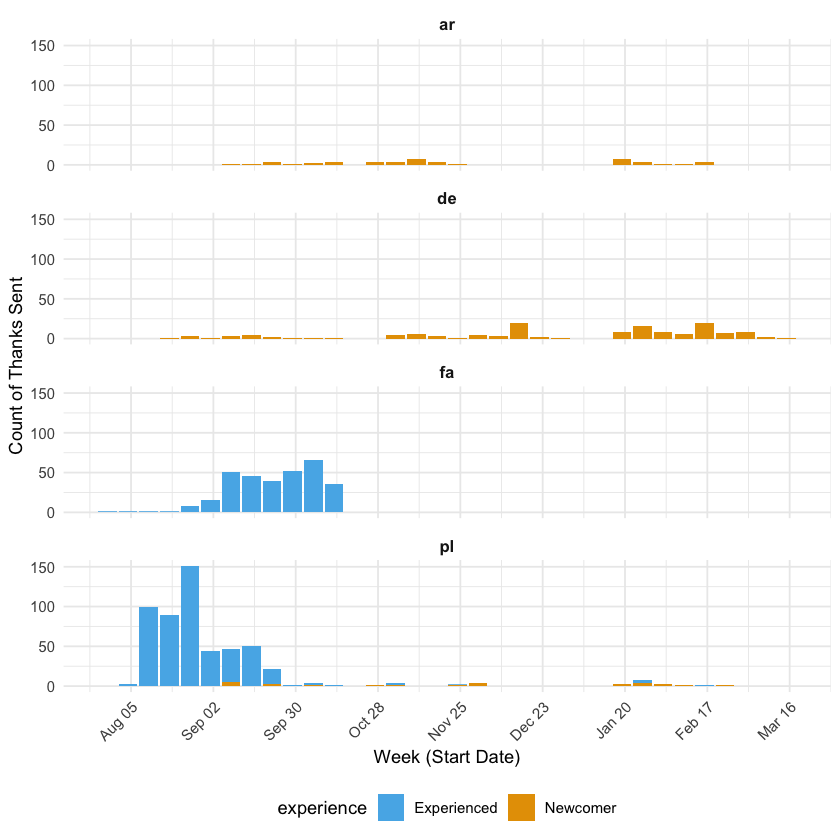

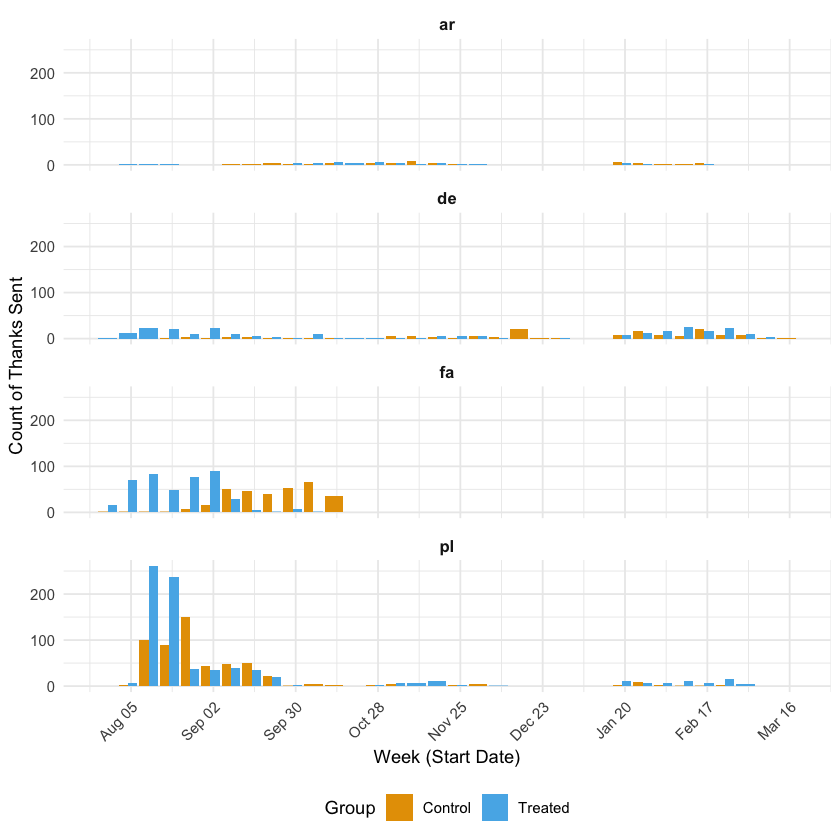

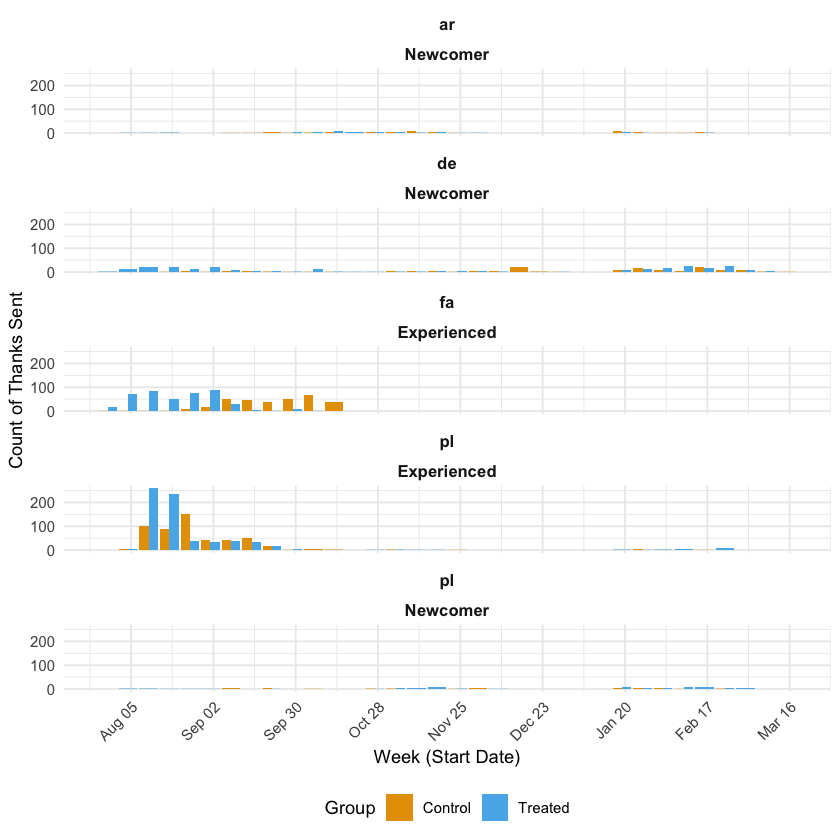

In [37]:
# === SECOND-GEN THANKS PARTITIONED BY WAVE-LEVEL TREATMENT ARM ===
#
# We partition second.gen.data (built in the previous cell with per-wave
# attribution: each event is attached to the *correct* wave the sender was in
# at the moment they sent the thank) by the wave's randomization.arm.
#
# Why this matters: ~66 users are enrolled in BOTH a treated wave and a
# control wave across different language editions. Earlier code that
# built treated/control subsets by joining all.thanks against the entire
# treated.participants and control.participants tables double-counted these
# users' second-gen events (37 events appeared in both subsets). Deriving
# both subsets from second.gen.data eliminates the double count because
# each event has exactly one attributed wave (and therefore exactly one arm).

control.thanks.in.all.thanks <- second.gen.data %>%
  filter(randomization.arm == 0) %>%
  mutate(group = "Control")

treated.thanks.in.all.thanks <- second.gen.data %>%
  filter(randomization.arm == 1) %>%
  mutate(group = "Treated")

# Diagnostic counts -------------------------------------------------------
control.participants <- all.participants.max %>% filter(randomization.arm == 0)
treated.participants <- all.participants.max %>% filter(randomization.arm == 1)

cat("=== Control Group Participants ===\n")
cat("Total control participants:", nrow(control.participants), "\n")
cat("Control participants with thanks.sent > 0:",
    sum(control.participants$thanks.sent > 0, na.rm = TRUE), "\n\n")

cat("Control group second-gen thanks (per-wave attribution):", nrow(control.thanks.in.all.thanks), "\n")
cat("Treated group second-gen thanks (per-wave attribution):", nrow(treated.thanks.in.all.thanks), "\n")
cat("Sum:                                                    ",
    nrow(control.thanks.in.all.thanks) + nrow(treated.thanks.in.all.thanks), "\n")
cat("(Should equal nrow(second.gen.data) =", nrow(second.gen.data),
    "minus rows where randomization.arm is NA)\n\n")

# Combined view used by downstream plots
combined.thanks <- bind_rows(control.thanks.in.all.thanks, treated.thanks.in.all.thanks)

# Summary
cat("\n=== Comparison: Thanks Sent ===\n")
combined.thanks %>%
  group_by(group) %>%
  summarise(
    total_thanks = n(),
    unique_senders = n_distinct(second.gen.sender.user.id.anonymous),
    .groups = "drop"
  ) %>%
  print()

cat("\nBy group, language, and experience:\n")
combined.thanks %>%
  group_by(group, lang.y, experience) %>%
  summarise(count = n(), .groups = "drop") %>%
  tidyr::pivot_wider(names_from = group, values_from = count, values_fill = 0) %>%
  print()


In [ ]:
# Weekly thanks distribution for control group only, by language and experience
p.weekly.control <- control.thanks.in.all.thanks %>%
  mutate(week = floor_date(thank.date, "week")) %>%
  group_by(week, lang.y, experience) %>%
  summarise(count = n(), .groups = "drop") %>%
  ggplot(aes(x = week, y = count, fill = experience)) +
  geom_col(position = "stack") +
  facet_wrap(~lang.y, ncol = 1) +
  scale_x_date(date_labels = "%b %d", date_breaks = "4 weeks") +
  labs(x = "Week (Start Date)", y = "Count of Thanks Sent") +
  scale_fill_manual(values = c("Newcomer" = "#E69F00", "Experienced" = "#56B4E9")) +
  theme_pub

print(p.weekly.control)

# === WEEKLY COMPARISON PLOT: Treated vs Control Thanks Sent ===

p.weekly.comparison <- combined.thanks %>%
  mutate(week = floor_date(thank.date, "week")) %>%
  group_by(week, lang.y, group) %>%
  summarise(count = n(), .groups = "drop") %>%
  ggplot(aes(x = week, y = count, fill = group)) +
  geom_col(position = "dodge") +
  facet_wrap(~lang.y, ncol = 1) +
  scale_x_date(date_labels = "%b %d", date_breaks = "4 weeks") +
  labs(x = "Week (Start Date)", y = "Count of Thanks Sent", fill = "Group") +
  scale_fill_manual(values = c("Control" = "#E69F00", "Treated" = "#56B4E9")) +
  theme_pub

p.weekly.comparison.exp <- combined.thanks %>%
  mutate(week = floor_date(thank.date, "week")) %>%
  group_by(week, lang.y, group, experience) %>%
  summarise(count = n(), .groups = "drop") %>%
  ggplot(aes(x = week, y = count, fill = group)) +
  geom_col(position = "dodge") +
  facet_wrap(~lang.y + experience, ncol = 1) +
  scale_x_date(date_labels = "%b %d", date_breaks = "4 weeks") +
  labs(x = "Week (Start Date)", y = "Count of Thanks Sent",
       fill = "Group") +
  scale_fill_manual(values = c("Control" = "#E69F00", "Treated" = "#56B4E9")) +
  theme_pub

print(p.weekly.comparison)
print(p.weekly.comparison.exp)

ggsave(file.path(figs.dir, "control.group.thanks.pdf"), p.weekly.control, width = 6.5, height = 8, dpi = 300)
ggsave(file.path(figs.dir, "treated.vs.control.thanks.pdf"), p.weekly.comparison, width = 6.5, height = 8, dpi = 300)


# Per-Language Analysis

## Create Study Sub-Samples

In [39]:
newcomers.df <- subset(participants, newcomer==TRUE)
experienced.df <- subset(participants, newcomer==FALSE)
newcomer.compliers.df <- subset(newcomers.df,complier==TRUE)

In [ ]:
df.estimates <- function(df, lang="all", subgroup="all"){

    df.compliers <- subset(df, complier)

    thanks.model.formula <- "thanks.sent ~ TREAT"
    if(lang=="all"){
        thanks.model.formula <- paste(thanks.model.formula, " + lang")
    }

    if(subgroup=="all"){
        thanks.model.formula <- paste(thanks.model.formula, " + newcomer")
    }

    thanks.model         <- glm.nb(thanks.model.formula, data=df)
    m.thanks.sent        <- coef(summary(thanks.model))
    m.thanks.sent        <- data.frame(cbind(m.thanks.sent, confint(thanks.model)))
    names(m.thanks.sent)[4] <- "pvalue"
    names(m.thanks.sent)[5] <- "CI.Lower"
    names(m.thanks.sent)[6] <- "CI.Upper"
    m.thanks.sent$DF       <- thanks.model$df.residual
    m.thanks.sent$model    <- "thanks sent"
    m.thanks.sent$t.value  <- NA
    m.thanks.sent$n.size   <- nrow(df)
    m.thanks.sent$n.thanked.count <- nrow(subset(df, complier.app.any.reason))

    m.retention            <- data.frame(coef(summary(difference_in_means(two.week.retention ~ TREAT, blocks=block, ci=TRUE, data=df))))
    m.retention$model      <- "retention"
    m.retention$z.value    <- NA
    m.retention$n.size     <- nrow(df)
    m.retention$n.thanked.count <- nrow(subset(df, complier.app.any.reason))


# Fit labor hours per day model for this specific subset
if(lang == "all" & subgroup == "all") {
    # For overall analysis, use the full model with random effects
    labor.per.day.formula <- "labor.hours.per.day.post.treatment ~ TREAT*centered.labor.hours.per.day.pre.treatment + (1|block)"
} else {
    # For subgroup analyses, use simpler model without random effects
    labor.per.day.formula <- "labor.hours.per.day.post.treatment ~ TREAT*centered.labor.hours.per.day.pre.treatment"
}

# Check if the variables exist
if(!"centered.labor.hours.per.day.pre.treatment" %in% names(df)) {
    warning("centered.labor.hours.per.day.pre.treatment not found in data, skipping labor hours model")
    m.labor.hours <- NULL
} else {
    labor.per.day.model <- glmmTMB(as.formula(labor.per.day.formula),
                                   data=df,
                                   family=tweedie(link="log"))

    m.labor.hours <- data.frame(coef(summary(labor.per.day.model))$cond)
    m.labor.hours <- m.labor.hours[rownames(m.labor.hours) == "TREAT1", , drop = FALSE]

    # Add confidence intervals
    labor.hours.ci <- confint(labor.per.day.model)
    m.labor.hours$CI.Lower <- labor.hours.ci["TREAT1", "2.5 %"]
    m.labor.hours$CI.Upper <- labor.hours.ci["TREAT1", "97.5 %"]

    m.labor.hours$model <- "labor hours per day"
    m.labor.hours$n.size <- nobs(labor.per.day.model)
    m.labor.hours$n.thanked.count <- nrow(subset(df, complier.app.any.reason))
}

    m.manip.check          <- data.frame(coef(summary(difference_in_means(remembered.thanks<=3 ~ TREAT, ci=TRUE, data=df.compliers))))
    m.manip.check$model    <- "manipulation check"
    m.manip.check$z.value  <- NA
    m.manip.check$n.size   <- nrow(df.compliers)
    m.manip.check$n.thanked.count <-  nrow(subset(df.compliers, complier.app.any.reason))

    names(m.retention)[4]           <- "pvalue"
    names(m.manip.check)[4]         <- "pvalue"
    names(m.labor.hours)[4]         <- "pvalue"

    m.thanks.sent$estimator        <- "glm.nb"
    m.retention$estimator          <- "difference_in_means"
    m.labor.hours$estimator        <- "glmmTMB (Tweedie)"
    m.manip.check$estimator        <- "difference_in_means"

    result.df <- dplyr::bind_rows(m.thanks.sent, m.retention, m.labor.hours, m.manip.check)

    result.df <- result.df[str_detect(row.names(result.df), "TREAT"),]

    result.df[row.names(result.df)!="(Intercept)",]

    result.df$lang     <- lang
    result.df$subgroup <- subgroup

    result.df
}

### Aggregate and Adjust Results for All Participants

In [41]:
all.results <- df.estimates(participants)
# all.results <- subset(all.results, model!="labor hours diff")

# all.newcomer.results <- df.estimates(subset(participants, newcomer), subgroup="newcomer")
# all.results <- dplyr::bind_rows(all.results, subset(all.newcomer.results, model=="labor hours diff"))

## Adjust for multiple comparisons
# adjustment needs to be done at the level of each
# dataframe, since the tests are different for
# different subgroups and languages.
# When doing adjustment for multiple comparisons
# we omit the manipulation check, since it's not
# one of the confirmatory tests

## Note: store the original p values in a list so they can be
## used for later adjustments
all.results.pvalues <- all.results[all.results$model!="manipulation check",]$pvalue


all.results[all.results$model!="manipulation check",]$pvalue <- p.adjust(all.results[all.results$model!="manipulation check",]$pvalue, method="holm")

,model,Estimate,pvalue,CI.Lower,CI.Upper,n.size,estimator,subgroup
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>
TREAT1...2,thanks sent,0.47449898,2.054607e-03,0.18955890,0.76009838,15274,glm.nb,all
TREAT...7,retention,0.02199817,9.329827e-04,0.01004501,0.03395133,15274,difference_in_means,all
TREAT1...8,labor hours per day,0.10476499,1.442745e-02,0.02083261,0.18869738,15274,glmmTMB (Tweedie),all
TREAT...9,manipulation check,0.29205107,2.074219e-16,0.22386500,0.36023713,767,difference_in_means,all


                         model           estimator subgroup n.size   Estimate
TREAT1...2         thanks sent              glm.nb      all  15274 0.47449898
TREAT...7            retention difference_in_means      all  15274 0.02199817
TREAT1...8 labor hours per day   glmmTMB (Tweedie)      all  15274 0.10476499
TREAT...9   manipulation check difference_in_means      all    767 0.29205107
            Std..Error       pvalue
TREAT1...2 0.144534751 2.054607e-03
TREAT...7  0.006097696 9.329827e-04
TREAT1...8 0.042823432 1.442745e-02
TREAT...9  0.034733535 2.074219e-16


In [42]:
all.results[c("model","Estimate", "pvalue", "CI.Lower", "CI.Upper", "n.size", "estimator", "subgroup")]
print(all.results[,c("model", "estimator", "subgroup", "n.size", "Estimate", "Std..Error", "pvalue")])

,Estimate,Std..Error,z.value,pvalue,CI.Lower,CI.Upper,DF,model,t.value,n.size,n.thanked.count,estimator,lang,subgroup
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>
TREAT1...2,0.47449898,0.144534751,3.282940,0.0020546071,0.18955890,0.76009838,15268,thanks sent,NA,15274,2702,glm.nb,all,all
TREAT...7,0.02199817,0.006097696,NA,0.0009329827,0.01004501,0.03395133,7636,retention,3.60762,15274,2702,difference_in_means,all,all
TREAT1...8,0.10476499,0.042823432,2.446441,0.0144274480,0.02083261,0.18869738,NA,labor hours per day,NA,15274,2702,glmmTMB (Tweedie),all,all


In [ ]:
all.results[all.results$model!="manipulation check",]

## Model Diagnostics

agg_record_724176127 
                   2

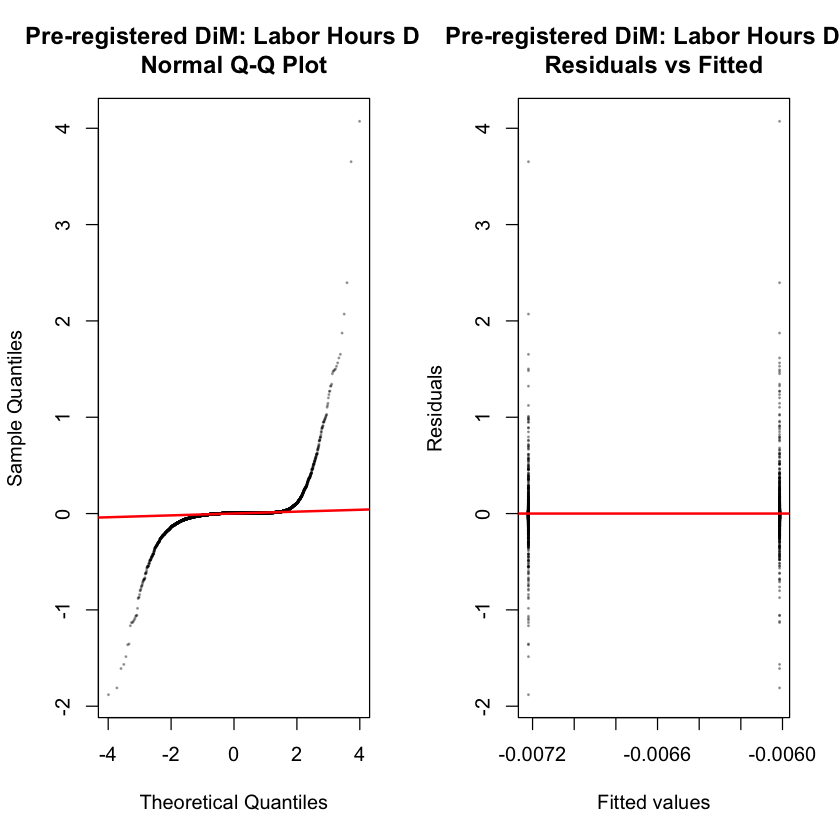

In [44]:
# Post-drop Thanks Sent model + DHARMa diagnostics
thanks.model <- glm.nb(thanks.sent ~ TREAT + lang + newcomer, data = participants)
cat("=== Thanks Sent (glm.nb) — Post-Drop (N =", nrow(participants), ") ===\n")
summary(thanks.model)

sim.thanks <- simulateResiduals(thanks.model, n=1000)
plot(sim.thanks, title="Thanks Sent (Negative Binomial) — Post-Drop")
testDispersion(sim.thanks)
testZeroInflation(sim.thanks)

# Save for SI
png(file.path(figs.dir, "si_diagnostic_thanks_sent.png"), width=1600, height=700, res=150)
plot(sim.thanks, title="Thanks Sent (Negative Binomial)")
dev.off()

In [ ]:
# Pre-registered DiM model on labor hours diff — showing poor fit
# (Motivates switch to Tweedie, cited in Methods)
dim.labor <- lm(labor.hours.per.day.diff ~ TREAT, data = participants)

par(mfrow=c(1,2))
qqnorm(residuals(dim.labor),
       main="Pre-registered DiM: Labor Hours Diff\nNormal Q-Q Plot",
       pch=20, cex=0.3, col=rgb(0,0,0,0.3))
qqline(residuals(dim.labor), col="red", lwd=2)

plot(fitted(dim.labor), residuals(dim.labor),
     main="Pre-registered DiM: Labor Hours Diff\nResiduals vs Fitted",
     xlab="Fitted values", ylab="Residuals",
     pch=20, cex=0.3, col=rgb(0,0,0,0.3))
abline(h=0, col="red", lwd=2)
par(mfrow=c(1,1))

# Save for SI
png(file.path(figs.dir, "si_diagnostic_dim_labor_hours.png"), width=1600, height=700, res=150)
par(mfrow=c(1,2))
qqnorm(residuals(dim.labor),
       main="Pre-registered DiM: Labor Hours Diff\nNormal Q-Q Plot",
       pch=20, cex=0.3, col=rgb(0,0,0,0.3))
qqline(residuals(dim.labor), col="red", lwd=2)
plot(fitted(dim.labor), residuals(dim.labor),
     main="Pre-registered DiM: Labor Hours Diff\nResiduals vs Fitted",
     xlab="Fitted values", ylab="Residuals",
     pch=20, cex=0.3, col=rgb(0,0,0,0.3))
abline(h=0, col="red", lwd=2)
par(mfrow=c(1,1))
dev.off()

## Tweedie Models For Labor Hour Measures That Handle Overdispersion of Zeros

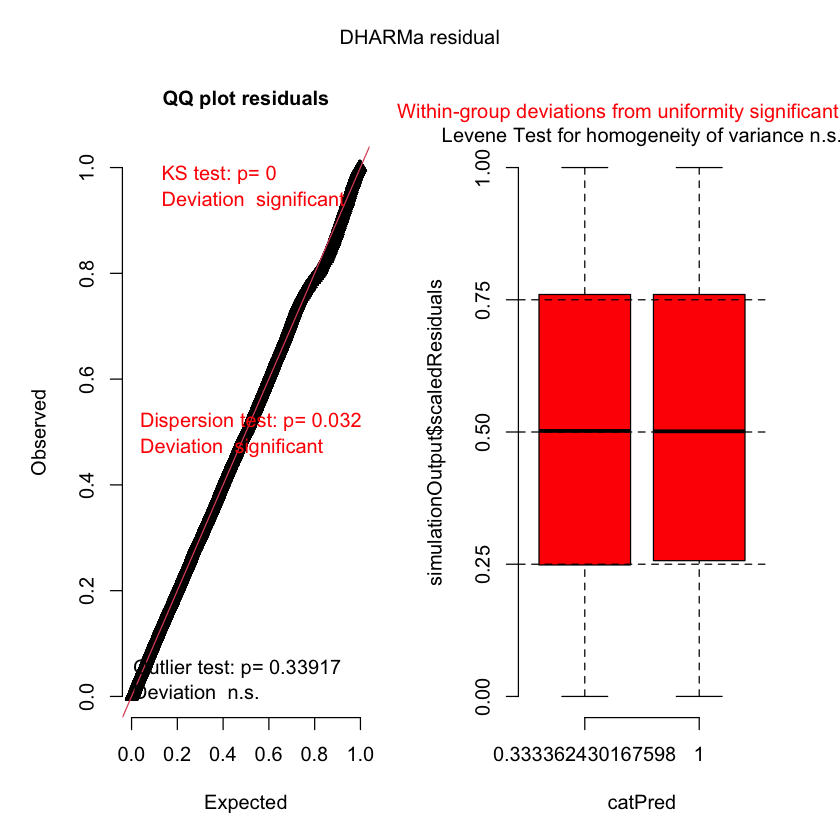

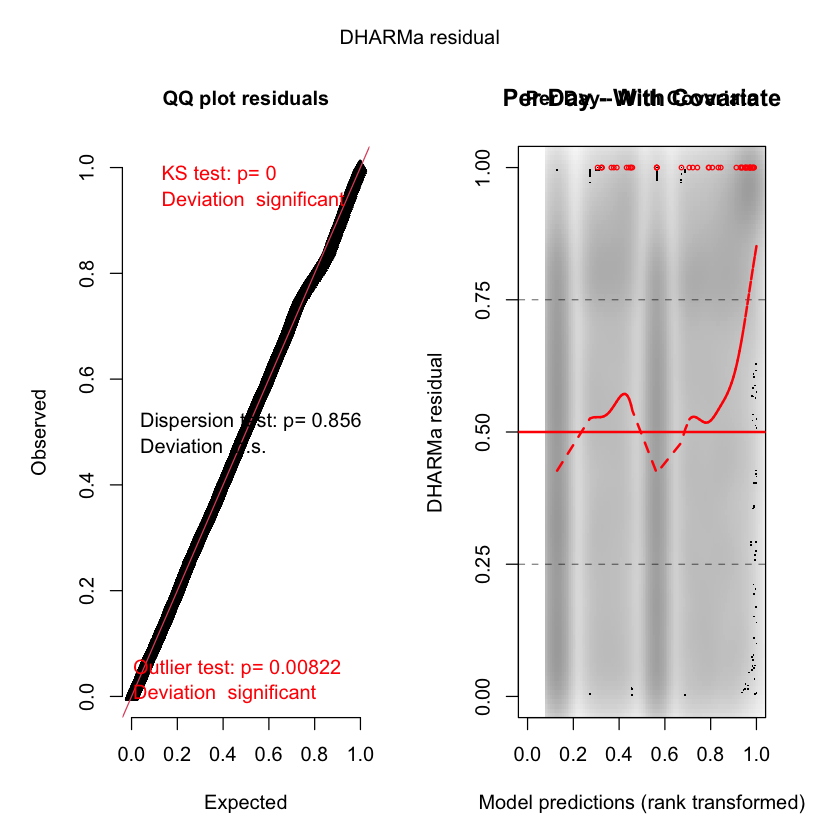

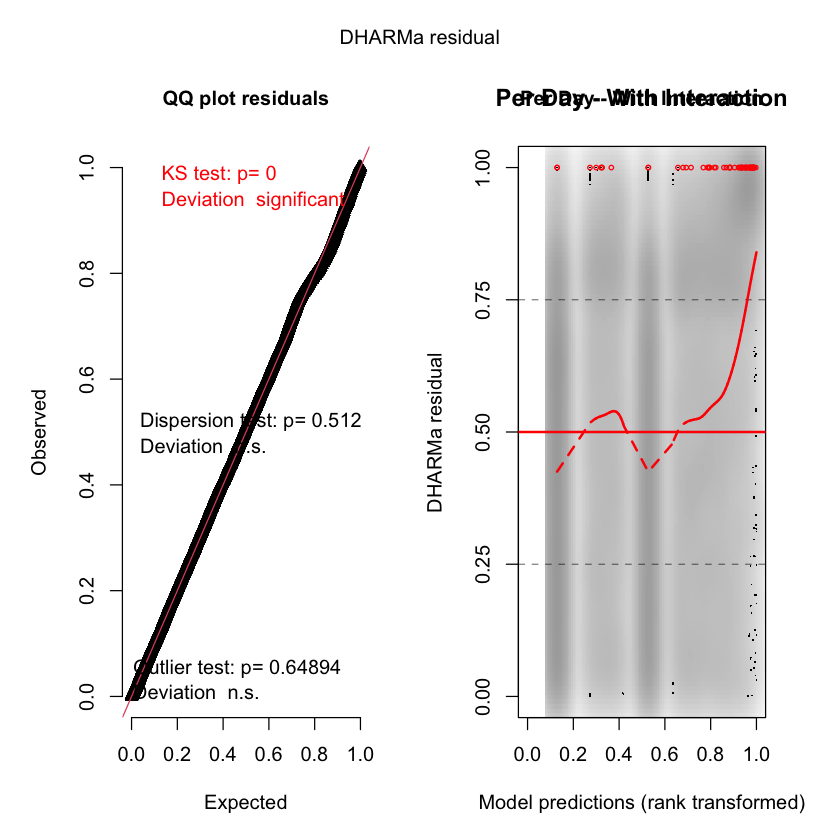


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 0.074886, p-value = 0.032
alternative hypothesis: two.sided


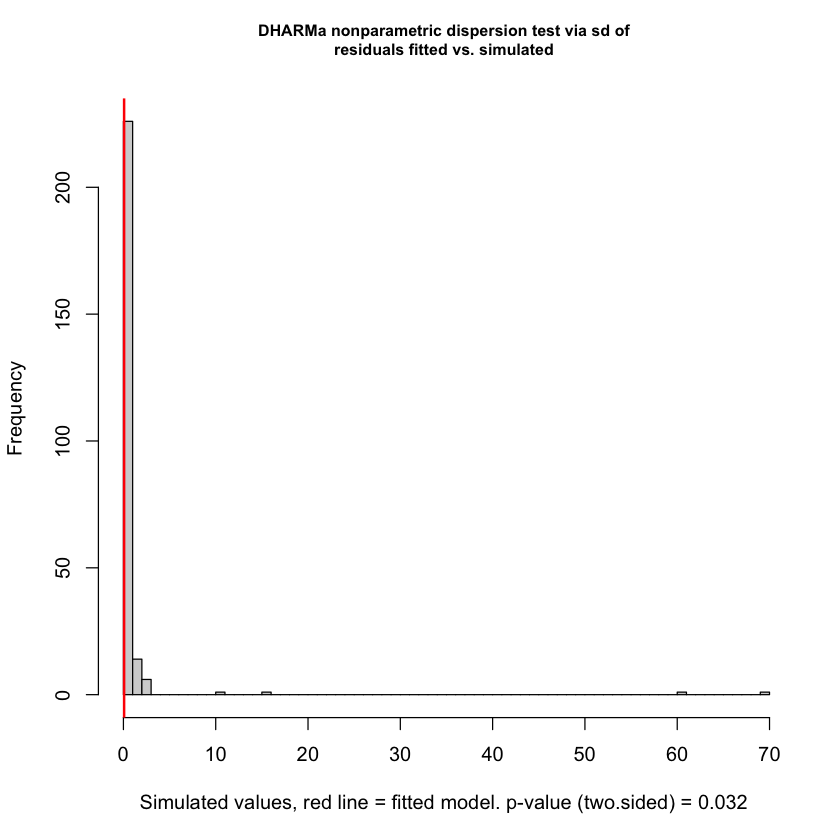


	DHARMa outlier test based on exact binomial test with approximate
	expectations

data:  simRes_tweedie_per_day_baseline
outliers at both margin(s) = 132, observations = 15274, p-value =
0.3392
alternative hypothesis: true probability of success is not equal to 0.007968127
95 percent confidence interval:
 0.007235683 0.010240228
sample estimates:
frequency of outliers (expected: 0.00796812749003984 ) 
                                           0.008642137 


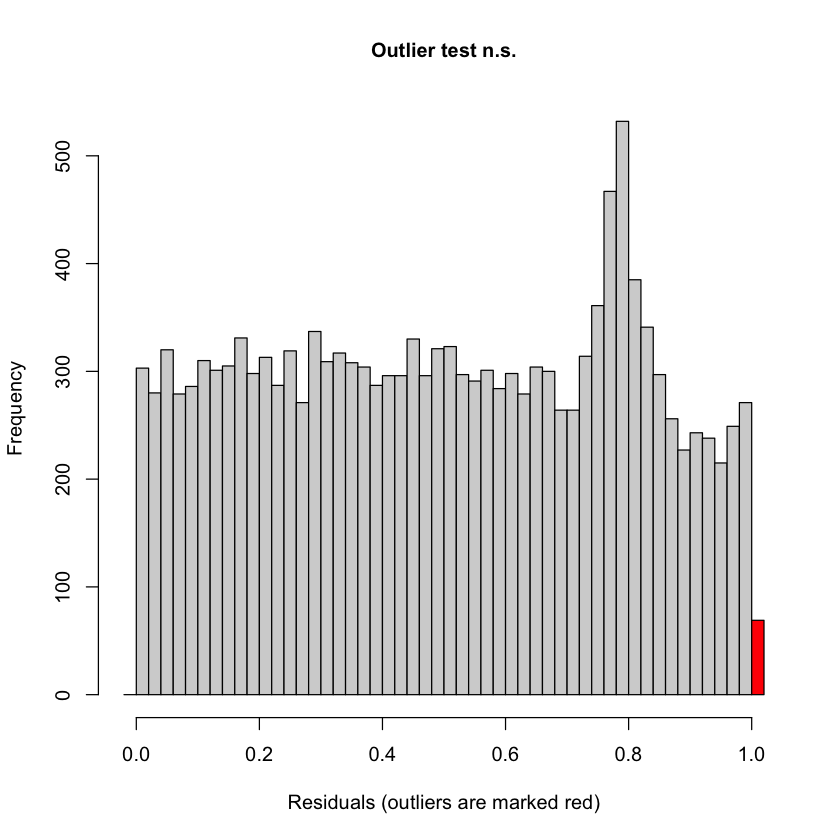


	DHARMa zero-inflation test via comparison to expected zeros with
	simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 0.98941, p-value = 0.04
alternative hypothesis: two.sided


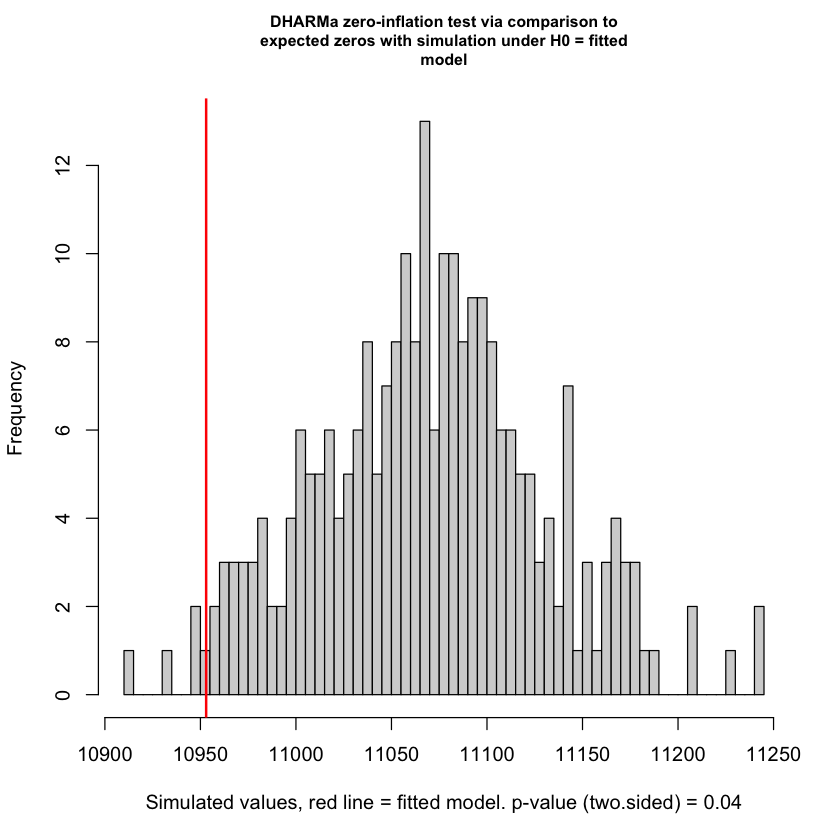


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 0.0017185, p-value = 0.856
alternative hypothesis: two.sided


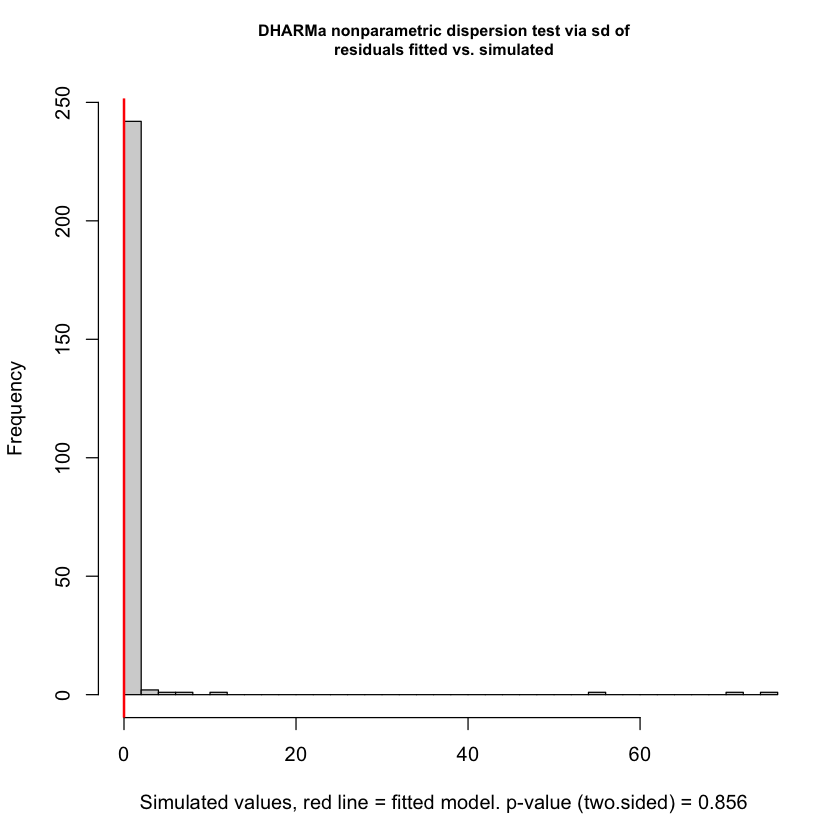


	DHARMa outlier test based on exact binomial test with approximate
	expectations

data:  simRes_tweedie_per_day
outliers at both margin(s) = 93, observations = 15274, p-value =
0.008218
alternative hypothesis: true probability of success is not equal to 0.007968127
95 percent confidence interval:
 0.004917160 0.007454049
sample estimates:
frequency of outliers (expected: 0.00796812749003984 ) 
                                           0.006088778 


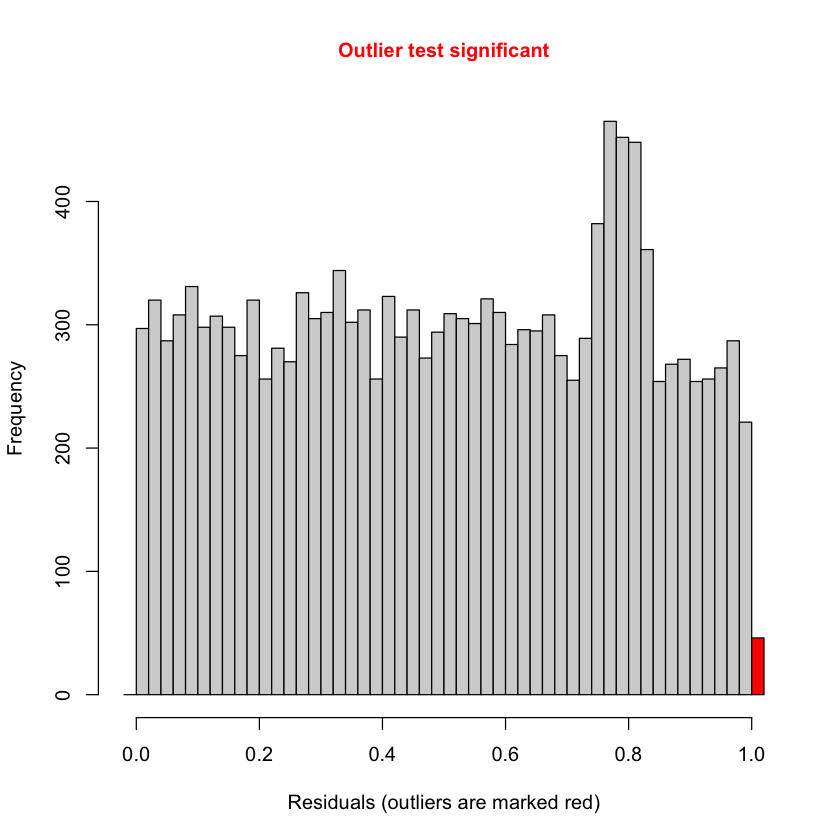


	DHARMa zero-inflation test via comparison to expected zeros with
	simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 0.99077, p-value = 0.08
alternative hypothesis: two.sided


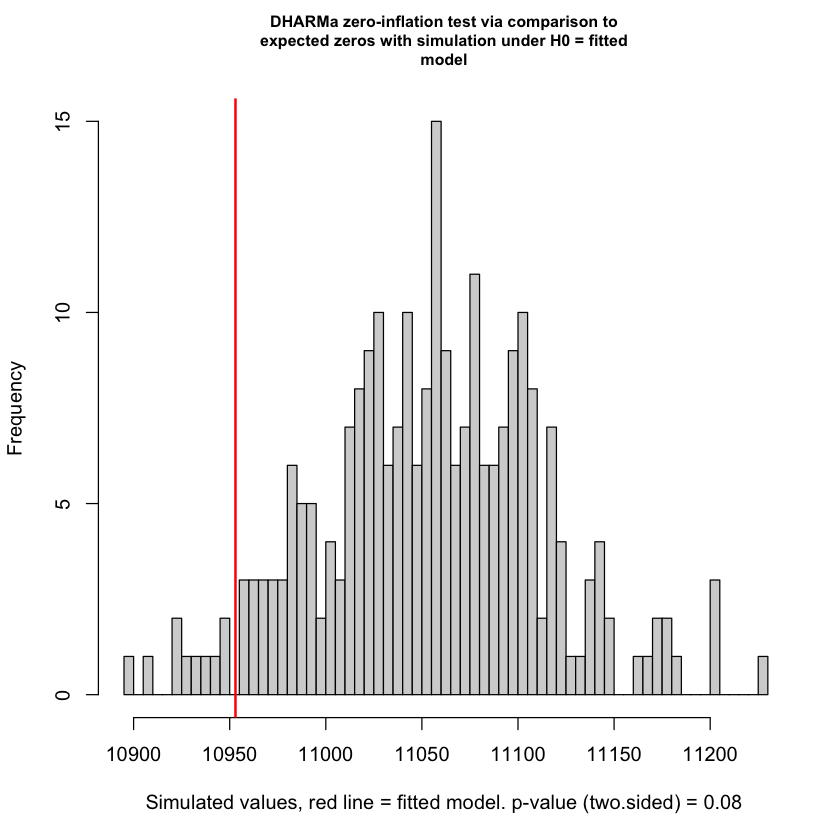


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 0.00038559, p-value = 0.512
alternative hypothesis: two.sided


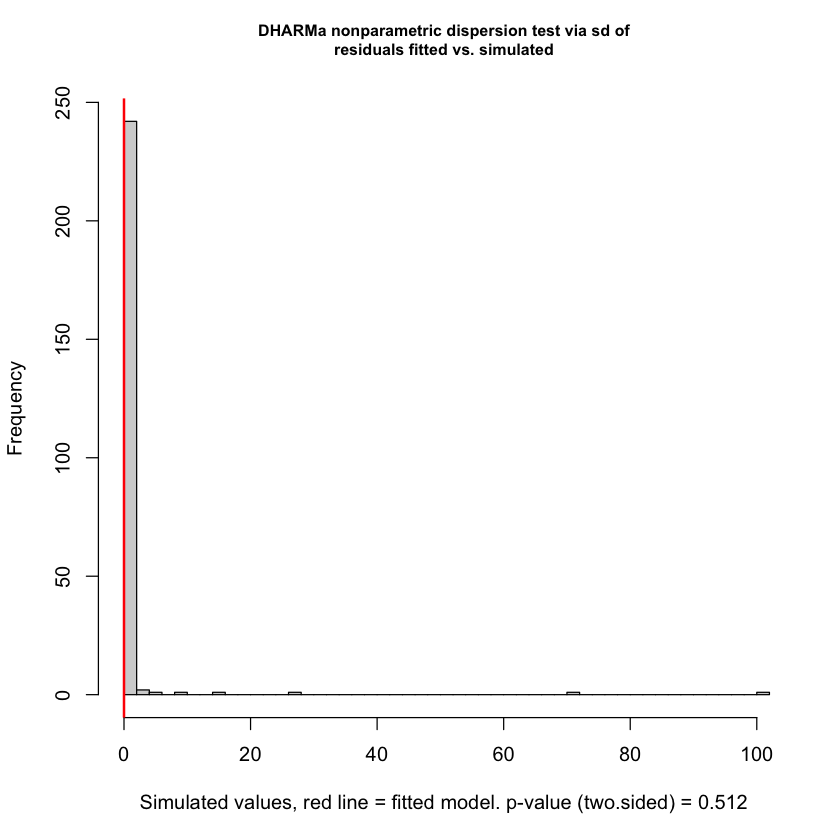


	DHARMa outlier test based on exact binomial test with approximate
	expectations

data:  simRes_tweedie_per_day_int
outliers at both margin(s) = 116, observations = 15274, p-value =
0.6489
alternative hypothesis: true probability of success is not equal to 0.007968127
95 percent confidence interval:
 0.006279512 0.009102099
sample estimates:
frequency of outliers (expected: 0.00796812749003984 ) 
                                           0.007594605 


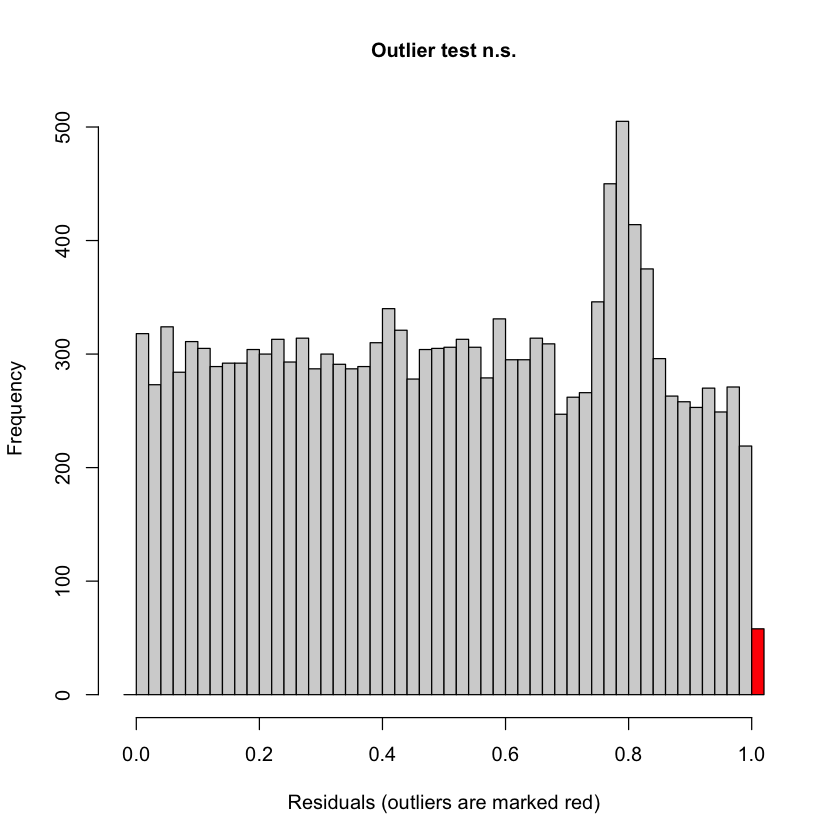


	DHARMa zero-inflation test via comparison to expected zeros with
	simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 0.99084, p-value = 0.12
alternative hypothesis: two.sided


# Comparison of Model Performance Indices

Name                              |   Model | R2 (cond.) | R2 (marg.) |   ICC
-----------------------------------------------------------------------------
lm.labor.per.day.tweedie.int      | glmmTMB |      0.761 |      0.021 | 0.755
lm.labor.per.day.tweedie.baseline | glmmTMB |      0.815 |      0.001 | 0.814
lm.labor.per.day.tweedie          | glmmTMB |      0.764 |      0.019 | 0.759

Name                              |  RMSE | Sigma | AIC weights | AICc weights
------------------------------------------------------------------------------
lm.labor.per.day.tweedie.int      | 0.776 | 0.466 |       1.000 |        1.000
lm.labor.per.day.tweedie.baseline | 0.093 | 0.437 |   8.48e-153 |    8.49e-153
lm.labor.per.day.tweedie          | 1.279 | 0.465 |    3.77e-07 |     3.77e-07

Name                              | BIC weights | Performance-Score
-------------------------------------------------------------------
lm.labor.per.day.tweedie.int      

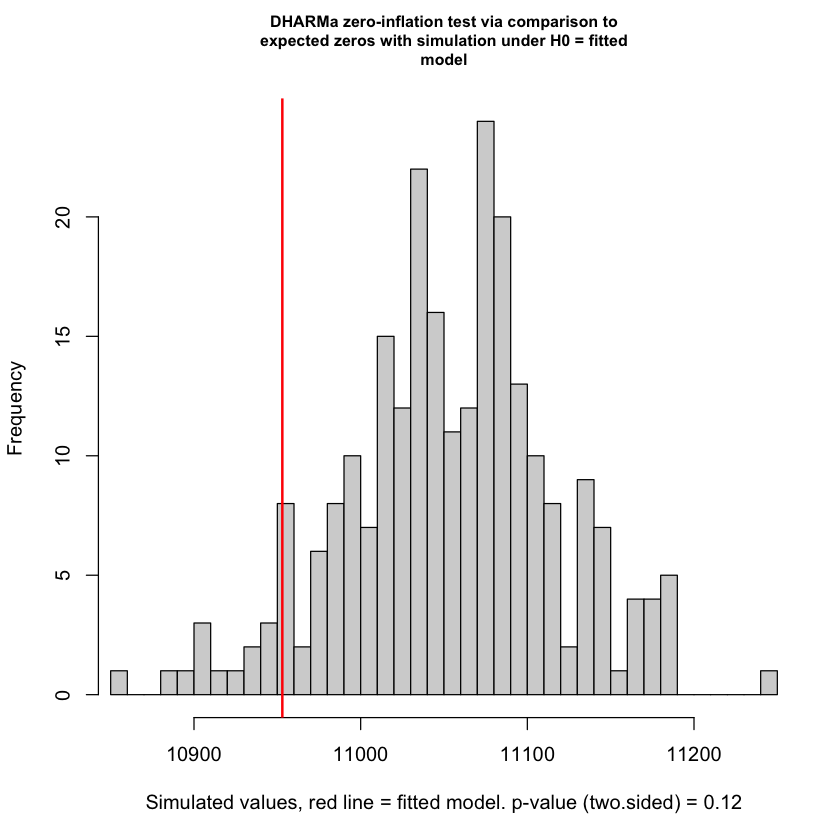

In [46]:
# Labor Hours Per Day Baseline Model
summary(lm.labor.per.day.tweedie.baseline <- glmmTMB(labor.hours.per.day.post.treatment ~ TREAT + (1|block),
                            data = participants,
                            family = tweedie(link = "log")))

# Labor Hours Per Day With Pre Treatment Covariate
summary(lm.labor.per.day.tweedie <- glmmTMB(labor.hours.per.day.post.treatment ~ TREAT + centered.labor.hours.per.day.pre.treatment + (1|block),
                            data = participants,
                            family = tweedie(link = "log")))

# Labor Hours Per Day With Interaction
summary(lm.labor.per.day.tweedie.int <- glmmTMB(labor.hours.per.day.post.treatment ~ TREAT*centered.labor.hours.per.day.pre.treatment + (1|block),
                            data = participants,
                            family = tweedie(link = "log")))

In [ ]:
# Simulate residuals for Labor Hours Per Day
simRes_tweedie_per_day_baseline <- simulateResiduals(lm.labor.per.day.tweedie.baseline)
simRes_tweedie_per_day <- simulateResiduals(lm.labor.per.day.tweedie)
simRes_tweedie_per_day_int <- simulateResiduals(lm.labor.per.day.tweedie.int)

# Diagnostic plots for Labor Hours Per Day
plot(simRes_tweedie_per_day_baseline, main="Per Day - Baseline Model")
plot(simRes_tweedie_per_day, main="Per Day - With Covariate")
plot(simRes_tweedie_per_day_int, main="Per Day - With Interaction")

# Test assumptions for Labor Hours Per Day
# Baseline
testDispersion(simRes_tweedie_per_day_baseline)
testOutliers(simRes_tweedie_per_day_baseline)
testZeroInflation(simRes_tweedie_per_day_baseline)

# Covariate
testDispersion(simRes_tweedie_per_day)
testOutliers(simRes_tweedie_per_day)
testZeroInflation(simRes_tweedie_per_day)

# Interaction
testDispersion(simRes_tweedie_per_day_int)
testOutliers(simRes_tweedie_per_day_int)
testZeroInflation(simRes_tweedie_per_day_int)

# Model Comparison
comp_perday <- compare_performance(lm.labor.per.day.tweedie.baseline,
                                    lm.labor.per.day.tweedie,
                                    lm.labor.per.day.tweedie.int,
                                    rank=TRUE)
print(comp_perday)

# Summary interpretation
best_model_pd_idx <- which.min(c(AIC(lm.labor.per.day.tweedie.baseline),
                                  AIC(lm.labor.per.day.tweedie),
                                  AIC(lm.labor.per.day.tweedie.int)))
best_model_pd_name <- c("Baseline", "With Covariate", "With Interaction")[best_model_pd_idx]

## Separate Tweedie Models for Newcomers and Experienced Contributors

In [ ]:
# Split analysis by newcomer status
# Re-center covariates within each group
newcomers.df$centered.labor.hours.pre.treatment <-
scale(newcomers.df$labor.hours.pre.treatment, center = TRUE, scale = FALSE)

newcomers.df$centered.labor.hours.per.day.pre.treatment <-
scale(newcomers.df$labor.hours.per.day.pre.treatment, center = TRUE, scale = FALSE)

experienced.df$centered.labor.hours.pre.treatment <-
scale(experienced.df$labor.hours.pre.treatment, center = TRUE, scale = FALSE)

experienced.df$centered.labor.hours.per.day.pre.treatment <-
scale(experienced.df$labor.hours.per.day.pre.treatment, center = TRUE, scale = FALSE)

# Check sample size
cat(sprintf("Newcomers: %d\n", nrow(newcomers.df)))
cat(sprintf("Experienced: %d\n", nrow(experienced.df)))

### Newcomer Tweedie Models

In [ ]:
# Labor Hours Per Day - Newcomers
summary(lm.labor.per.day.tweedie.baseline.newcomer <- glmmTMB(
    labor.hours.per.day.post.treatment ~ TREAT + (1 | block),
data = newcomers.df,
family = tweedie(link="log")))

summary(lm.labor.per.day.tweedie.newcomer <- glmmTMB(
    labor.hours.per.day.post.treatment ~ TREAT + centered.labor.hours.per.day.pre.treatment + (1 | block),
data = newcomers.df,
family = tweedie(link="log")))

summary(lm.labor.per.day.tweedie.int.newcomer <- glmmTMB(
    labor.hours.per.day.post.treatment ~ TREAT * centered.labor.hours.per.day.pre.treatment + (1 | block),
data = newcomers.df,
family = tweedie(link="log")))

# Model Comparisons - Newcomers
compare_performance(lm.labor.per.day.tweedie.baseline.newcomer,
                    lm.labor.per.day.tweedie.newcomer,
                    lm.labor.per.day.tweedie.int.newcomer,
                    rank=TRUE)


### Experienced Tweedie Models

In [ ]:
# Labor Hours Per Day - Experienced
summary(lm.labor.per.day.tweedie.baseline.experienced <- glmmTMB(
    labor.hours.per.day.post.treatment ~ TREAT + (1 | block),
data = experienced.df,
family = tweedie(link="log")))

summary(lm.labor.per.day.tweedie.experienced <- glmmTMB(
    labor.hours.per.day.post.treatment ~ TREAT + centered.labor.hours.per.day.pre.treatment + (1 | block),
data = experienced.df,
family = tweedie(link="log")))

summary(lm.labor.per.day.tweedie.int.experienced <- glmmTMB(
    labor.hours.per.day.post.treatment ~ TREAT * centered.labor.hours.per.day.pre.treatment + (1 | block),
data = experienced.df,
family = tweedie(link="log")))

# Model comparison - Experienced
compare_performance(lm.labor.per.day.tweedie.baseline.experienced,
                    lm.labor.per.day.tweedie.experienced,
                    lm.labor.per.day.tweedie.int.experienced,
                    rank=TRUE)

## Check Tweedie Model Diagnostics for the Newcomer Subgroup

In [ ]:
# Simulate residuals for Newcomers - Labor Hours Per Day
simRes_tweedie_per_day_baseline_newcomer <- simulateResiduals(lm.labor.per.day.tweedie.baseline.newcomer)
simRes_tweedie_per_day_newcomer <- simulateResiduals(lm.labor.per.day.tweedie.newcomer)
simRes_tweedie_per_day_int_newcomer <- simulateResiduals(lm.labor.per.day.tweedie.int.newcomer)

# Diagnostic plots for Labor Hours Per Day - Newcomers
plot(simRes_tweedie_per_day_baseline_newcomer, main="Newcomers: Per Day - Baseline")
plot(simRes_tweedie_per_day_newcomer, main="Newcomers: Per Day - Covariate")
plot(simRes_tweedie_per_day_int_newcomer, main="Newcomers: Per Day - Interaction")

# Test assumptions - Baseline
disp_pd_baseline_newc <- testDispersion(simRes_tweedie_per_day_baseline_newcomer)
out_pd_baseline_newc <- testOutliers(simRes_tweedie_per_day_baseline_newcomer)
zero_pd_baseline_newc <- testZeroInflation(simRes_tweedie_per_day_baseline_newcomer)

cat(sprintf("  Dispersion: dispersion = %.3f, p = %.4f %s\n",
            disp_pd_baseline_newc$statistic,
            disp_pd_baseline_newc$p.value,
            ifelse(disp_pd_baseline_newc$p.value < 0.05, "[PROBLEM]", "[OK]")))
cat(sprintf("  Outliers: p = %.4f %s\n",
            out_pd_baseline_newc$p.value,
            ifelse(out_pd_baseline_newc$p.value < 0.05, "[PROBLEM]", "[OK]")))
cat(sprintf("  Zero-Inflation: p = %.4f %s\n\n",
            zero_pd_baseline_newc$p.value,
            ifelse(zero_pd_baseline_newc$p.value < 0.05, "[PROBLEM]", "[OK]")))

# Test assumptions - Covariate
disp_pd_cov_newc <- testDispersion(simRes_tweedie_per_day_newcomer)
out_pd_cov_newc <- testOutliers(simRes_tweedie_per_day_newcomer)
zero_pd_cov_newc <- testZeroInflation(simRes_tweedie_per_day_newcomer)

cat(sprintf("  Dispersion: dispersion = %.3f, p = %.4f %s\n",
            disp_pd_cov_newc$statistic,
            disp_pd_cov_newc$p.value,
            ifelse(disp_pd_cov_newc$p.value < 0.05, "[PROBLEM]", "[OK]")))
cat(sprintf("  Outliers: p = %.4f %s\n",
            out_pd_cov_newc$p.value,
            ifelse(out_pd_cov_newc$p.value < 0.05, "[PROBLEM]", "[OK]")))
cat(sprintf("  Zero-Inflation: p = %.4f %s\n\n",
            zero_pd_cov_newc$p.value,
            ifelse(zero_pd_cov_newc$p.value < 0.05, "[PROBLEM]", "[OK]")))

# Test assumptions - Interaction
disp_pd_int_newc <- testDispersion(simRes_tweedie_per_day_int_newcomer)
out_pd_int_newc <- testOutliers(simRes_tweedie_per_day_int_newcomer)
zero_pd_int_newc <- testZeroInflation(simRes_tweedie_per_day_int_newcomer)

cat(sprintf("  Dispersion: dispersion = %.3f, p = %.4f %s\n",
            disp_pd_int_newc$statistic,
            disp_pd_int_newc$p.value,
            ifelse(disp_pd_int_newc$p.value < 0.05, "[PROBLEM]", "[OK]")))
cat(sprintf("  Outliers: p = %.4f %s\n",
            out_pd_int_newc$p.value,
            ifelse(out_pd_int_newc$p.value < 0.05, "[PROBLEM]", "[OK]")))
cat(sprintf("  Zero-Inflation: p = %.4f %s\n\n",
            zero_pd_int_newc$p.value,
            ifelse(zero_pd_int_newc$p.value < 0.05, "[PROBLEM]", "[OK]")))

## Check Tweedie Model Diagnostics for Experienced Subgroup

In [52]:
# Simulate residuals for Experienced - Labor Hours Per Day
simRes_tweedie_per_day_baseline_exp <- simulateResiduals(lm.labor.per.day.tweedie.baseline.experienced)
simRes_tweedie_per_day_exp <- simulateResiduals(lm.labor.per.day.tweedie.experienced)
simRes_tweedie_per_day_int_exp <- simulateResiduals(lm.labor.per.day.tweedie.int.experienced)

# Diagnostic plots for Labor Hours Per Day - Experienced
plot(simRes_tweedie_per_day_baseline_exp, main="Experienced: Per Day - Baseline")
plot(simRes_tweedie_per_day_exp, main="Experienced: Per Day - With Covariate")
plot(simRes_tweedie_per_day_int_exp, main="Experienced: Per Day - Interaction")

# Test assumptions - Baseline
disp_pd_baseline_exp <- testDispersion(simRes_tweedie_per_day_baseline_exp)
out_pd_baseline_exp <- testOutliers(simRes_tweedie_per_day_baseline_exp)
zero_pd_baseline_exp <- testZeroInflation(simRes_tweedie_per_day_baseline_exp)

cat(sprintf("  Dispersion: dispersion = %.3f, p = %.4f %s\n",
            disp_pd_baseline_exp$statistic,
            disp_pd_baseline_exp$p.value,
            ifelse(disp_pd_baseline_exp$p.value < 0.05, "[PROBLEM]", "[OK]")))
cat(sprintf("  Outliers: p = %.4f %s\n",
            out_pd_baseline_exp$p.value,
            ifelse(out_pd_baseline_exp$p.value < 0.05, "[PROBLEM]", "[OK]")))
cat(sprintf("  Zero-Inflation: p = %.4f %s\n\n",
            zero_pd_baseline_exp$p.value,
            ifelse(zero_pd_baseline_exp$p.value < 0.05, "[PROBLEM]", "[OK]")))

# Test assumptions - Covariate
disp_pd_cov_exp <- testDispersion(simRes_tweedie_per_day_exp)
out_pd_cov_exp <- testOutliers(simRes_tweedie_per_day_exp)
zero_pd_cov_exp <- testZeroInflation(simRes_tweedie_per_day_exp)

cat(sprintf("  Dispersion: dispersion = %.3f, p = %.4f %s\n",
            disp_pd_cov_exp$statistic,
            disp_pd_cov_exp$p.value,
            ifelse(disp_pd_cov_exp$p.value < 0.05, "[PROBLEM]", "[OK]")))
cat(sprintf("  Outliers: p = %.4f %s\n",
            out_pd_cov_exp$p.value,
            ifelse(out_pd_cov_exp$p.value < 0.05, "[PROBLEM]", "[OK]")))
cat(sprintf("  Zero-Inflation: p = %.4f %s\n\n",
            zero_pd_cov_exp$p.value,
            ifelse(zero_pd_cov_exp$p.value < 0.05, "[PROBLEM]", "[OK]")))

# Test assumptions - Interaction
disp_pd_int_exp <- testDispersion(simRes_tweedie_per_day_int_exp)
out_pd_int_exp <- testOutliers(simRes_tweedie_per_day_int_exp)
zero_pd_int_exp <- testZeroInflation(simRes_tweedie_per_day_int_exp)

cat(sprintf("  Dispersion: dispersion = %.3f, p = %.4f %s\n",
            disp_pd_int_exp$statistic,
            disp_pd_int_exp$p.value,
            ifelse(disp_pd_int_exp$p.value < 0.05, "[PROBLEM]", "[OK]")))
cat(sprintf("  Outliers: p = %.4f %s\n",
            out_pd_int_exp$p.value,
            ifelse(out_pd_int_exp$p.value < 0.05, "[PROBLEM]", "[OK]")))
cat(sprintf("  Zero-Inflation: p = %.4f %s\n\n",
            zero_pd_int_exp$p.value,
            ifelse(zero_pd_int_exp$p.value < 0.05, "[PROBLEM]", "[OK]")))

                 model         estimator    subgroup n.size
1  labor hours per day glmmTMB (Tweedie)         all  15274
2  labor hours per day glmmTMB (Tweedie)         all  15274
3  labor hours per day glmmTMB (Tweedie)         all  15274
4  labor hours per day glmmTMB (Tweedie)         all  15274
5  labor hours per day glmmTMB (Tweedie)    newcomer   9984
6  labor hours per day glmmTMB (Tweedie)    newcomer   9984
7  labor hours per day glmmTMB (Tweedie)    newcomer   9984
8  labor hours per day glmmTMB (Tweedie)    newcomer   9984
9  labor hours per day glmmTMB (Tweedie) experienced   5290
10 labor hours per day glmmTMB (Tweedie) experienced   5290
11 labor hours per day glmmTMB (Tweedie) experienced   5290
12 labor hours per day glmmTMB (Tweedie) experienced   5290
                                           predictor    Estimate Std..Error
1                                        (Intercept) -6.03952634 0.05495529
2                                             TREAT1  0.10476499 0.0

In [53]:
# Extract coefficients from the three models
extract_model_coefs <- function(model, model_name, subgroup) {
  coef_summary <- coef(summary(model))$cond  # Extract conditional model coefficients

  result <- data.frame(
    model = model_name,
    estimator = "glmmTMB (Tweedie)",
    subgroup = subgroup,
    n.size = nobs(model),
    predictor = rownames(coef_summary),
    Estimate = coef_summary[, "Estimate"],
    Std..Error = coef_summary[, "Std. Error"],
    pvalue = coef_summary[, "Pr(>|z|)"],
    row.names = NULL
  )

  return(result)
}

# Combine results from all three models
labor_per_day_results <- rbind(
  extract_model_coefs(lm.labor.per.day.tweedie.int,
                      "labor hours per day",
                      "all"),
  extract_model_coefs(lm.labor.per.day.tweedie.int.newcomer,
                      "labor hours per day",
                      "newcomer"),
  extract_model_coefs(lm.labor.per.day.tweedie.int.experienced,
                      "labor hours per day",
                      "experienced")
)

# Print the table
print(labor_per_day_results[, c("model", "estimator", "subgroup", "n.size",
                                 "predictor", "Estimate", "Std..Error", "pvalue")])

In [ ]:
save(all.results, labor_per_day_results, file = file.path(rdata.out, "ITT_table.RData"), version = 2)

# Generate Sub-Group Analyses w/ Language
Along the way, adjust for multiple comparisons

In [55]:
ar.newcomer.results <- df.estimates(subset(participants, lang=="ar" & newcomer), lang="ar", subgroup="newcomer")
de.newcomer.results <- df.estimates(subset(participants, lang=="de" & newcomer), lang="de", subgroup="newcomer")
pl.newcomer.results <- df.estimates(subset(participants, lang=="pl" & newcomer), lang="pl", subgroup="newcomer")



Waiting for profiling to be done...

Waiting for profiling to be done...



In [56]:
fa.experienced.results <- df.estimates(subset(participants, lang=="fa" & newcomer!=TRUE), lang="fa", subgroup="experienced")


pl.experienced.results <- df.estimates(subset(participants, lang=="pl" & newcomer!=TRUE), lang="pl", subgroup="experienced")


In [57]:
ar.newcomer.results[ar.newcomer.results$model!="manipulation check",]$pvalue <-
        p.adjust(ar.newcomer.results[ar.newcomer.results$model!="manipulation check",]$pvalue, method="holm")

de.newcomer.results[de.newcomer.results$model!="manipulation check",]$pvalue <-
        p.adjust(de.newcomer.results[de.newcomer.results$model!="manipulation check",]$pvalue, method="holm")

pl.newcomer.results[pl.newcomer.results$model!="manipulation check",]$pvalue <-
        p.adjust(pl.newcomer.results[pl.newcomer.results$model!="manipulation check",]$pvalue, method="holm")

fa.experienced.results[fa.experienced.results$model!="manipulation check",]$pvalue <-
        p.adjust(fa.experienced.results[fa.experienced.results$model!="manipulation check",]$pvalue, method="holm")

pl.experienced.results[pl.experienced.results$model!="manipulation check",]$pvalue <-
        p.adjust(pl.experienced.results[pl.experienced.results$model!="manipulation check",]$pvalue, method="holm")

Waiting for profiling to be done...

Waiting for profiling to be done...



,Estimate,Std..Error,z.value,pvalue,CI.Lower,CI.Upper,DF,model,t.value,n.size,n.thanked.count,estimator,lang,subgroup
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>
TREAT1...2,0.405465108,0.435633350,0.93074855,3.519836e-01,-0.451335451,1.26633115,3034.00000,thanks sent,NA,3036,189,glm.nb,ar,newcomer
TREAT...3,0.027009223,0.011373685,NA,5.305927e-02,0.004699410,0.04931904,1517.00000,retention,2.3747117,3036,189,difference_in_means,ar,newcomer
TREAT1...4,-0.210701339,0.150987581,-1.39548788,3.257375e-01,-0.506631561,0.08522888,NA,labor hours per day,NA,3036,189,glmmTMB (Tweedie),ar,newcomer
TREAT...5,0.200000000,0.210818511,NA,3.558411e-01,-0.244186588,0.64418659,17.30769,manipulation check,0.9486833,22,11,difference_in_means,ar,newcomer
TREAT1...21,0.656242624,0.260767478,2.51658155,3.554984e-02,0.143836569,1.16935924,5316.00000,thanks sent,NA,5318,1268,glm.nb,de,newcomer
TREAT...31,0.016923656,0.010192528,NA,9.695231e-02,-0.003062433,0.03690974,2658.00000,retention,1.6603983,5318,1268,difference_in_means,de,newcomer
TREAT1...41,0.238990975,0.098793972,2.41908459,3.554984e-02,0.045358348,0.43262360,NA,labor hours per day,NA,5318,1268,glmmTMB (Tweedie),de,newcomer
TREAT...51,0.369369369,0.077406029,NA,4.445988e-06,0.216366084,0.52237265,143.50657,manipulation check,4.7718424,146,74,difference_in_means,de,newcomer
TREAT1...22,0.896746136,0.449821136,1.99356158,9.239997e-02,0.010757175,1.78801209,1628.00000,thanks sent,NA,1630,115,glm.nb,pl,newcomer


In [ ]:

# Create pooled subgroup results for newcomers and experienced contributors
all.newcomer.results <- df.estimates(subset(participants, newcomer), subgroup="newcomer")
all.newcomer.results[all.newcomer.results$model!="manipulation check",]$pvalue <-
        p.adjust(all.newcomer.results[all.newcomer.results$model!="manipulation check",]$pvalue, method="holm")

all.experienced.results <- df.estimates(subset(participants, newcomer!=TRUE), subgroup="experienced")
all.experienced.results[all.experienced.results$model!="manipulation check",]$pvalue <-
        p.adjust(all.experienced.results[all.experienced.results$model!="manipulation check",]$pvalue, method="holm")


all.lang.results <- rbind(ar.newcomer.results, de.newcomer.results,
                          pl.newcomer.results, fa.experienced.results,
                          pl.experienced.results, all.newcomer.results,
                          all.experienced.results, all.results)

all.lang.results

## Combined DHARMa Diagnostic Panel (Figure S6)

The notebook already produced `figs/si_diagnostic_thanks_sent.png` (Figure S4) and `figs/si_diagnostic_dim_labor_hours.png` (Figure S5) earlier. This section adds the combined Tweedie-GLMM diagnostic panel (Figure S6) — a 2x3 layout with QQ plots and residuals-vs-predicted for the All / Newcomer / Experienced subgroups.

In [ ]:
suppressPackageStartupMessages({
  library(glmmTMB)
  library(DHARMa)
})

# Helper: refit Tweedie interaction model on a subgroup, simulate residuals
fit_tweedie_and_simulate <- function(df, label) {
  df$centered.labor.hours.per.day.pre.treatment <-
    df$labor.hours.per.day.pre.treatment - mean(df$labor.hours.per.day.pre.treatment, na.rm=TRUE)
  m <- glmmTMB(
    labor.hours.per.day.post.treatment ~
      TREAT * centered.labor.hours.per.day.pre.treatment + (1|block),
    data = df,
    family = tweedie(link="log")
  )
  cat(sprintf("  %-15s n=%d fitted\n", label, nobs(m)))
  list(model = m, sim = simulateResiduals(m, n = 1000))
}

cat("Refitting Tweedie interaction models for combined diagnostic panel:\n")
diag.all <- fit_tweedie_and_simulate(participants,    "All")
diag.new <- fit_tweedie_and_simulate(newcomers.df,    "Newcomers")
diag.exp <- fit_tweedie_and_simulate(experienced.df,  "Experienced")

png(file.path(figs.dir, "si_diagnostic_combined.png"),
    width = 2400, height = 1800, res = 150)
par(mfrow = c(2, 3), mar = c(5, 5, 6, 2))
plotQQunif(diag.all$sim, main = "All Participants")
plotQQunif(diag.new$sim, main = "Newcomers")
plotQQunif(diag.exp$sim, main = "Experienced")
plotResiduals(diag.all$sim, main = "")
plotResiduals(diag.new$sim, main = "")
plotResiduals(diag.exp$sim, main = "")
par(mfrow = c(1, 1))
dev.off()
cat("Generated", file.path(figs.dir, "si_diagnostic_combined.png"), "\n")


## Labor Hours Interaction Plot (Figure S3)

Visualizes the differential treatment effect on labor hours per day across pre-treatment activity levels, separately for newcomers and experienced contributors. Coefficients are extracted from the already-fitted `lm.labor.per.day.tweedie.int.newcomer` and `lm.labor.per.day.tweedie.int.experienced` models fitted earlier in this section.

In [60]:
suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(patchwork)
})

# Extract coefficients from the already-fitted Tweedie interaction models
nc_coef <- coef(summary(lm.labor.per.day.tweedie.int.newcomer))$cond
ex_coef <- coef(summary(lm.labor.per.day.tweedie.int.experienced))$cond
INTER_TERM <- "TREAT1:centered.labor.hours.per.day.pre.treatment"

newcomer_treat       <- nc_coef["TREAT1", "Estimate"]
newcomer_treat_se    <- nc_coef["TREAT1", "Std. Error"]
newcomer_interaction <- nc_coef[INTER_TERM, "Estimate"]
newcomer_interaction_se <- nc_coef[INTER_TERM, "Std. Error"]

experienced_treat       <- ex_coef["TREAT1", "Estimate"]
experienced_treat_se    <- ex_coef["TREAT1", "Std. Error"]
experienced_interaction <- ex_coef[INTER_TERM, "Estimate"]
experienced_interaction_se <- ex_coef[INTER_TERM, "Std. Error"]

cat(sprintf("Newcomer:    TREAT=%.4f (SE=%.4f)  INT=%.4f (SE=%.4f)\n",
            newcomer_treat, newcomer_treat_se,
            newcomer_interaction, newcomer_interaction_se))
cat(sprintf("Experienced: TREAT=%.4f (SE=%.4f)  INT=%.4f (SE=%.4f)\n",
            experienced_treat, experienced_treat_se,
            experienced_interaction, experienced_interaction_se))

x_min <- -0.03111
x_max <- 0.5
pre_treatment_range <- seq(x_min, x_max, by = 0.02)

calculate_ci <- function(pre_hours, treat_coef, treat_se, interaction_coef, interaction_se) {
  log_ratio <- treat_coef + interaction_coef * pre_hours
  se_log_ratio <- sqrt(treat_se^2 + (pre_hours^2) * interaction_se^2)
  lower_log <- log_ratio - 2.576 * se_log_ratio
  upper_log <- log_ratio + 2.576 * se_log_ratio
  list(estimate = (exp(log_ratio) - 1) * 100,
       lower    = (exp(lower_log) - 1) * 100,
       upper    = (exp(upper_log) - 1) * 100)
}

newcomer_ci    <- calculate_ci(pre_treatment_range, newcomer_treat,    newcomer_treat_se,
                               newcomer_interaction, newcomer_interaction_se)
experienced_ci <- calculate_ci(pre_treatment_range, experienced_treat, experienced_treat_se,
                               experienced_interaction, experienced_interaction_se)

results_long <- rbind(
  data.frame(centered_pre_treatment_per_day = pre_treatment_range,
             percentage_impact = newcomer_ci$estimate,
             lower = newcomer_ci$lower, upper = newcomer_ci$upper,
             group = "Newcomers"),
  data.frame(centered_pre_treatment_per_day = pre_treatment_range,
             percentage_impact = experienced_ci$estimate,
             lower = experienced_ci$lower, upper = experienced_ci$upper,
             group = "Experienced Contributors")
) |>
  mutate(group = factor(group, levels = c("Newcomers", "Experienced Contributors")))


Generated ../figs/interaction_effect_marginal_histogram.png 


In [ ]:
# Histogram data for the marginal-density panel
newcomers.df$centered.labor.hours.per.day.pre.treatment <-
  as.vector(scale(newcomers.df$labor.hours.per.day.pre.treatment, center = TRUE, scale = FALSE))
experienced.df$centered.labor.hours.per.day.pre.treatment <-
  as.vector(scale(experienced.df$labor.hours.per.day.pre.treatment, center = TRUE, scale = FALSE))

hist_data <- rbind(
  data.frame(centered_pre_treatment_per_day = newcomers.df$centered.labor.hours.per.day.pre.treatment,
             group = "Newcomers"),
  data.frame(centered_pre_treatment_per_day = experienced.df$centered.labor.hours.per.day.pre.treatment,
             group = "Experienced Contributors")
) |>
  filter(centered_pre_treatment_per_day >= x_min & centered_pre_treatment_per_day <= x_max) |>
  mutate(group = factor(group, levels = c("Newcomers", "Experienced Contributors")))

palette <- c("Newcomers" = "#E69F00", "Experienced Contributors" = "#56B4E9")

p_main <- ggplot(results_long,
                 aes(x = centered_pre_treatment_per_day,
                     y = percentage_impact, color = group, fill = group)) +
  geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.15, color = NA) +
  geom_line(linewidth = 1.8) +
  geom_hline(yintercept = 0, color = "black", linewidth = 0.7) +
  geom_vline(xintercept = 0, color = "black", linewidth = 0.7) +
  coord_cartesian(xlim = c(x_min, x_max)) +
  labs(x = "Centered Labor Hours Per Day (Pre-Treatment)",
       y = "Percentage Change in Post-Treatment\nLabor Hours Per Day (%)",
       color = "Contributor Type", fill = "Contributor Type") +
  scale_color_manual(values = palette, name = "Contributor Type") +
  scale_fill_manual(values = palette,  name = "Contributor Type") +
  guides(color = guide_legend(override.aes = list(fill = NA)), fill = "none") +
  theme_minimal(base_size = 12) +
  theme(plot.background = element_rect(fill = "white", color = NA),
        panel.background = element_rect(fill = "white", color = NA),
        legend.position = "bottom",
        legend.title = element_text(face = "bold", size = 11),
        legend.background = element_rect(fill = "white", color = "gray80", linewidth = 0.5),
        legend.key.width = unit(1.5, "cm"),
        panel.grid.minor = element_blank(),
        axis.title = element_text(face = "bold", size = 11))

p_hist <- ggplot(hist_data, aes(x = centered_pre_treatment_per_day, fill = group)) +
  geom_histogram(alpha = 0.7, position = "identity", bins = 40, color = NA) +
  scale_fill_manual(values = palette) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05)), labels = scales::comma) +
  coord_cartesian(xlim = c(x_min, x_max)) +
  labs(x = NULL, y = "Participant\nCount") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none",
        plot.background = element_rect(fill = "white", color = NA),
        panel.background = element_rect(fill = "white", color = NA),
        panel.grid.minor = element_blank(),
        panel.grid.major.x = element_blank(),
        axis.text.x = element_blank(), axis.ticks.x = element_blank(),
        axis.title.x = element_blank(),
        axis.title.y = element_text(face = "bold", size = 9))

p_marginal <- (p_hist / p_main) +
  plot_layout(heights = c(1, 3)) &
  theme(plot.background = element_rect(fill = "white", color = NA))
p_marginal <- p_marginal +
  plot_annotation(
    title = "Treatment Effect on Labor Hours Per Day: Interaction with Pre-Treatment Activity",
    subtitle = "Impact of receiving thanks (treatment vs. control) by contributor experience level (shaded areas show 99% CI)",
    theme = theme(plot.title = element_text(face = "bold", size = 14),
                  plot.subtitle = element_text(size = 10.5, color = "gray30"),
                  plot.background = element_rect(fill = "white", color = NA)))

ggsave(file.path(figs.dir, "interaction_effect_marginal_histogram.png"),
       plot = p_marginal, width = 10, height = 7, dpi = 300)
cat("Generated", file.path(figs.dir, "interaction_effect_marginal_histogram.png"), "\n")


# Plot Main Results

### Plot Effect on Labor Hours

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 100)

lab.newc <- "Newcomers"
lab.exp <- "Experienced"

ymax = 3.5
ymin = 0.5
scale.by = 0.5

df1 <- subset(all.lang.results, model=="labor hours per day" & lang == "all" & subgroup == "all")
df2 <- subset(all.lang.results, model=="labor hours per day" & lang!="all" & subgroup == "newcomer")
df3 <- subset(all.lang.results, model=="labor hours per day" & lang != "all" & subgroup == "experienced")

labor.hours.participants.count <- prettyNum(df1$n.size, big.mark=",")
labor.hours.participants.count.new.ar <- prettyNum(subset(df2, lang=="ar")$n.size, big.mark=',')
labor.hours.participants.count.new.de <- prettyNum(subset(df2, lang=="de")$n.size, big.mark=',')
labor.hours.participants.count.new.pl <-prettyNum(subset(df2, lang=="pl")$n.size, big.mark=',')
retention.plot.count.part.exp.fa <- prettyNum(subset(df3, lang=="fa")$n.size, big.mark=',')
retention.plot.count.part.exp.pl <-prettyNum(subset(df3, lang=="pl")$n.size, big.mark=',')
labor.hours.participants.assigned.perc <-round(df1$n.thanked.count/(df1$n.size/2)*100)
labor.hours.participants.assigned.total <-prettyNum(df1$n.size/2, big.mark=",")
labor.hours.participants.assigned.dimest <- prettyNum(df1$pvalue, digits=2)
labor.hours.ylab <- "Treatment Effect on Daily Labor Hours \n(hours ratio)"


labor.hours.plot.caption <- str_interp("Receiving thanks caused participants to contribute ~11% more labor hours per day on average over the following six weeks.")


all.plot <- ggplot(df1, aes(lang, exp(Estimate))) +
        geom_hline(yintercept = 1, linetype="dashed", color="#999999") +
        geom_errorbar(aes(ymax=exp(CI.Upper), ymin=exp(CI.Lower)),
                      linewidth=1, color=chartpalette[1], width=0.1) +
        geom_point(color=chartpalette[1], size=2.5) +
        ylab(labor.hours.ylab) +
        scale_y_continuous(limits=c(ymin, ymax), breaks=seq(ymin, ymax, by=scale.by)) +
        cat.theme +
        theme(axis.title.x=element_blank(),
              axis.text.x = element_text(size=12, face="bold", color=chartpalette[1]))

newcomer.plot <- ggplot(df2, aes(lang, exp(Estimate))) +
        geom_hline(yintercept = 1, linetype="dashed", color="#999999") +
        geom_errorbar(aes(ymax=exp(CI.Upper), ymin=exp(CI.Lower)),
                      linewidth=1, color=chartpalette[4], width=0.1) +
        geom_point(color=chartpalette[4], size=2.5) +
        annotate(geom="text", x=1.2,y=3.5, label=lab.newc,
                 color=chartpalette[4], fontface=2, size=4, hjust=1) +
        scale_y_continuous(limits=c(ymin, ymax), breaks=seq(ymin, ymax, by=scale.by)) +
        cat.theme +
        theme(axis.text.y = element_blank(),
              axis.title  = element_blank(),
              axis.title.x = element_blank(),
              axis.title.y = element_blank(),
              axis.text.x = element_text(size=12, face="bold", color=chartpalette[4]))


experienced.plot <- ggplot(df3, aes(lang, exp(Estimate))) +
        geom_hline(yintercept = 1, linetype="dashed", color="#999999") +
        geom_errorbar(aes(ymax=exp(CI.Upper), ymin=exp(CI.Lower)),
                      linewidth=1, color=chartpalette[3], width=0.1) +
        geom_point(color=chartpalette[3], size=2.5) +
        annotate(geom="text", x=2.5, y=3.5, label=lab.exp,
         color=chartpalette[3], fontface=2, size=4, hjust=1) +
        scale_y_continuous( limits=c(ymin, ymax), breaks=seq(ymin, ymax, by=scale.by)) +
        cat.theme +
        theme(axis.text.y = element_blank(),
              axis.title  = element_blank(),
              axis.title.x = element_blank(),
              axis.title.y = element_blank(),
              axis.text.x = element_text(size=12, face="bold", color=chartpalette[4]))

labor.hours.plot <- ggarrange(all.plot, newcomer.plot, experienced.plot, ncol=3, nrow=1, widths=c(1.2, 4, 2.5))

ggsave(file.path(figs.dir, "labor.hours.plot.itt.png"),
       width=6, height=2 , units='in', device="png",
       plot=labor.hours.plot)

labor.hours.plot

### Plot Effect on Two-Week Retention

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 100)

ymax = 9
ymin = -3
scale.by = 3

lab.newc <- "Newcomers"
lab.exp <- "Experienced"

df1 <- subset(all.lang.results, model=="retention" & lang == "all" & subgroup == "all")
df2 <- subset(all.lang.results, model=="retention" & lang!="all" & subgroup == "newcomer")
# df3 <- subset(all.newcomer.results, model=="retention")
df4 <- subset(all.lang.results, model=="retention" & lang != "all" & subgroup == "experienced")


retention.plot.est <- prettyNum(df1$Estimate*100, digits=1, format="fg")
retention.plot.count.part <-prettyNum(df1$n.size, big.mark=",")
retention.plot.count.part.new.ar <- prettyNum(subset(df2, lang=="ar")$n.size, big.mark=',')
retention.plot.count.part.new.de <- prettyNum(subset(df2, lang=="de")$n.size, big.mark=',')
retention.plot.count.part.new.pl <- prettyNum(subset(df2, lang=="pl")$n.size, big.mark=',')
retention.plot.count.part.exp.fa <- prettyNum(subset(df4, lang=="fa")$n.size, big.mark=',')
retention.plot.count.part.exp.pl <-prettyNum(subset(df4, lang=="pl")$n.size, big.mark=',')
retention.plot.participants.assigned.perc <-round(df1$n.thanked.count/(df1$n.size/2)*100)
retention.plot.participants.assigned.total <-prettyNum(df1$n.size/2, big.mark=",")
retention.plot.participants.assigned.dimest <- prettyNum(df1$pvalue, digits=2)

retention.plot.ylab <- "Treatment Effect on Two-Week Retention \n(percentage points)"
retention.plot.caption <- str_interp(
    "Organized thanking increases two-week retention of Wikipedia contributors by ${retention.plot.est} percentage
points on average among experienced and newcomer accounts")

all.plot <- ggplot(df1, aes(lang, Estimate*100)) +
        geom_hline(yintercept = 0, linetype="dashed", color="#999999") +
            geom_errorbar(aes(ymax=CI.Upper*100, ymin=CI.Lower*100),
                          linewidth=1, color=chartpalette[1], width=0.1) +
            geom_point(color=chartpalette[1], size=2.5) +
            ylab(retention.plot.ylab) +
            scale_y_continuous(limits=c(ymin, ymax), breaks=seq(ymin, ymax, by=scale.by)) +
            cat.theme +
            theme(axis.title.x=element_blank(),
                  axis.text.x = element_text(size=12, face="bold", color=chartpalette[1]))



lang.plot <- ggplot(df2, aes(lang, Estimate*100)) +
        geom_hline(yintercept = 0, linetype="dashed", color="#999999") +
        geom_errorbar(aes(ymax=CI.Upper*100, ymin=CI.Lower*100),
                      linewidth=1, color=chartpalette[4], width=0.1) +
        geom_point(color=chartpalette[4], size=2.5) +
        annotate(geom="text", x=1.2,y=9, label=lab.newc,
                 color=chartpalette[4], fontface=2, size=4, hjust=1) +
        scale_y_continuous(limits=c(ymin, ymax), breaks=seq(ymin, ymax, by=scale.by)) +
        cat.theme +
        theme(axis.text.y = element_blank(),
              axis.title  = element_blank(),
              axis.title.x = element_blank(),
              axis.title.y = element_blank(),
              axis.text.x = element_text(size=12, face="bold", color=chartpalette[4]))


experienced.plot <- ggplot(df4, aes(lang, Estimate*100)) +
        geom_hline(yintercept = 0, linetype="dashed", color="#999999") +
        geom_errorbar(aes(ymax=CI.Upper*100, ymin=CI.Lower*100),
                      linewidth=1, color=chartpalette[3], width=0.1) +
        geom_point(color=chartpalette[3], size=2.5) +
        annotate(geom="text", x=2.5,y=9, label=lab.exp,
                 color=chartpalette[3], fontface=2, size=4, hjust=1) +
        scale_y_continuous( limits=c(ymin, ymax), breaks=seq(ymin, ymax, by=scale.by)) +
        cat.theme +
        theme(axis.text.y = element_blank(),
              axis.title  = element_blank(),
              axis.title.x = element_blank(),
              axis.title.y = element_blank(),
              axis.text.x = element_text(size=12, face="bold", color=chartpalette[4]))

retention.plot<- ggarrange(all.plot, lang.plot, experienced.plot, ncol=3, nrow=1, widths=c(1.2,4, 2.5))

ggsave(file.path(figs.dir, "retention.plot.itt.png"),
       width=6, height=2 , device="png", units='in',
       plot=retention.plot)

retention.plot

### Plot effect on rate of thanks

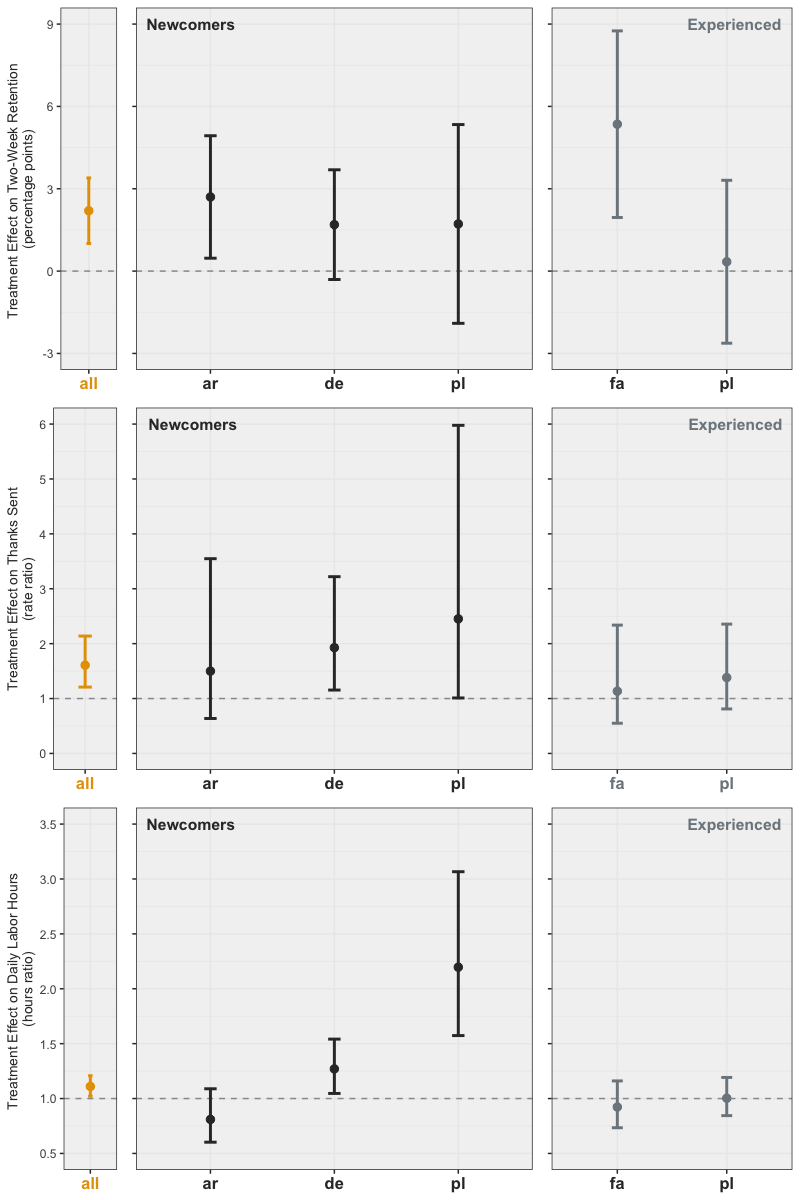

In [64]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 100)

ymax = 6
ymin = 0
scale.by = 1
lab.newc <- "Newcomers"
lab.exp <- "Experienced"

df1 <- subset(all.lang.results, model=="thanks sent" & lang == "all" & subgroup == "all")
df2 <- subset(all.lang.results, model=="thanks sent" & lang!="all" & subgroup == "newcomer")
df3 <- subset(all.lang.results, model=="thanks sent" & lang != "all" & subgroup == "experienced")

thanks.sent.est <- prettyNum(exp(df1$Estimate), digits=2)
thanks.sent.ci.lower <- prettyNum(exp(df1$CI.Lower), digits=2, format="fg")
thanks.sent.ci.upper <- prettyNum(exp(df1$CI.Upper), digits=2, format="fg")
thanks.sent.part <- prettyNum(df1$n.size, big.mark=",")
thanks.sent.new.ar <- prettyNum(subset(df2, lang=="ar")$n.size, big.mark=',')
thanks.sent.new.de <- prettyNum(subset(df2, lang=="de")$n.size, big.mark=',')
thanks.sent.new.pl <- prettyNum(subset(df2, lang=="pl")$n.size, big.mark=',')
thanks.sent.exp.fa <- prettyNum(subset(df3, lang=="fa")$n.size, big.mark=',')
thanks.sent.exp.pl <- prettyNum(subset(df3, lang=="pl")$n.size, big.mark=',')
thanks.sent.assigned.perc <-round(df1$n.thanked.count/(df1$n.size/2)*100)
thanks.sent.assigned.total <-prettyNum(df1$n.size/2, big.mark=",")
thanks.sent.assigned.dimest <- prettyNum(df1$pvalue, digits=2)



thanks.sent.ylab <- "Treatment Effect on Thanks Sent\n(rate ratio)"
thanks.sent.plot.caption <- str_interp("Organizing to thank Wikipedia volunteers caused them to thank others and increased the thanks they sent
by ${thanks.sent.est} times on average")


all.plot <- ggplot(df1, aes(lang, exp(Estimate))) +
        geom_hline(yintercept = 1, linetype="dashed", color="#999999") +
            geom_errorbar(aes(ymax=exp(CI.Upper), ymin=exp(CI.Lower)),
                          size=1, color=chartpalette[1], width=0.25) +
            geom_point(color=chartpalette[1], size=2.5) +
            ylab(thanks.sent.ylab) +
            scale_y_continuous(limits=c(ymin, ymax), breaks=seq(ymin, ymax, by=scale.by)) +
            cat.theme +
            theme(axis.title.x=element_blank(),
                  axis.text.x = element_text(size=12, face="bold", color=chartpalette[1]))



newcomer.plot <- ggplot(df2, aes(lang, exp(Estimate))) +
        geom_hline(yintercept = 1, linetype="dashed", color="#999999") +
        geom_errorbar(aes(ymax=exp(CI.Upper), ymin=exp(CI.Lower)),
                      size=1, color=chartpalette[4], width=0.1) +
        geom_point(color=chartpalette[4], size=2.5) +
        annotate(geom="text", x=0.5,y=6, label=lab.newc,
                 color=chartpalette[4], fontface=2, size=4, hjust=0) +
        scale_y_continuous(limits=c(ymin, ymax), breaks=seq(ymin, ymax, by=scale.by)) +
        cat.theme +
        theme(axis.text.y = element_blank(),
              axis.title  = element_blank(),
              axis.title.x = element_blank(),
              axis.title.y = element_blank(),
              axis.text.x = element_text(size=12, face="bold", color=chartpalette[4]))



experienced.plot <- ggplot(df3, aes(lang, exp(Estimate))) +
        geom_hline(yintercept = 1, linetype="dashed", color="#999999") +
        geom_errorbar(aes(ymax=exp(CI.Upper), ymin=exp(CI.Lower)),
                      size=1, color=chartpalette[3], width=0.1) +
        geom_point(color=chartpalette[3], size=2.5) +
        annotate(geom="text", x=1.65,y=6, label=lab.exp,
                 color=chartpalette[3], fontface=2, size=4, hjust=0) +
        scale_y_continuous(limits=c(ymin, ymax), breaks=seq(ymin, ymax, by=scale.by)) +
        cat.theme +
        theme(axis.text.y = element_blank(),
              axis.title=element_blank(),
              axis.title.x = element_blank(),
              axis.title.y = element_blank(),
              axis.text.x = element_text(size=12, face="bold", color=chartpalette[3]))

thanks.sent.plot <- ggarrange(all.plot, newcomer.plot, experienced.plot, ncol=3, nrow=1, widths=c(1.2,4, 2.5))

ggsave(file.path(figs.dir, "thanks.sent.plot.itt.png"),
       width=6, height=6, device="png", units='in',
       plot=thanks.sent.plot)

thanks.sent.plot

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 12, repr.plot.res = 100)

combined.plot <- ggarrange(retention.plot, thanks.sent.plot, labor.hours.plot, ncol=1, nrow=3, heights=c(1,1,1))

ggsave(file.path(figs.dir, "combined.plot.itt.png"),
       width=8, height=12, device="png", units='in',
       plot=combined.plot)
combined.plot

### Plot distribution of the number of thanks

=== Summary: Thanks Received by Newcomer Status ===


newcomer_label,n,n_received_any,prop_received_any,mean,median,sd,min,max
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
Experienced,5290,1130,0.2136106,0.2136106,0,0.4098937,0,1
Newcomers,9984,1572,0.1574519,0.1574519,0,0.3642446,0,1



=== Summary: Thanks Sent by Newcomer Status ===


newcomer_label,n,n_sent_any,prop_sent_any,mean,median,sd,min,max
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
Experienced,5290,267,0.05047259,0.34631380,0,5.900504,0,357
Newcomers,9984,207,0.02073317,0.05869391,0,0.693237,0,27


Warning message in scale_y_log10(labels = comma):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 96 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message in scale_y_log10(labels = comma):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 81 rows containing missing values or values outside the scale range
(`geom_bar()`).”


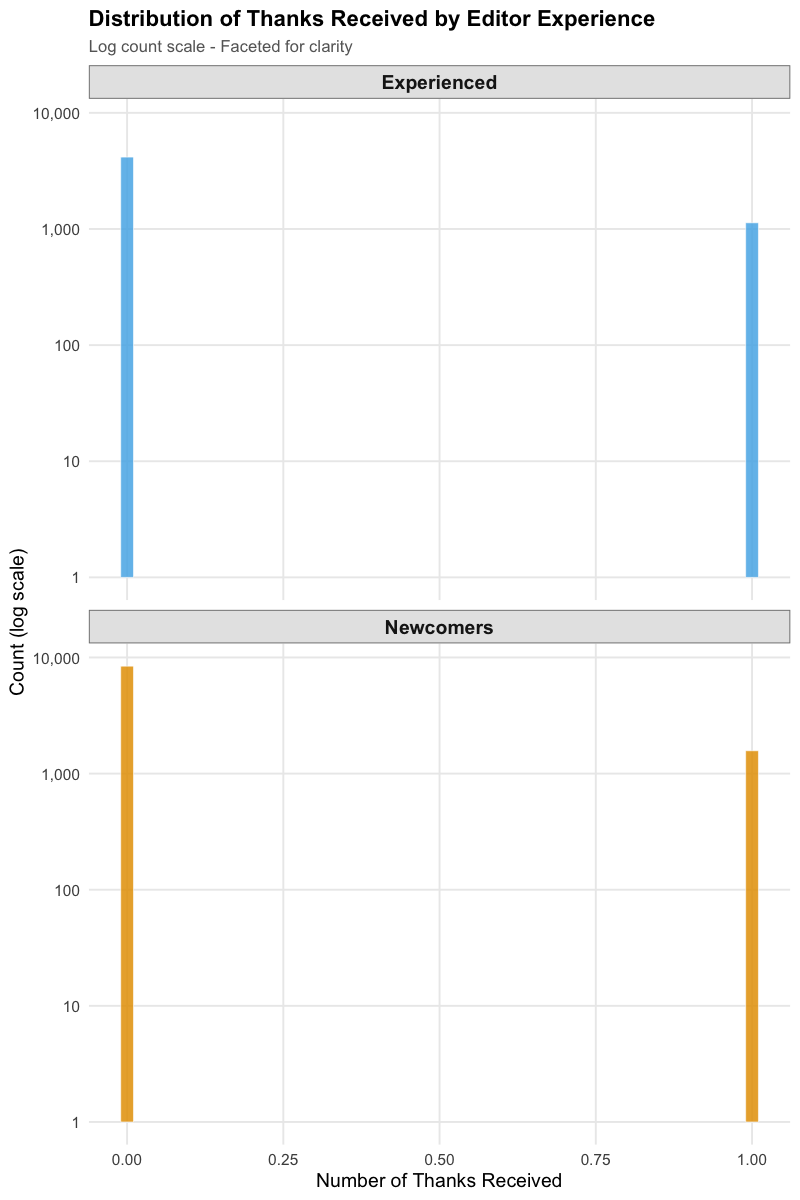

Warning message in scale_y_log10(labels = comma, breaks = c(1, 10, 100, 1000, 10000)):
“log-10 transformation introduced infinite values.”


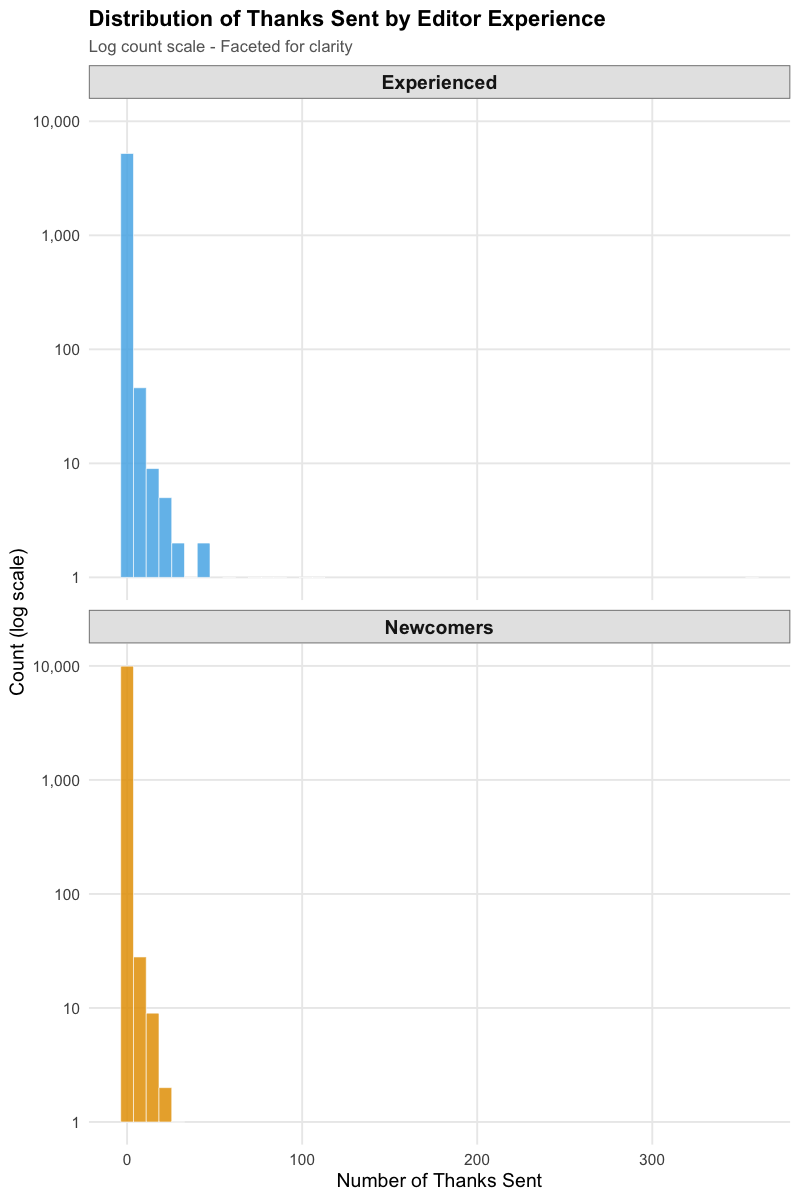

Warning message in scale_y_log10(labels = comma, breaks = c(1, 10, 100, 1000, 10000)):
“log-10 transformation introduced infinite values.”


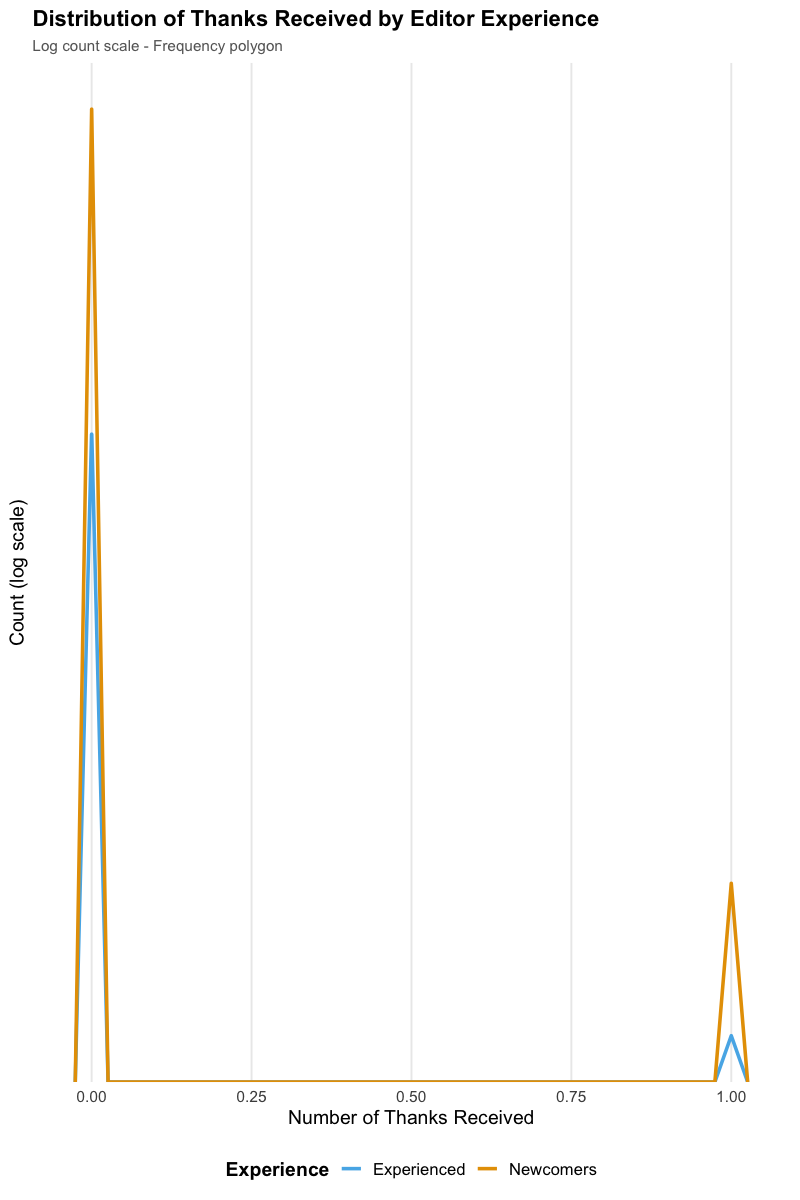

Warning message in scale_y_log10(labels = comma):
“log-10 transformation introduced infinite values.”


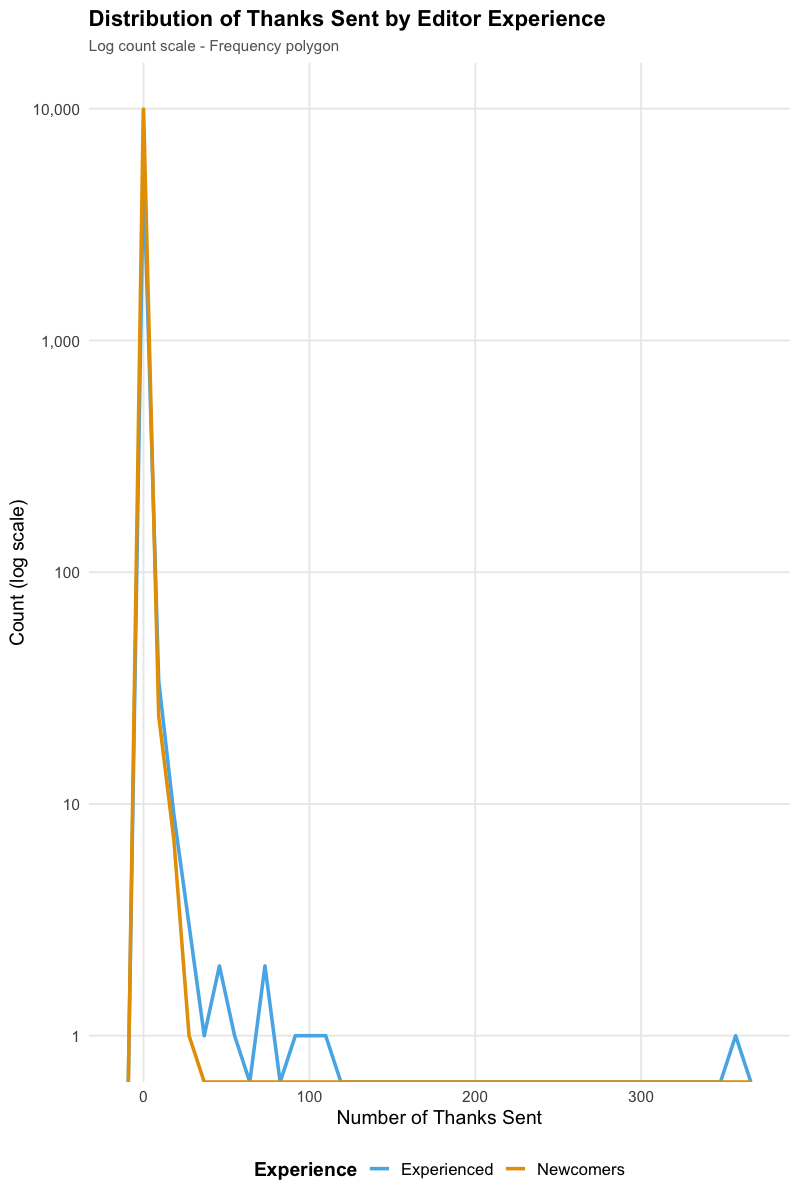

Warning message in scale_y_log10(labels = comma):
“log-10 transformation introduced infinite values.”


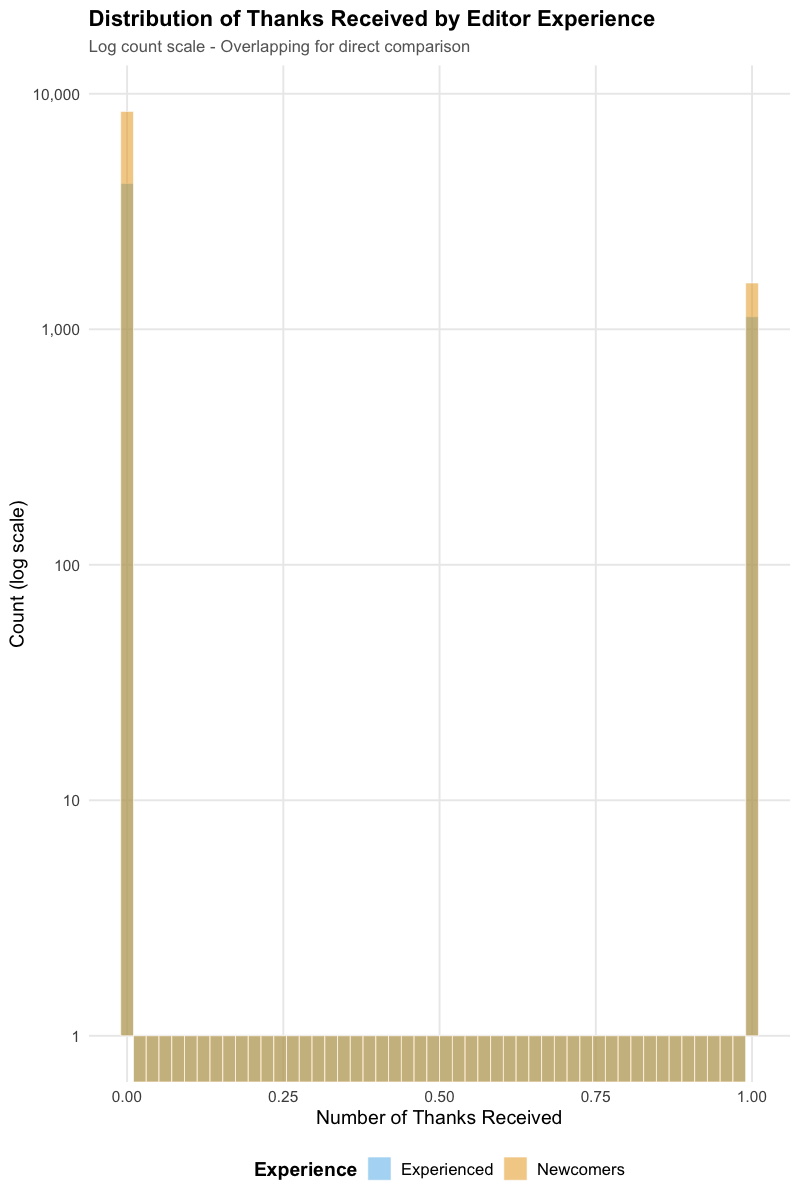

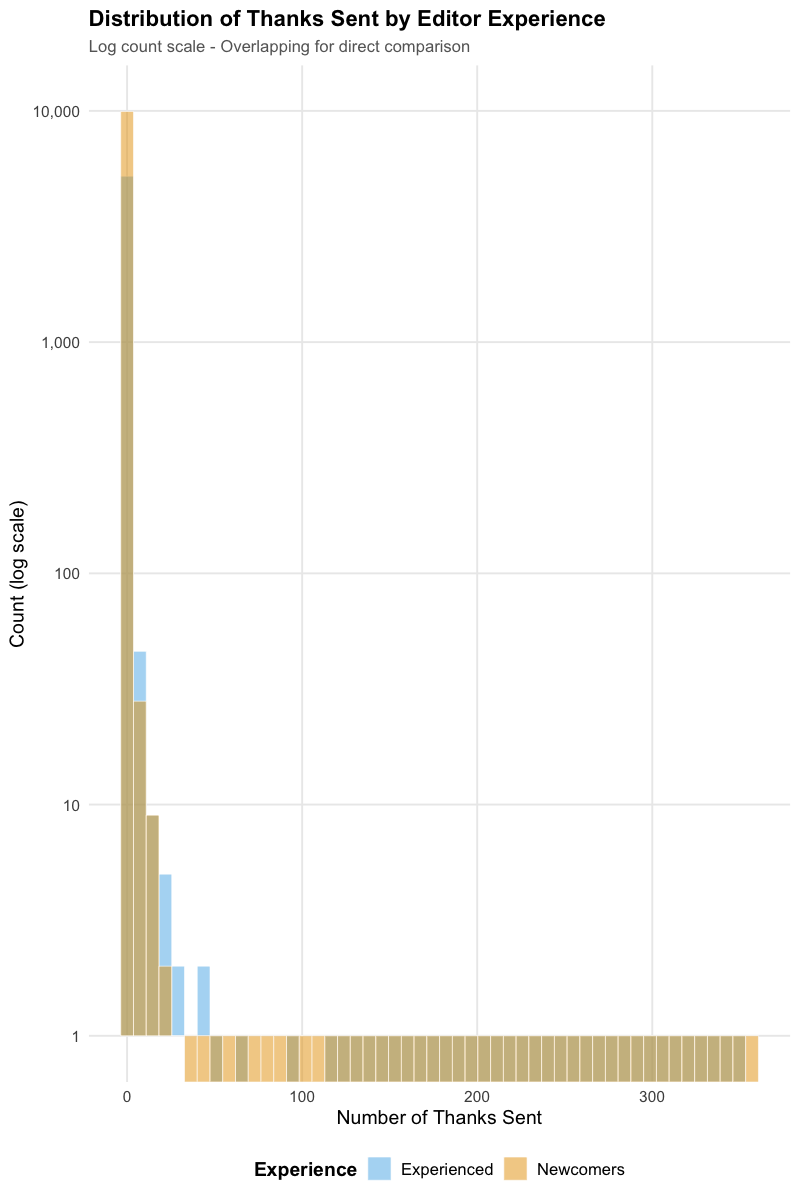

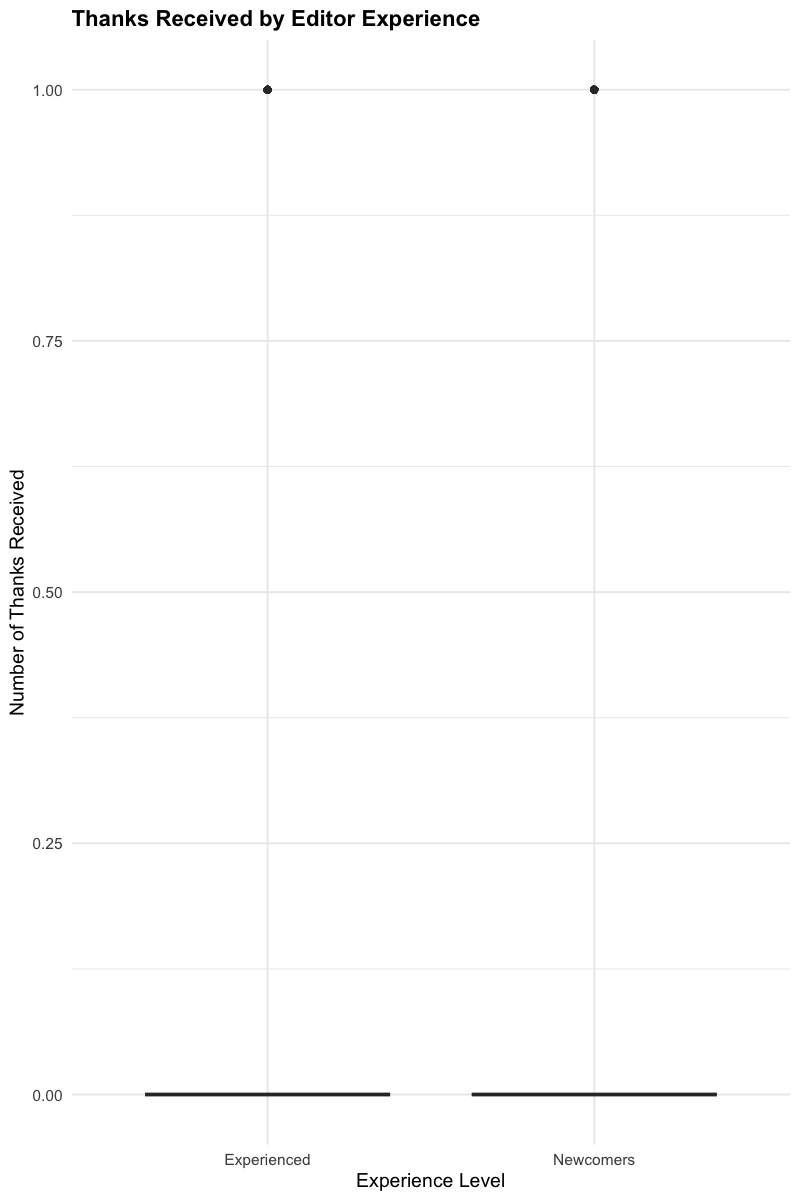

Warning message in scale_y_log10(labels = comma):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 96 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message in scale_y_log10(labels = comma):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 81 rows containing missing values or values outside the scale range
(`geom_bar()`).”


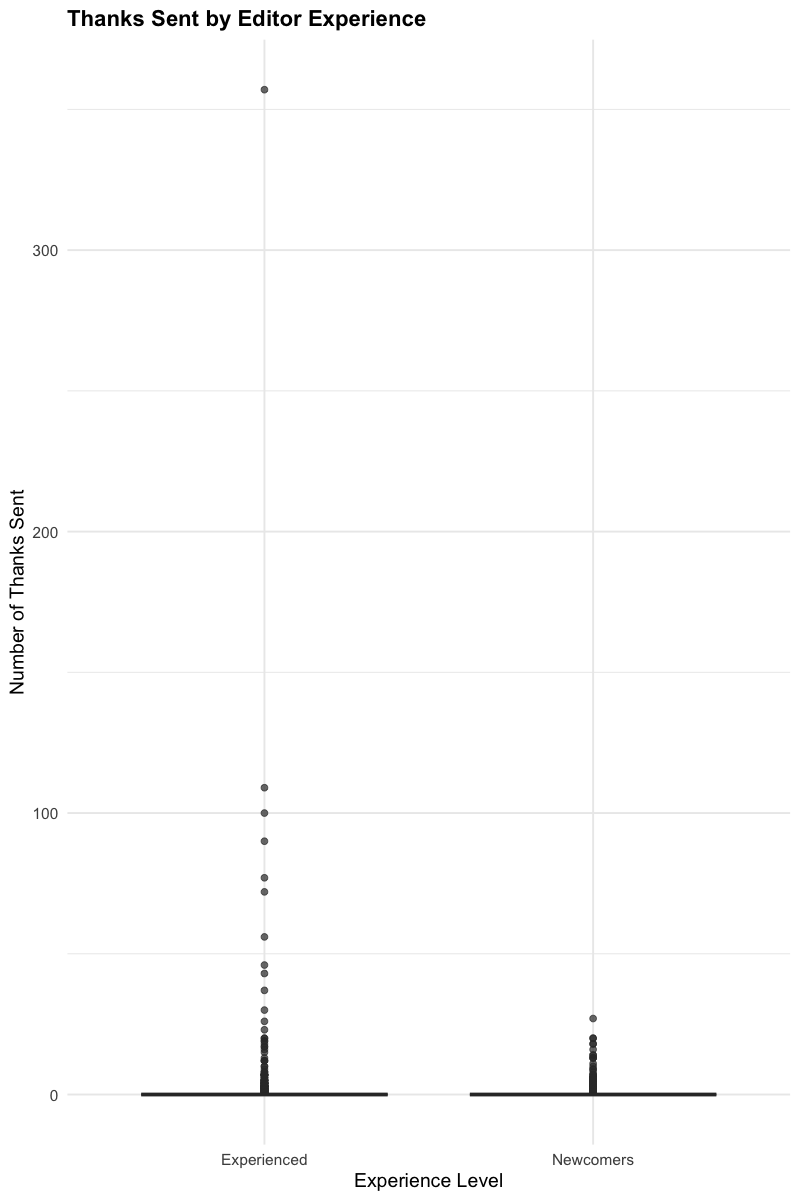

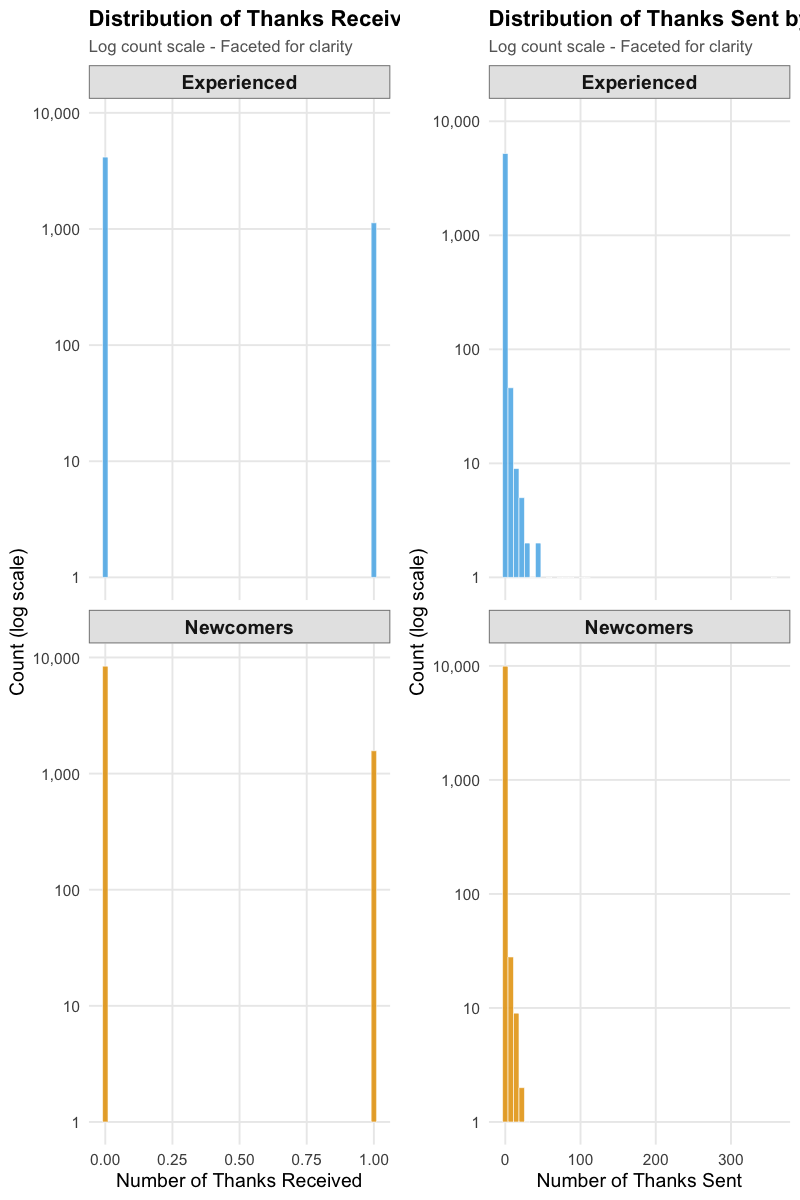

In [66]:
library(scales)

# Faceted Histograms (Best for comparison)

# Thanks Received - Faceted
p1 <- ggplot(participants, aes(x = number.thanks.received, fill = TREAT)) +
  geom_histogram(bins = 50, alpha = 0.8) +
  scale_y_log10(labels = comma) +
  scale_fill_manual(values = c("0" = "#E69F00", "1" = "#56B4E9"),
                    labels = c("Control", "Treatment")) +
  facet_wrap(~TREAT, ncol = 1,
             labeller = labeller(TREAT = c("0" = "Control", "1" = "Treatment"))) +
  labs(
    title = "Distribution of Thanks Received by Treatment Group",
    subtitle = "Log count scale for better visibility",
    x = "Number of Thanks Received",
    y = "Count (log scale)",
    fill = "Group"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "none",
    strip.text = element_text(size = 14, face = "bold"),
    strip.background = element_rect(fill = "grey90", color = "grey50"),
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 12, color = "grey40")
  )

# Thanks Sent - Faceted
p2 <- ggplot(participants, aes(x = thanks.sent, fill = TREAT)) +
  geom_histogram(bins = 50, alpha = 0.8) +
  scale_y_log10(labels = comma) +
  scale_fill_manual(values = c("0" = "#E69F00", "1" = "#56B4E9"),
                    labels = c("Control", "Treatment")) +
  facet_wrap(~TREAT, ncol = 1,
             labeller = labeller(TREAT = c("0" = "Control", "1" = "Treatment"))) +
  labs(
    title = "Distribution of Thanks Sent by Treatment Group",
    subtitle = "Log count scale for better visibility",
    x = "Number of Thanks Sent",
    y = "Count (log scale)",
    fill = "Group"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "none",
    strip.text = element_text(size = 14, face = "bold"),
    strip.background = element_rect(fill = "grey90", color = "grey50"),
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 12, color = "grey40")
  )

# Display faceted plots
print(p1)
print(p2)


# ============================================================================
# Option 2: Overlaid with Semi-Transparent Bars (Alternative view)
# ============================================================================

p3 <- ggplot(participants, aes(x = number.thanks.received, fill = TREAT)) +
  geom_histogram(bins = 50, alpha = 0.6, position = "identity") +
  scale_y_log10(labels = comma, breaks = c(1, 10, 100, 1000, 10000)) +
  scale_fill_manual(values = c("0" = "#E69F00", "1" = "#56B4E9"),
                    labels = c("Control", "Treatment")) +
  labs(
    title = "Distribution of Thanks Received (Overlaid)",
    subtitle = "Log count scale, semi-transparent for overlap visualization",
    x = "Number of Thanks Received",
    y = "Count (log scale)",
    fill = "Group"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "bottom",
    legend.title = element_text(face = "bold"),
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 12, color = "grey40"),
    panel.grid.minor = element_blank()
  )

p4 <- ggplot(participants, aes(x = thanks.sent, fill = TREAT)) +
  geom_histogram(bins = 50, alpha = 0.6, position = "identity") +
  scale_y_log10(labels = comma, breaks = c(1, 10, 100, 1000, 10000)) +
  scale_fill_manual(values = c("0" = "#E69F00", "1" = "#56B4E9"),
                    labels = c("Control", "Treatment")) +
  labs(
    title = "Distribution of Thanks Sent (Overlaid)",
    subtitle = "Log count scale, semi-transparent for overlap visualization",
    x = "Number of Thanks Sent",
    y = "Count (log scale)",
    fill = "Group"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "bottom",
    legend.title = element_text(face = "bold"),
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 12, color = "grey40"),
    panel.grid.minor = element_blank()
  )

# Display overlaid plots
print(p3)
print(p4)


# ============================================================================
# Option 3: Side-by-side with Better Binning
# ============================================================================
# Alternative: Frequency polygon (lines instead of bars)
p5 <- ggplot(participants, aes(x = number.thanks.received, color = TREAT)) +
  geom_freqpoly(bins = 40, linewidth = 1.2) +
  scale_y_log10(labels = comma,
                breaks = c(1, 10, 100, 1000, 10000)) +
  scale_color_manual(values = c("0" = "#E69F00", "1" = "#56B4E9"),
                     labels = c("Control", "Treatment")) +
  labs(
    title = "Distribution of Thanks Received",
    subtitle = "Log count scale - frequency polygon",
    x = "Number of Thanks Received",
    y = "Count (log scale)",
    color = "Group"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "bottom",
    legend.title = element_text(face = "bold"),
    legend.text = element_text(size = 12),
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 11, color = "grey40"),
    panel.grid.minor = element_blank()
  )

p6 <- ggplot(participants, aes(x = thanks.sent, color = TREAT)) +
  geom_freqpoly(bins = 40, linewidth = 1.2) +
  scale_y_log10(labels = comma,
                breaks = c(1, 10, 100, 1000, 10000)) +
  scale_color_manual(values = c("0" = "#E69F00", "1" = "#56B4E9"),
                     labels = c("Control", "Treatment")) +
  labs(
    title = "Distribution of Thanks Sent",
    subtitle = "Log count scale - frequency polygon",
    x = "Number of Thanks Sent",
    y = "Count (log scale)",
    color = "Group"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "bottom",
    legend.title = element_text(face = "bold"),
    legend.text = element_text(size = 12),
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 11, color = "grey40"),
    panel.grid.minor = element_blank()
  )
# Display side-by-side plots
print(p5)
print(p6)


combined <- grid.arrange(p1, p2, ncol = 2)


In [67]:
# Create a clean newcomer label
participants$newcomer_label <- ifelse(participants$newcomer == "TRUE",
                                      "Newcomers",
                                      "Experienced")

# Summary statistics
cat("=== Summary: Thanks Received by Newcomer Status ===\n")
participants %>%
  group_by(newcomer_label) %>%
  summarise(
    n = n(),
    n_received_any = sum(number.thanks.received > 0),
    prop_received_any = mean(number.thanks.received > 0),
    mean = mean(number.thanks.received, na.rm = TRUE),
    median = median(number.thanks.received, na.rm = TRUE),
    sd = sd(number.thanks.received, na.rm = TRUE),
    min = min(number.thanks.received, na.rm = TRUE),
    max = max(number.thanks.received, na.rm = TRUE)
  )

cat("\n=== Summary: Thanks Sent by Newcomer Status ===\n")
participants %>%
  group_by(newcomer_label) %>%
  summarise(
    n = n(),
    n_sent_any = sum(thanks.sent > 0),
    prop_sent_any = mean(thanks.sent > 0),
    mean = mean(thanks.sent, na.rm = TRUE),
    median = median(thanks.sent, na.rm = TRUE),
    sd = sd(thanks.sent, na.rm = TRUE),
    min = min(thanks.sent, na.rm = TRUE),
    max = max(thanks.sent, na.rm = TRUE)
  )

# ============================================================================
# Faceted Histograms (Best for comparison)
# ============================================================================

# Thanks Received - Faceted by Newcomer Status
p1 <- ggplot(participants, aes(x = number.thanks.received, fill = newcomer_label)) +
  geom_histogram(bins = 50, alpha = 0.85, color = "white", linewidth = 0.2) +
  scale_y_log10(labels = comma) +
  scale_fill_manual(values = c("Newcomers" = "#E69F00", "Experienced" = "#56B4E9")) +
  facet_wrap(~newcomer_label, ncol = 1) +
  labs(
    title = "Distribution of Thanks Received by Editor Experience",
    subtitle = "Log count scale - Faceted for clarity",
    x = "Number of Thanks Received",
    y = "Count (log scale)"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "none",
    strip.text = element_text(size = 14, face = "bold"),
    strip.background = element_rect(fill = "grey90", color = "grey50"),
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 12, color = "grey40"),
    panel.grid.minor = element_blank()
  )

# Thanks Sent - Faceted by Newcomer Status
p2 <- ggplot(participants, aes(x = thanks.sent, fill = newcomer_label)) +
  geom_histogram(bins = 50, alpha = 0.85, color = "white", linewidth = 0.2) +
  scale_y_log10(labels = comma) +
  scale_fill_manual(values = c("Newcomers" = "#E69F00", "Experienced" = "#56B4E9")) +
  facet_wrap(~newcomer_label, ncol = 1) +
  labs(
    title = "Distribution of Thanks Sent by Editor Experience",
    subtitle = "Log count scale - Faceted for clarity",
    x = "Number of Thanks Sent",
    y = "Count (log scale)"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "none",
    strip.text = element_text(size = 14, face = "bold"),
    strip.background = element_rect(fill = "grey90", color = "grey50"),
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 12, color = "grey40"),
    panel.grid.minor = element_blank()
  )

# Display plots
print(p1)
print(p2)

# ============================================================================
# Frequency Polygons (Alternative visualization)
# ============================================================================

p3 <- ggplot(participants, aes(x = number.thanks.received, color = newcomer_label)) +
  geom_freqpoly(bins = 40, linewidth = 1.2) +
  scale_y_log10(labels = comma, breaks = c(1, 10, 100, 1000, 10000)) +
  scale_color_manual(values = c("Newcomers" = "#E69F00", "Experienced" = "#56B4E9")) +
  labs(
    title = "Distribution of Thanks Received by Editor Experience",
    subtitle = "Log count scale - Frequency polygon",
    x = "Number of Thanks Received",
    y = "Count (log scale)",
    color = "Experience"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "bottom",
    legend.title = element_text(face = "bold"),
    legend.text = element_text(size = 12),
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 11, color = "grey40"),
    panel.grid.minor = element_blank()
  )

p4 <- ggplot(participants, aes(x = thanks.sent, color = newcomer_label)) +
  geom_freqpoly(bins = 40, linewidth = 1.2) +
  scale_y_log10(labels = comma, breaks = c(1, 10, 100, 1000, 10000)) +
  scale_color_manual(values = c("Newcomers" = "#E69F00", "Experienced" = "#56B4E9")) +
  labs(
    title = "Distribution of Thanks Sent by Editor Experience",
    subtitle = "Log count scale - Frequency polygon",
    x = "Number of Thanks Sent",
    y = "Count (log scale)",
    color = "Experience"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "bottom",
    legend.title = element_text(face = "bold"),
    legend.text = element_text(size = 12),
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 11, color = "grey40"),
    panel.grid.minor = element_blank()
  )

print(p3)
print(p4)

# ============================================================================
# Overlapping Histograms (Alternative visualization)
# ============================================================================

p_overlap_received <- ggplot(participants, aes(x = number.thanks.received, fill = newcomer_label)) +
  geom_histogram(bins = 50, alpha = 0.5, position = "identity", color = "white", linewidth = 0.2) +
  scale_y_log10(labels = comma) +
  scale_fill_manual(values = c("Newcomers" = "#E69F00", "Experienced" = "#56B4E9")) +
  labs(
    title = "Distribution of Thanks Received by Editor Experience",
    subtitle = "Log count scale - Overlapping for direct comparison",
    x = "Number of Thanks Received",
    y = "Count (log scale)",
    fill = "Experience"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "bottom",
    legend.title = element_text(face = "bold"),
    legend.text = element_text(size = 12),
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 12, color = "grey40"),
    panel.grid.minor = element_blank()
  )

p_overlap_sent <- ggplot(participants, aes(x = thanks.sent, fill = newcomer_label)) +
  geom_histogram(bins = 50, alpha = 0.5, position = "identity", color = "white", linewidth = 0.2) +
  scale_y_log10(labels = comma) +
  scale_fill_manual(values = c("Newcomers" = "#E69F00", "Experienced" = "#56B4E9")) +
  labs(
    title = "Distribution of Thanks Sent by Editor Experience",
    subtitle = "Log count scale - Overlapping for direct comparison",
    x = "Number of Thanks Sent",
    y = "Count (log scale)",
    fill = "Experience"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "bottom",
    legend.title = element_text(face = "bold"),
    legend.text = element_text(size = 12),
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 12, color = "grey40"),
    panel.grid.minor = element_blank()
  )

print(p_overlap_received)
print(p_overlap_sent)

# ============================================================================
# Box plots for comparison
# ============================================================================

p5 <- ggplot(participants, aes(x = newcomer_label, y = number.thanks.received,
                                fill = newcomer_label)) +
  geom_boxplot(alpha = 0.7) +
  scale_fill_manual(values = c("Newcomers" = "#E69F00", "Experienced" = "#56B4E9")) +
  labs(
    title = "Thanks Received by Editor Experience",
    x = "Experience Level",
    y = "Number of Thanks Received"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "none",
    plot.title = element_text(size = 16, face = "bold")
  )

p6 <- ggplot(participants, aes(x = newcomer_label, y = thanks.sent,
                                fill = newcomer_label)) +
  geom_boxplot(alpha = 0.7) +
  scale_fill_manual(values = c("Newcomers" = "#E69F00", "Experienced" = "#56B4E9")) +
  labs(
    title = "Thanks Sent by Editor Experience",
    x = "Experience Level",
    y = "Number of Thanks Sent"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "none",
    plot.title = element_text(size = 16, face = "bold")
  )

print(p5)
print(p6)

# Combined view
grid.arrange(p1, p2, ncol = 2)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  0.0000  0.1769  0.0000  1.0000 

In [68]:
summary(participants$number.thanks.received)


\begin{tabular}{llllrlll}
\toprule
  & Outcome & Estimator & Group & N & ATE & Std Error & P value\\
\midrule
TREAT1...2 & thanks sent & glm.nb & all & 15274 & 0.4745 & 0.1445 & 0.0021\\
TREAT...7 & retention & difference\_in\_means & all & 15274 & 0.0220 & 0.0061 & 0.0009\\
TREAT1...8 & labor hours per day & glmmTMB (Tweedie) & all & 15274 & 0.1048 & 0.0428 & 0.0144\\
TREAT...9 & manipulation check & difference\_in\_means & all & 767 & 0.2921 & 0.0347 & 0.0000\\
\bottomrule
\end{tabular}

In [ ]:
# Prepare the table
table_data <- all.results %>%
  dplyr::select(
    Outcome = model,
    Estimator = estimator,
    Group = subgroup,
    N = n.size,
    ATE = Estimate,
    `Std Error` = Std..Error,
    `P value` = pvalue
  ) %>%
  mutate(
    ATE = sprintf("%.4f", ATE),
    `Std Error` = sprintf("%.4f", `Std Error`),
    `P value` = sprintf("%.4f", `P value`),
    N = as.integer(N)
  )

# Generate LaTeX
cat(kable(table_data, format = "latex", booktabs = TRUE))

# Complier Average Causal Effect (Dropped Pre-Registered Analysis)
We use two stage least squares regression to estimate the complier average causal effect.

In [ ]:
# ## this method generates complier average treatment effect estimates
# ## for a given subgroup of the study. It assumes that rates of actual
# ## thanking by volunteers will vary by language and newcomer status
#
# df.cace.estimates <- function(df, lang="all", subgroup="all"){
#
#
#     treat.prob.formula <- "complier.app.any.reason ~ TREAT"
#     if(lang=="all"){
#         treat.prob.formula <- paste(treat.prob.formula, " + lang")
#     }
#
#     if(subgroup=="all"){
#         treat.prob.formula <- paste(treat.prob.formula, " + newcomer")
#     }
#
#     treat.prob.m <- lm(treat.prob.formula, data=df)
#
#     df$iv <- predict(treat.prob.m, df)
#
#     df.compliers <- subset(df, complier)
#
#
#     thanks.model         <- glm.nb(thanks.sent ~ iv, data=df)
#     m.thanks.sent        <- coef(summary(thanks.model))
#     m.thanks.sent        <- data.frame(cbind(m.thanks.sent, confint(thanks.model)))
#     names(m.thanks.sent)[4] <- "pvalue"
#     names(m.thanks.sent)[5] <- "CI.Lower"
#     names(m.thanks.sent)[6] <- "CI.Upper"
#     m.thanks.sent$DF       <- thanks.model$df.residual
#     m.thanks.sent$model    <- "thanks sent"
#     m.thanks.sent$t.value  <- NA
#     m.thanks.sent$n.size   <- nrow(df)
#     m.thanks.sent$n.thanked.count <- nrow(subset(df, complier.app.any.reason))
#
#     retention.model        <- lm(two.week.retention ~ iv, data=df)
#     m.retention            <- data.frame(coef(summary(retention.model)))
#     m.retention            <- cbind(m.retention, confint(retention.model))
#     names(m.retention)[4]  <- "pvalue"
#     names(m.retention)[5]  <- "CI.Lower"
#     names(m.retention)[6]  <- "CI.Upper"
#     m.retention$DF         <- retention.model$df
#     m.retention$model      <- "retention"
#     m.retention$z.value    <- NA
#     m.retention$n.size     <- nrow(df)
#     m.retention$n.thanked.count <- nrow(subset(df, complier.app.any.reason))
#
#     labor.hour.model       <- lm(labor.hours.per.day.diff ~ iv, data=df)
#     m.labor.hours          <- data.frame(coef(summary(labor.hour.model)))
#     m.labor.hours          <- cbind(m.labor.hours, confint(labor.hour.model))
#     names(m.labor.hours)[4] <- "pvalue"
#     names(m.labor.hours)[5] <- "CI.Lower"
#     names(m.labor.hours)[6] <- "CI.Upper"
#     m.labor.hours$DF       <- labor.hour.model$df
#     m.labor.hours$model    <- "labor hours per day"
#     m.labor.hours$z.value  <- NA
#     m.labor.hours$n.size   <- nrow(df)
#     m.labor.hours$n.thanked.count <- nrow(subset(df, complier.app.any.reason))
#
#     manip.check.model      <- lm(remembered.thanks<=3 ~ iv, data=df.compliers)
#     m.manip.check          <- data.frame(coef(summary(manip.check.model)))
#     m.manip.check          <- cbind(m.manip.check, confint(manip.check.model))
#     names(m.manip.check)[4] <- "pvalue"
#     names(m.manip.check)[5] <- "CI.Lower"
#     names(m.manip.check)[6] <- "CI.Upper"
#     m.manip.check$DF       <- manip.check.model$df
#     m.manip.check$model    <- "manipulation check"
#     m.manip.check$z.value  <- NA
#     m.manip.check$n.size   <- nrow(df.compliers)
#     m.manip.check$n.thanked.count <-  nrow(subset(df.compliers, complier.app.any.reason))
#
#     m.thanks.sent$estimator        <- "glm.nb"
#     m.retention$estimator          <- "2sls"
#     m.labor.hours$estimator        <- "2sls"
#     m.manip.check$estimator        <- "2sls"
#
#     result.df <- rbind(m.retention, m.labor.hours, m.thanks.sent,
#                        m.manip.check)
#
#     #result.df <- result.df[row.names(result.df)!="(Intercept)",]
#
#     result.df$lang     <- lang
#     result.df$subgroup <- subgroup
#
#     result.df
# }

#### Estimate CACE Results (Dropped Pre-Registered Analysis)

In [71]:
# ar.newcomer.cace.results <- df.cace.estimates(subset(participants, lang=="ar" & newcomer), lang="ar", subgroup="newcomer")
# de.newcomer.cace.results <- df.cace.estimates(subset(participants, lang=="de" & newcomer), lang="de", subgroup="newcomer")
# pl.newcomer.cace.results <- df.cace.estimates(subset(participants, lang=="pl" & newcomer), lang="pl", subgroup="newcomer")
#
# fa.experienced.cace.results <- df.cace.estimates(subset(participants, lang=="fa" & newcomer!=TRUE), lang="fa", subgroup="experienced")
# fa.experienced.cace.results <- subset(fa.experienced.cace.results,model!="labor hours per day")
#
# pl.experienced.cace.results <- df.cace.estimates(subset(participants, lang=="pl" & newcomer!=TRUE), lang="pl", subgroup="experienced")
# pl.experienced.cace.results <- subset(pl.experienced.cace.results,model!="labor hours per day")
#
# all.newcomer.cace.df <- df.cace.estimates(subset(participants, newcomer), subgroup="newcomer")
# all.experienced.cace.df <- df.cace.estimates(subset(participants, newcomer!=TRUE), subgroup="experienced")
# all.experienced.cace.df <- subset(all.experienced.cace.df,model!="labor hours per day")
#
# ## create a dataframe of the main results table
# all.cace.df <- df.cace.estimates(participants)
#
# ## create a dataframe of all results, for plotting charts
# all.cace.models.df <- rbind(
#     ar.newcomer.cace.results,
#     de.newcomer.cace.results,
#     pl.newcomer.cace.results,
#     fa.experienced.cace.results,
#     pl.experienced.cace.results,
#     all.newcomer.cace.df,
#     all.experienced.cace.df,
#     all.cace.df
#     )

In [72]:
## In case readers want to view subgroups of CACE models

In [73]:
# subset(all.cace.models.df, model =="retention" & 
#                           str_detect(row.names(all.cace.models.df), "Intercept")!=TRUE)

In [74]:
# subset(all.cace.models.df, model =="labor hours per day" & 
#                           str_detect(row.names(all.cace.models.df), "Intercept")!=TRUE)

In [ ]:
# subset(all.cace.models.df, model =="thanks sent" & 
#                           str_detect(row.names(all.cace.models.df), "Intercept")!=TRUE)

## Adjust p Values for CACE (Dropped Pre-Registered Analysis)
Here, we adjust the CACE p values for all of the pre-registered analyses, as well as the CACE analyses.

In [ ]:
# ## append all p values from the paper into a single list
# ## then adjust the p-values
# ## then return the first three, so they can be added to the adjustments
#
# all.cace.iv.df <-  cbind(factor = rownames(all.cace.df), all.cace.df)
# all.cace.iv.df <- subset(all.cace.iv.df, substring(all.cace.iv.df$factor, 0,2)=="iv")
#
# all.cace.iv.df[all.cace.iv.df$model!="manipulation check",]$pvalue <-
#         p.adjust(c(all.cace.iv.df[all.cace.iv.df$model!="manipulation check",]$pvalue,all.results.pvalues))[1:3]
# all.cace.iv.df

# Intent to Treat Model


## Plot ITT

In [77]:
dotsize = 1.5
errorsize = 1
all.lang.results <-  cbind(factor = rownames(all.lang.results), all.lang.results)

,factor,Estimate,Std..Error,z.value,pvalue,CI.Lower,CI.Upper,DF,model,t.value,n.size,n.thanked.count,estimator,lang,subgroup
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>
TREAT1...2,TREAT1...2,0.405465108,0.435633350,0.93074855,3.519836e-01,-0.451335451,1.26633115,3034.00000,thanks sent,NA,3036,189,glm.nb,ar,newcomer
TREAT...3,TREAT...3,0.027009223,0.011373685,NA,5.305927e-02,0.004699410,0.04931904,1517.00000,retention,2.3747117,3036,189,difference_in_means,ar,newcomer
TREAT1...4,TREAT1...4,-0.210701339,0.150987581,-1.39548788,3.257375e-01,-0.506631561,0.08522888,NA,labor hours per day,NA,3036,189,glmmTMB (Tweedie),ar,newcomer
TREAT...5,TREAT...5,0.200000000,0.210818511,NA,3.558411e-01,-0.244186588,0.64418659,17.30769,manipulation check,0.9486833,22,11,difference_in_means,ar,newcomer
TREAT1...21,TREAT1...21,0.656242624,0.260767478,2.51658155,3.554984e-02,0.143836569,1.16935924,5316.00000,thanks sent,NA,5318,1268,glm.nb,de,newcomer
TREAT...31,TREAT...31,0.016923656,0.010192528,NA,9.695231e-02,-0.003062433,0.03690974,2658.00000,retention,1.6603983,5318,1268,difference_in_means,de,newcomer
TREAT1...41,TREAT1...41,0.238990975,0.098793972,2.41908459,3.554984e-02,0.045358348,0.43262360,NA,labor hours per day,NA,5318,1268,glmmTMB (Tweedie),de,newcomer
TREAT...51,TREAT...51,0.369369369,0.077406029,NA,4.445988e-06,0.216366084,0.52237265,143.50657,manipulation check,4.7718424,146,74,difference_in_means,de,newcomer
TREAT1...22,TREAT1...22,0.896746136,0.449821136,1.99356158,9.239997e-02,0.010757175,1.78801209,1628.00000,thanks sent,NA,1630,115,glm.nb,pl,newcomer


In [ ]:
all.lang.results

### Plot CACE (Instrumental Variable) Estimates: Labor Hours (Dropped Pre-Registered Analysis)

In [79]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 100)

# For overall newcomer ITT effect (pooled across languages)
lh1 <- subset(all.newcomer.results, model=="labor hours per day" & lang == "all")

# For language-specific newcomer effects
lh2 <- subset(all.lang.results, model=="labor hours per day" & subgroup=="newcomer" & lang!="all")

,Estimate,Std..Error,z.value,pvalue,CI.Lower,CI.Upper,DF,model,t.value,n.size,n.thanked.count,estimator,lang,subgroup
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>
TREAT1...6,0.42729,0.07633305,5.597707,6.516174e-08,0.27768,0.5769001,NA,labor hours per day,NA,9984,1572,glmmTMB (Tweedie),all,newcomer


In [80]:
lh1

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


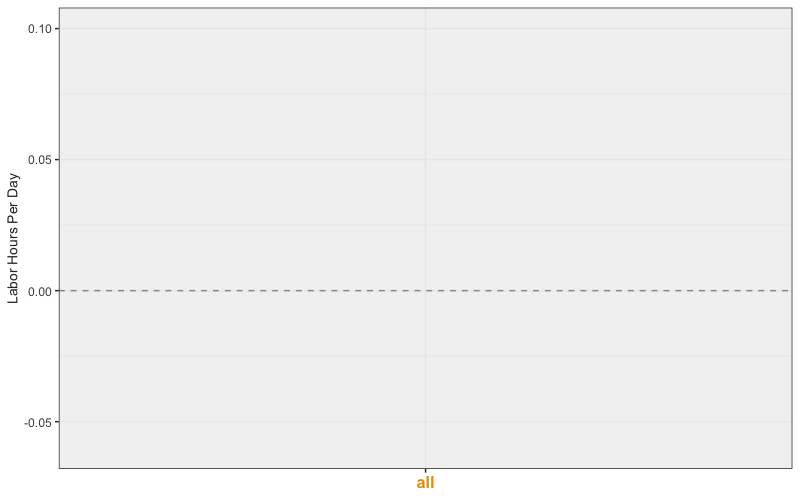

In [81]:
labor.hours.iv.participants.count <- prettyNum(lh1$n.size, big.mark=",")
labor.hours.iv.participants.count.new.ar <- prettyNum(subset(lh2, lang=="ar")$n.size, big.mark=',')
labor.hours.iv.participants.count.new.de <- prettyNum(subset(lh2, lang=="de")$n.size, big.mark=',')
labor.hours.iv.participants.count.new.pl <-prettyNum(subset(lh2, lang=="pl")$n.size, big.mark=',')
labor.hours.iv.participants.assigned.perc <-round(lh1$n.thanked.count/(lh1$n.size/2)*100)
labor.hours.iv.participants.assigned.total <-prettyNum(lh1$n.size/2, big.mark=",")
labor.hours.iv.participants.assigned.dimest <- prettyNum(lh1$pvalue, digits=2)
labor.hours.iv.ylab <- "Labor Hours Per Day"


labor.hours.iv.plot.caption <- str_interp("CACE estimates: among compliers who actually received thanks, the treatment caused an increase in daily labor hours over the following six weeks.")

In [82]:
lh.all.plot <- ggplot(lh1, aes(lang, Estimate)) +
        geom_hline(yintercept = 0, linetype="dashed", color="#999999") +
        geom_errorbar(aes(ymax=CI.Upper, ymin=CI.Lower),
                      size=errorsize, color=chartpalette[1], width=0.1) +
        geom_point(color=chartpalette[1], size=dotsize) +
        ylab(labor.hours.iv.ylab) +
        cat.theme +
        theme(axis.title.x=element_blank(),
              axis.text.x = element_text(size=12, face="bold", color=chartpalette[1])) +
        # ylim removed: let ggplot auto-scale

lh.all.plot

,factor,Estimate,Std..Error,z.value,pvalue,CI.Lower,CI.Upper,DF,model,t.value,n.size,n.thanked.count,estimator,lang,subgroup
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>
TREAT1...4,TREAT1...4,-0.2107013,0.15098758,-1.395488,3.257375e-01,-0.50663156,0.08522888,NA,labor hours per day,NA,3036,189,glmmTMB (Tweedie),ar,newcomer
TREAT1...41,TREAT1...41,0.2389910,0.09879397,2.419085,3.554984e-02,0.04535835,0.43262360,NA,labor hours per day,NA,5318,1268,glmmTMB (Tweedie),de,newcomer
TREAT1...42,TREAT1...42,0.7868729,0.17018243,4.623702,1.130853e-05,0.45332145,1.12042433,NA,labor hours per day,NA,1630,115,glmmTMB (Tweedie),pl,newcomer


Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


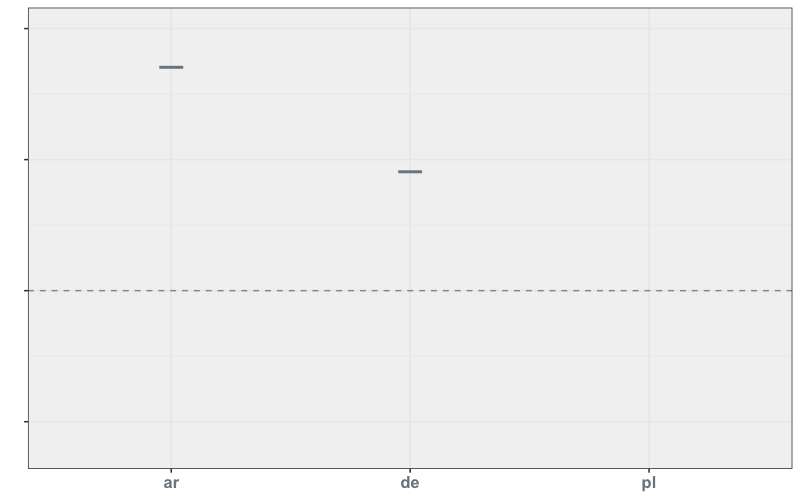

In [83]:
lh2

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


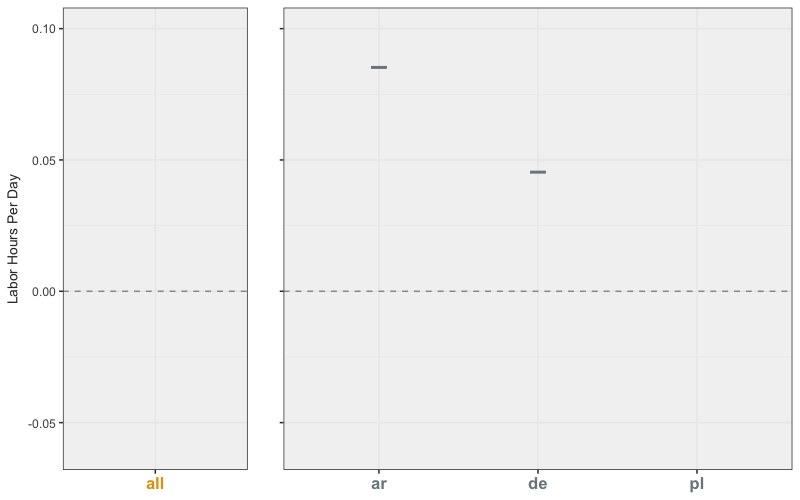

In [84]:
lh.lang.plot <- ggplot(lh2, aes(lang, Estimate)) +
        geom_hline(yintercept = 0, linetype="dashed", color="#999999") +
        geom_errorbar(aes(ymax=CI.Upper, ymin=CI.Lower),
                      size=errorsize, color=chartpalette[3], width=0.1) +
        geom_point(color=chartpalette[3], size=dotsize) +
        cat.theme +
        theme(axis.text.y = element_blank(),
              axis.title  = element_blank(),
              axis.title.x=element_blank(),
              axis.text.x = element_text(size=12, face="bold", color=chartpalette[3])) +
         ylab("") +
         xlab("") +
        ylim(min(lh2$CI.Lower, na.rm = TRUE) - 0.01, max(lh2$CI.Upper, na.rm = TRUE) + 0.01)

lh.lang.plot

In [ ]:
labor.hours.iv.plot <- ggarrange(lh.all.plot, lh.lang.plot, ncol=2, nrow=1, widths=c(1.5,3.2))

ggsave(file.path(figs.dir, "labor.hours.iv.plot.pdf"),
       width=6, height=2, units='in', device="pdf",
       plot=labor.hours.iv.plot)

labor.hours.iv.plot


### Plot CACE (Instrumental Variable) Estimates: Two-Week Retention (Dropped Pre-Registered Analysis)

In [86]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 100)

ymax = 0.5
ymin = -0.2

In [87]:
#all.lang.results
twr1 <- subset(all.lang.results, model=="retention" & lang == "all" & subgroup == "all")
twr2 <- subset(all.lang.results, model=="retention" & lang!="all" & subgroup == "newcomer")
# twr3 <- subset(all.newcomer.results, model=="retention")
twr4 <- subset(all.lang.results, model=="retention" & lang != "all" & subgroup == "experienced")

In [88]:
retention.iv.plot.est <- prettyNum(twr1$Estimate*100, digits=1, format="fg")
retention.iv.plot.count.part <-prettyNum(twr1$n.size, big.mark=",")
retention.iv.plot.count.part.new.ar <- prettyNum(subset(twr2, lang=="ar")$n.size, big.mark=',')
retention.iv.plot.count.part.new.de <- prettyNum(subset(twr2, lang=="de")$n.size, big.mark=',')
retention.iv.plot.count.part.new.pl <- prettyNum(subset(twr2, lang=="pl")$n.size, big.mark=',')
retention.iv.plot.count.part.exp.fa <- prettyNum(subset(twr4, lang=="fa")$n.size, big.mark=',')
retention.iv.plot.count.part.exp.pl <-prettyNum(subset(twr4, lang=="pl")$n.size, big.mark=',')
retention.iv.plot.participants.assigned.perc <-round(twr1$n.thanked.count/(twr1$n.size/2)*100)
retention.iv.plot.participants.assigned.total <-prettyNum(twr1$n.size/2, big.mark=",")
retention.iv.plot.participants.assigned.dimest <- prettyNum(twr1$pvalue, digits=2)

retention.iv.plot.ylab <- "Effect on Two\nWeek Retention"
retention.iv.plot.caption <- str_interp(
    "Organized thanking increases two-week retention of Wikipedia contributors by ${retention.iv.plot.est} percentage
points on average among experienced and newcomer accounts")

,factor,Estimate,Std..Error,z.value,pvalue,CI.Lower,CI.Upper,DF,model,t.value,n.size,n.thanked.count,estimator,lang,subgroup
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>
TREAT...71,TREAT...71,0.02199817,0.006097696,NA,0.0009329827,0.01004501,0.03395133,7636,retention,3.60762,15274,2702,difference_in_means,all,all


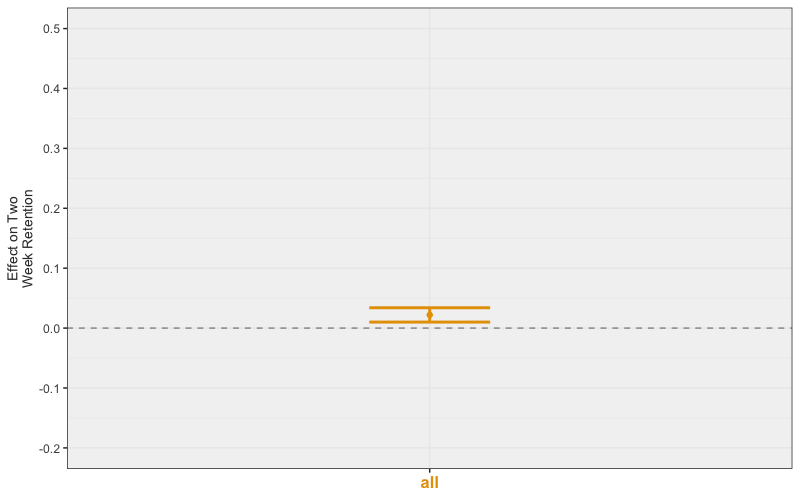

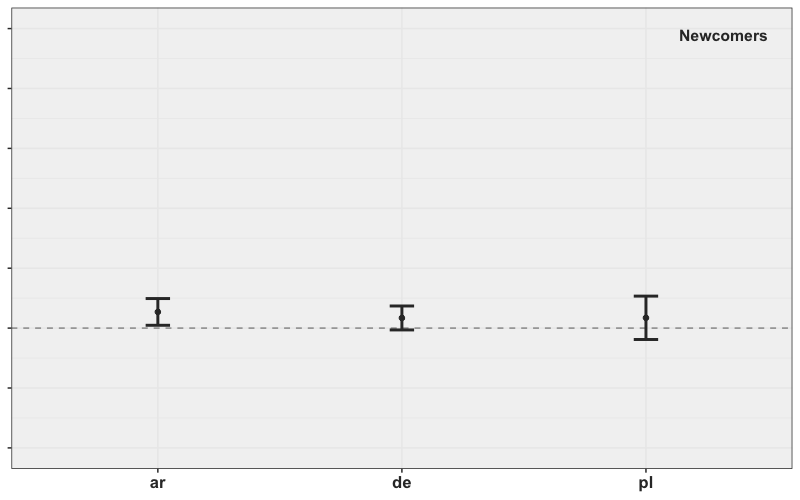

In [89]:
twr1

In [90]:
twr.all.plot <- ggplot(twr1, aes(lang, Estimate)) +
        geom_hline(yintercept = 0, linetype="dashed", color="#999999") +
            geom_errorbar(aes(ymax=CI.Upper, ymin=CI.Lower),
                          size=errorsize, color=chartpalette[1], width=0.2) +
            geom_point(color=chartpalette[1], size=dotsize) +
            ylab(retention.iv.plot.ylab) +
            scale_y_continuous(limits=c(ymin, ymax), breaks=seq(ymin, ymax, by=0.1)) +
            cat.theme +
            theme(axis.title.x=element_blank(),
                  axis.text.x = element_text(size=12, face="bold", color=chartpalette[1]))

twr.all.plot

twr.lang.plot <- ggplot(twr2, aes(lang, Estimate)) +
        geom_hline(yintercept = 0, linetype="dashed", color="#999999") +
        geom_errorbar(aes(ymax=CI.Upper, ymin=CI.Lower),
                      size=errorsize, color=chartpalette[4], width=0.1) +
        geom_point(color=chartpalette[4], size=dotsize) +
        annotate(geom="text", x=3.5,y=0.49, label=lab.newc,
                 color=chartpalette[4], fontface=2, size=4, hjust=1) +
        scale_y_continuous(limits=c(ymin, ymax), breaks=seq(ymin, ymax, by=0.1)) +
        cat.theme +
        theme(axis.text.y = element_blank(),
              axis.title.y = element_blank(),
              axis.title  = element_blank(),
              axis.title.x = element_blank(),
              axis.text.x = element_text(size=12, face="bold", color=chartpalette[4]))
twr.lang.plot

,factor,Estimate,Std..Error,z.value,pvalue,CI.Lower,CI.Upper,DF,model,t.value,n.size,n.thanked.count,estimator,lang,subgroup
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>
TREAT...33,TREAT...33,0.053525913,0.01732848,NA,0.006168324,0.01952773,0.08752410,1176,retention,3.0888986,2354,75,difference_in_means,fa,experienced
TREAT...34,TREAT...34,0.003405995,0.01512996,NA,1.000000000,-0.02627267,0.03308466,1467,retention,0.2251159,2936,1055,difference_in_means,pl,experienced


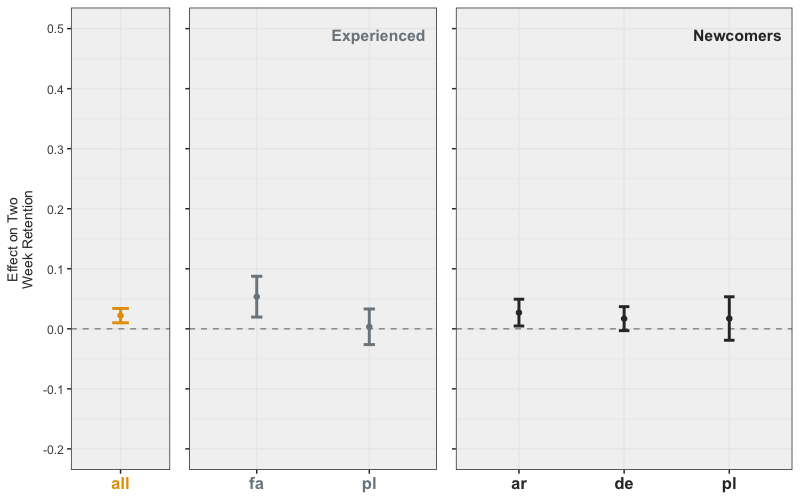

In [91]:
twr4

In [ ]:
twr.experienced.plot <- ggplot(twr4, aes(lang, Estimate)) +
        geom_hline(yintercept = 0, linetype="dashed", color="#999999") +
        geom_errorbar(aes(ymax=CI.Upper, ymin=CI.Lower),
                      size=errorsize, color=chartpalette[3], width=0.1) +
        geom_point(color=chartpalette[3], size=dotsize) +
        annotate(geom="text", x=2.5,y=0.49, label=lab.exp,
                 color=chartpalette[3], fontface=2, size=4, hjust=1) +
        scale_y_continuous( limits=c(ymin, ymax), breaks=seq(ymin, ymax, by=0.1)) +
        cat.theme +
        theme(axis.text.y = element_blank(),
              axis.title=element_blank(),
              axis.title.x = element_blank(),
              axis.title.y = element_blank(),
              axis.text.x = element_text(size=12, face="bold", color=chartpalette[3]))

#twr.experienced.plot
retention.iv.plot <- ggarrange(twr.all.plot, twr.experienced.plot, twr.lang.plot, ncol=3, nrow=1, widths=c(2,3, 4))

ggsave(file.path(figs.dir, "retention.iv.plot.pdf"),
       width=6, height=2, device="pdf", units='in',
       plot=retention.iv.plot)

## keep for compatibility with previous versions of ggplot2
# retention.iv.plot <- annotate_figure(retention.plot,
#                         bottom=text_grob(retention.iv.plot.caption, 
#                                          hjust=0, x=0, size=10, 
#                                          color=chartpalette[4]))+
#                           width=6, height=3.375 , units='in')
retention.iv.plot

### Plot CACE (Instrumental Variable) Estimates: Rate of Thanks (Dropped Pre-Registered Analysis)

In [93]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 100)

ymax = 15
ymin = -10
scale.by = 5
rt1 <- subset(all.lang.results, model=="thanks sent" & lang == "all" & subgroup == "all")
rt2 <- subset(all.lang.results, model=="thanks sent" & lang!="all" & subgroup == "newcomer")
rt3 <- subset(all.lang.results, model=="thanks sent" & lang != "all" & subgroup == "experienced")

thanks.sent.iv.est <- prettyNum(exp(rt1$Estimate), digits=2)
thanks.sent.iv.ci.lower <- prettyNum(exp(rt1$CI.Lower), digits=2, format="fg")
thanks.sent.iv.ci.upper <- prettyNum(exp(rt1$CI.Upper), digits=2, format="fg")
thanks.sent.iv.part <- prettyNum(rt1$n.size, big.mark=",")
thanks.sent.iv.new.ar <- prettyNum(subset(rt2, lang=="ar")$n.size, big.mark=',')
thanks.sent.iv.new.de <- prettyNum(subset(rt2, lang=="de")$n.size, big.mark=',')
thanks.sent.iv.new.pl <- prettyNum(subset(rt2, lang=="pl")$n.size, big.mark=',')
thanks.sent.iv.exp.fa <- prettyNum(subset(rt3, lang=="fa")$n.size, big.mark=',')
thanks.sent.iv.exp.pl <- prettyNum(subset(rt3, lang=="pl")$n.size, big.mark=',')
thanks.sent.iv.assigned.perc <-round(rt1$n.thanked.count/(rt1$n.size/2)*100)
thanks.sent.iv.assigned.total <-prettyNum(rt1$n.size/2, big.mark=",")
thanks.sent.iv.assigned.dimest <- prettyNum(rt1$pvalue, digits=2)


thanks.sent.iv.ylab <- "Negative binomial estimate\nof thanks sent"
thanks.sent.iv.plot.caption <- str_interp("Organizing to thank Wikipedia volunteers caused them to thank others and increased the thanks they sent
by ${thanks.sent.iv.est} times on average")
#thanks.sent.iv.plot.caption
#rt3

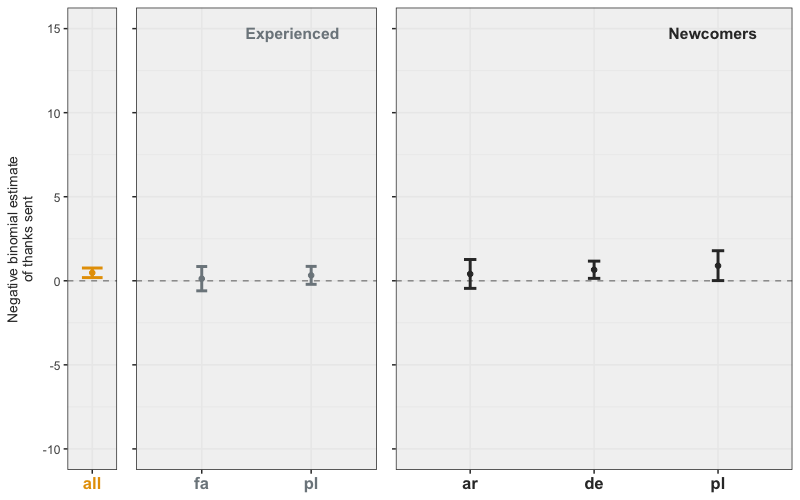

In [94]:
rt.all.plot <- ggplot(rt1, aes(lang, Estimate)) +
        geom_hline(yintercept = 0, linetype="dashed", color="#999999") +
            geom_errorbar(aes(ymax=CI.Upper, ymin=CI.Lower),
                          size=1, color=chartpalette[1], width=0.5) +
            geom_point(color=chartpalette[1], size=dotsize) +
            ylab(thanks.sent.iv.ylab) +
            scale_y_continuous(limits=c(ymin, ymax), breaks=seq(ymin, ymax, by=scale.by)) +
            cat.theme +
            theme(axis.title.x=element_blank(),
                  axis.text.x = element_text(size=12, face="bold", color=chartpalette[1]))



rt.newcomer.plot <- ggplot(rt2, aes(lang, Estimate)) +
        geom_hline(yintercept = 0, linetype="dashed", color="#999999") +
        geom_errorbar(aes(ymax=CI.Upper, ymin=CI.Lower),
                      size=1, color=chartpalette[4], width=0.1) +
        geom_point(color=chartpalette[4], size=dotsize) +
        annotate(geom="text", x=2.6,y=ymax-0.25, label=lab.newc,
                 color=chartpalette[4], fontface=2, size=4, hjust=0) +
        scale_y_continuous(limits=c(ymin, ymax), breaks=seq(ymin, ymax, by=scale.by)) +
        cat.theme +
        theme(axis.text.y = element_blank(),
              axis.title  = element_blank(),
              axis.title.x = element_blank(),
              axis.title.y = element_blank(),
              axis.text.x = element_text(size=12, face="bold", color=chartpalette[4]))


rt.experienced.plot <- ggplot(rt3, aes(lang, Estimate)) +
        geom_hline(yintercept = 0, linetype="dashed", color="#999999") +
        geom_errorbar(aes(ymax=CI.Upper, ymin=CI.Lower),
                      size=1, color=chartpalette[3], width=0.1) +
        geom_point(color=chartpalette[3], size=dotsize) +
        annotate(geom="text", x=1.4,y=ymax-0.25, label=lab.exp,
                 color=chartpalette[3], fontface=2, size=4, hjust=0) +
        scale_y_continuous( limits=c(ymin, ymax), breaks=seq(ymin, ymax, by=scale.by)) +
        cat.theme +
        theme(axis.text.y = element_blank(),
              axis.title=element_blank(),
              axis.title.x = element_blank(),
              axis.title.y = element_blank(),
              axis.text.x = element_text(size=12, face="bold", color=chartpalette[3]))

# rt.newcomer.plot
# rt.all.plot
#rt.experienced.plot

In [ ]:
thanks.sent.iv.plot <- ggarrange(rt.all.plot,  rt.experienced.plot, rt.newcomer.plot, ncol=3, nrow=1, widths=c(1.2,2.5, 4))

ggsave(file.path(figs.dir, "thanks.sent.iv.plot.pdf"),
    width=6, height=2, device="pdf", units='in',
    plot = thanks.sent.iv.plot)

# thanks.sent.iv.plot <- annotate_figure(thanks.sent.iv.plot,
#                         bottom=text_grob(thanks.sent.iv.plot.caption, 
#                                          hjust=0, x=0, size=10, 
#                                          color=chartpalette[4]))+
#                           width=6, height=4 , units='in')
thanks.sent.iv.plot

# Analyze Participant Thanks

In [96]:
colnames(participant.thanks)

[1] "according to the thanks dataset,  266 treatment group accounts sent thanks"
[1] "according to the earlier participant dataset,  261 treatment group accounts sent thanks"


In [97]:
print(paste("according to the thanks dataset, ", nrow(subset(participant.thanks, identifiable.thanks.sent>0 & condition=="1")), "treatment group accounts sent thanks"))

print(paste("according to the earlier participant dataset, ", nrow(subset(participants, thanks.sent>0 & TREAT==1)), "treatment group accounts sent thanks"))

[1] "according to the thanks dataset 1505 thanks were sent by treatment group accounts"
[1] "according to the participant dataset 1418 thanks were sent by treatment group accounts"


In [98]:
print(paste("according to the thanks dataset", sum(subset(participant.thanks, condition=='1')$identifiable.thanks.sent), "thanks were sent by treatment group accounts"))

print(paste("according to the participant dataset", sum(subset(participants, TREAT==1)$thanks.sent), "thanks were sent by treatment group accounts"))

[1] "condition"                 "identifiable.thanks.sent" 
[3] "reciprocal.thanks.sent"    "nonreciprocal.thanks.sent"
[5] "lang"

In [99]:
colnames(participant.thanks)

In [100]:
#participant.thanks
participant.thanks$any.reciprocal.thanks <- as.integer(participant.thanks$reciprocal.thanks.sent>0)
participant.thanks$any.nonreciprocal.thanks <- as.integer(participant.thanks$nonreciprocal.thanks.sent>0)

lang,reciprocal.thanks.sent,nonreciprocal.thanks.sent,any.reciprocal.thanks,any.nonreciprocal.thanks
<chr>,<int>,<int>,<int>,<int>
ar,0,91,0,36
de,1,404,1,130
fa,2,748,2,105
pl,3,1303,3,216


In [101]:
treat.reciprocal.thanks.df <- aggregate( . ~ lang,
                                        data=participant.thanks[c('reciprocal.thanks.sent',
                                                                  'nonreciprocal.thanks.sent',
                                                                  'any.reciprocal.thanks',
                                                                  'any.nonreciprocal.thanks',
                                                                  'lang')],
                                        FUN=sum)
treat.reciprocal.thanks.df

[1] "99.8"

In [ ]:
## percentage of thanks sent to people who did not thank them
prettyNum(sum(treat.reciprocal.thanks.df$nonreciprocal.thanks.sent)/ (sum(treat.reciprocal.thanks.df$nonreciprocal.thanks.sent) + sum(treat.reciprocal.thanks.df$reciprocal.thanks.sent))*100, digits=3)

## Second-Generation Thanks Cross-Tabulations (Tables S10–S12)

Numeric content for the SI's second-generation tables: senders by group/language, onset lag from randomization to first second-gen thanks sent, recipient distribution, and community-relative rates standardized by Wikistats active-editor counts. The .tex rendering of these tables is hand-coded in `supporting-information-2.tex` from the console output below.

In [103]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
})

# Build a participant-level lookup for sender/recipient join
participant.info <- all.participants.max %>%
  dplyr::select(user.id.anonymous, randomization.arm, prev.experience.assignment, lang, created.dt) %>%
  distinct(user.id.anonymous, .keep_all = TRUE) %>%
  rename(TREAT = randomization.arm) %>%
  mutate(newcomer = prev.experience.assignment == "bin_0",
         experience = ifelse(newcomer, "Newcomer", "Experienced"),
         randomization.date = as.Date(created.dt))

# Filter to valid second-gen thanks events
second.gen <- all.thanks %>%
  filter(second.gen.thank.ts != "" & !is.na(second.gen.thank.ts))

second.gen.full <- second.gen %>%
  left_join(
    participant.info %>%
      dplyr::select(user.id.anonymous, TREAT, experience, lang, newcomer) %>%
      rename(sender.TREAT = TREAT, sender.exp = experience,
             sender.lang  = lang,  sender.newcomer = newcomer),
    by = c("second.gen.sender.user.id.anonymous" = "user.id.anonymous")
  ) %>%
  left_join(
    participant.info %>%
      dplyr::select(user.id.anonymous, TREAT, experience, lang, newcomer) %>%
      rename(recipient.TREAT = TREAT, recipient.exp = experience,
             recipient.lang  = lang,  recipient.newcomer = newcomer),
    by = c("second.gen.recipient.user.id.anonymous" = "user.id.anonymous")
  ) %>%
  mutate(dt = as.Date(second.gen.thank.ts),
         month = format(dt, "%Y-%m"),
         sender.group = ifelse(sender.TREAT == 1, "Treated", "Control"))

cat("Total second-gen thanks:", nrow(second.gen.full), "\n")
cat("Recipient is a participant:    ", sum(!is.na(second.gen.full$recipient.TREAT)), "\n")
cat("Recipient is NOT a participant:", sum(is.na(second.gen.full$recipient.TREAT)), "\n")



=== Recipient-Side Distribution (by sender language) ===
# A tibble: 4 × 7
  sender.lang Control `Non-participant` Treated Total Pct.to.control
  <chr>         <int>             <int>   <int> <int>          <dbl>
1 ar                6                74      11    91           35.3
2 de                7               390       8   405           46.7
3 fa               74               552     124   750           37.4
4 pl              130               428     748  1306           14.8
# ℹ 1 more variable: Pct.to.treated <dbl>

=== Second-Gen Thanks SENT by Treatment Group (by Language) ===
# A tibble: 4 × 6
  sender.lang Control Treated Total Pct.Control Ratio.Treated.to.Control
  <chr>         <int>   <int> <int>       <dbl>                    <dbl>
1 ar               48      43    91        52.7                     0.9 
2 de              139     266   405        34.3                     1.91
3 fa              318     432   750        42.4                     1.36
4 pl              54

In [104]:
# Recipient-side distribution (by sender language)
cat("\n=== Recipient-Side Distribution (by sender language) ===\n")
recipient.dist <- second.gen.full %>%
  mutate(recipient.status = case_when(
    is.na(recipient.TREAT) ~ "Non-participant",
    recipient.TREAT == 1   ~ "Treated",
    recipient.TREAT == 0   ~ "Control"
  )) %>%
  group_by(sender.lang, recipient.status) %>%
  summarise(count = n(), .groups = "drop") %>%
  pivot_wider(names_from = recipient.status, values_from = count, values_fill = 0) %>%
  mutate(Total = Control + Treated + `Non-participant`,
         Pct.to.control = round(100 * Control / (Control + Treated), 1),
         Pct.to.treated = round(100 * Treated / (Control + Treated), 1))
print(recipient.dist)

# Second-gen thanks SENT by treatment group (by language)
cat("\n=== Second-Gen Thanks SENT by Treatment Group (by Language) ===\n")
sent.by.lang <- second.gen.full %>%
  group_by(sender.lang, sender.group) %>%
  summarise(count = n(), .groups = "drop") %>%
  pivot_wider(names_from = sender.group, values_from = count, values_fill = 0) %>%
  mutate(Total = Control + Treated,
         Pct.Control = round(100 * Control / Total, 1),
         Ratio.Treated.to.Control = round(Treated / Control, 2))
print(sent.by.lang)

# Unique senders and thanks-per-sender
cat("\n=== Unique Senders and Thanks Per Sender ===\n")
senders.summary <- second.gen.full %>%
  group_by(sender.lang, sender.group) %>%
  summarise(thanks.count = n(),
            unique.senders = n_distinct(second.gen.sender.user.id.anonymous),
            thanks.per.sender = round(n() / n_distinct(second.gen.sender.user.id.anonymous), 1),
            .groups = "drop")
print(senders.summary)



=== SENDER-LEVEL ONSET LAG (Table S10) ===
# A tibble: 8 × 6
  sender.lang sender.group n.senders median.onset.lag q25.onset q75.onset
  <chr>       <chr>            <int>            <dbl>     <dbl>     <dbl>
1 ar          Control             19             19         9.5      26  
2 ar          Treated             17             25         7        29  
3 de          Control             51             16         8        34.5
4 de          Treated             78             20        10.2      30.8
5 fa          Control             40              8.5       3        25.2
6 fa          Treated             62             16         6        29.2
7 pl          Control             75              7         3        12  
8 pl          Treated            109             25        15        39  

=== Overall onset lag totals ===
# A tibble: 2 × 5
  sender.group n.senders median.onset q25.onset q75.onset
  <chr>            <int>        <dbl>     <dbl>     <dbl>
1 Control            185      

In [105]:
# Sender-level onset lag (median days from randomization to first second-gen thanks sent)
second.gen.with.randomization <- second.gen.full %>%
  left_join(
    participant.info %>% dplyr::select(user.id.anonymous, randomization.date),
    by = c("second.gen.sender.user.id.anonymous" = "user.id.anonymous")
  ) %>%
  filter(!is.na(randomization.date)) %>%
  mutate(lag.days = as.numeric(dt - randomization.date),
         valid.lag = lag.days >= 0)

cat("\n=== SENDER-LEVEL ONSET LAG (Table S10) ===\n")
sender.onset.lag <- second.gen.with.randomization %>%
  filter(valid.lag) %>%
  group_by(sender.lang, sender.group, second.gen.sender.user.id.anonymous) %>%
  summarise(first.lag = min(lag.days), .groups = "drop") %>%
  group_by(sender.lang, sender.group) %>%
  summarise(n.senders = n(),
            median.onset.lag = median(first.lag),
            q25.onset = quantile(first.lag, 0.25),
            q75.onset = quantile(first.lag, 0.75),
            .groups = "drop")
print(sender.onset.lag)

cat("\n=== Overall onset lag totals ===\n")
overall.onset <- second.gen.with.randomization %>%
  filter(valid.lag) %>%
  group_by(sender.group, second.gen.sender.user.id.anonymous) %>%
  summarise(first.lag = min(lag.days), .groups = "drop") %>%
  group_by(sender.group) %>%
  summarise(n.senders = n(),
            median.onset = median(first.lag),
            q25.onset = quantile(first.lag, 0.25),
            q75.onset = quantile(first.lag, 0.75),
            .groups = "drop")
print(overall.onset)

# Recipients who are study participants — treated vs control split
cat("\n=== Recipients Who Are Study Participants (Table S11) ===\n")
recipient.by.lang <- second.gen.full %>%
  filter(!is.na(recipient.TREAT)) %>%
  group_by(sender.lang) %>%
  summarise(total.participant.recipients = n(),
            recipient.treated = sum(recipient.TREAT == 1),
            recipient.control = sum(recipient.TREAT == 0),
            pct.recipient.control = round(100 * mean(recipient.TREAT == 0), 1),
            .groups = "drop")
print(recipient.by.lang)

# By language and sender experience
cat("\n=== By Language and Sender Experience ===\n")
by.lang.exp <- second.gen.full %>%
  group_by(sender.lang, sender.exp, sender.group) %>%
  summarise(count = n(), .groups = "drop") %>%
  pivot_wider(names_from = sender.group, values_from = count, values_fill = 0) %>%
  mutate(Total = Control + Treated,
         Pct.Control = round(100 * Control / Total, 1))
print(by.lang.exp)


Loading active-editor counts from: ../data/active-user-count 
  lang active.users
1   ar          959
2   de         6348
3   fa         1317
4   pl         1462

=== Community-Relative Statistics (Table S12) ===
# A tibble: 4 × 15
  sender.lang total.thanks unique.recipients.all unique.recipients.nonpart
  <chr>              <int>                 <int>                     <int>
1 ar                    91                    49                        38
2 de                   405                   247                       237
3 fa                   750                   195                       117
4 pl                  1306                   906                       151
# ℹ 11 more variables: unique.senders <int>, active.users <dbl>,
#   total.participants <int>, treated <int>, control <int>,
#   pct.participants.of.active <dbl>, thanks.per.1000.active <dbl>,
#   pct.reach.all <dbl>, pct.reach.nonpart <dbl>,
#   pct.senders.of.participants <dbl>, recipients.per.sender <dbl>

Done.


In [ ]:
# Community-relative statistics (Table S12) — needs Wikistats active-editor counts
active.user.dir <- Sys.getenv("WIKIPEDIA_ACTIVE_USER_DIR", "")
if (active.user.dir == "" || !dir.exists(active.user.dir)) {
  for (.d in c("data/active-user-count", "../data/active-user-count", "../data/active_user_count",
               "osf-submission/data/active-user-count",
               "active user count", "active-user-count",
               "../active user count", "../active-user-count")) {
    if (dir.exists(.d)) { active.user.dir <- .d; break }
  }
}
if (!dir.exists(active.user.dir)) stop(
  "Cannot locate the active-user-count folder. ",
  "Set the WIKIPEDIA_ACTIVE_USER_DIR env var."
)
cat("Loading active-editor counts from:", active.user.dir, "\n")

au.ar <- read.csv(file.path(active.user.dir, "active user arabic.csv"))
au.de <- read.csv(file.path(active.user.dir, "active user german.csv"))
au.fa <- read.csv(file.path(active.user.dir, "active user persian.csv"))
au.pl <- read.csv(file.path(active.user.dir, "active user polish.csv"))

get_study_avg <- function(df) {
  df$date <- as.Date(df$month)
  study <- df %>% filter(date >= as.Date("2019-08-01") & date <= as.Date("2020-02-01"))
  round(mean(study$total.total))
}

active.users <- data.frame(
  lang = c("ar", "de", "fa", "pl"),
  active.users = c(get_study_avg(au.ar), get_study_avg(au.de),
                   get_study_avg(au.fa), get_study_avg(au.pl)))
print(active.users)

participants.by.lang <- participant.info %>%
  group_by(lang) %>%
  summarise(total.participants = n(),
            treated = sum(TREAT == 1),
            control = sum(TREAT == 0),
            .groups = "drop")

unique.stats <- second.gen.full %>%
  group_by(sender.lang) %>%
  summarise(total.thanks = n(),
            unique.recipients.all = n_distinct(second.gen.recipient.user.id.anonymous),
            unique.recipients.nonpart = n_distinct(second.gen.recipient.user.id.anonymous[is.na(recipient.TREAT)]),
            unique.senders = n_distinct(second.gen.sender.user.id.anonymous),
            .groups = "drop")

cat("\n=== Community-Relative Statistics (Table S12) ===\n")
community.table <- unique.stats %>%
  left_join(active.users, by = c("sender.lang" = "lang")) %>%
  left_join(participants.by.lang, by = c("sender.lang" = "lang")) %>%
  mutate(pct.participants.of.active   = round(100 * total.participants / active.users, 1),
         thanks.per.1000.active       = round(1000 * total.thanks / active.users, 1),
         pct.reach.all                = round(100 * unique.recipients.all / active.users, 1),
         pct.reach.nonpart            = round(100 * unique.recipients.nonpart / active.users, 1),
         pct.senders.of.participants  = round(100 * unique.senders / total.participants, 1),
         recipients.per.sender        = round(unique.recipients.all / unique.senders, 1))
print(community.table)
cat("\nDone.\n")


# Pre-dropped results

In [ ]:
# Tag each observation as dropped or kept
dropped.blocks <- unique(c(
  subset(all.participants, thanks.not.received.user.deleted)$block,
  subset(all.participants, received.multiple.thanks)$block
))

all.participants$dropped <- all.participants$block %in% dropped.blocks
cat("Dropped:", sum(all.participants$dropped),
    "| Kept:", sum(!all.participants$dropped),
    "| Total:", nrow(all.participants), "\n")

## 1. Characteristics Table: Dropped vs. Kept

### 1a. Drop Reason Breakdown

In [ ]:

cat("=== Blocks flagged for removal ===\n")
blocks.deleted  <- subset(all.participants, thanks.not.received.user.deleted)$block
blocks.multiple <- unique(subset(all.participants, received.multiple.thanks)$block)

cat("Blocks with deleted accounts:       ", length(unique(blocks.deleted)), "\n")
cat("Blocks with multiple thanks:        ", length(unique(blocks.multiple)), "\n")
cat("Overlap (in both):                  ",
    length(intersect(unique(blocks.deleted), unique(blocks.multiple))), "\n")
cat("Total unique blocks removed:        ", length(dropped.blocks), "\n")
cat("Participants in removed blocks:     ", sum(all.participants$dropped), "\n")

### 1b. Treatment Assignment Balance

In [ ]:
treat.tab <- all.participants %>%
  mutate(Status = ifelse(dropped, "Dropped", "Kept")) %>%
  group_by(Status, TREAT) %>%
  summarise(N = n(), .groups = "drop") %>%
  pivot_wider(names_from = TREAT, values_from = N, names_prefix = "TREAT_")

kable(treat.tab, caption = "Treatment assignment: Dropped vs. Kept")

### 1c. Language Distribution

In [ ]:
lang.tab <- all.participants %>%
  mutate(Status = ifelse(dropped, "Dropped", "Kept")) %>%
  group_by(Status, lang) %>%
  summarise(N = n(), .groups = "drop") %>%
  pivot_wider(names_from = lang, values_from = N, values_fill = 0)

kable(lang.tab, caption = "Language distribution: Dropped vs. Kept")

### 1d. Newcomer vs. Experienced

In [ ]:
newcomer.tab <- all.participants %>%
  mutate(Status = ifelse(dropped, "Dropped", "Kept"),
         Group  = ifelse(newcomer, "Newcomer", "Experienced")) %>%
  group_by(Status, Group) %>%
  summarise(N = n(), .groups = "drop") %>%
  pivot_wider(names_from = Group, values_from = N, values_fill = 0)

kable(newcomer.tab, caption = "Newcomer status: Dropped vs. Kept")

### 1e. Previous Experience Days

In [ ]:
exp.tab <- all.participants %>%
  mutate(Status = ifelse(dropped, "Dropped", "Kept")) %>%
  group_by(Status) %>%
  summarise(
    N     = n(),
    Mean  = mean(prev.experience.assignment.days, na.rm = TRUE),
    SD    = sd(prev.experience.assignment.days, na.rm = TRUE),
    Median = median(prev.experience.assignment.days, na.rm = TRUE),
    .groups = "drop"
  )

kable(exp.tab, digits = 2, caption = "Previous experience (days): Dropped vs. Kept")

### 1f. Pre-Treatment Outcomes

In [ ]:
outcome.tab <- all.participants %>%
  mutate(Status = ifelse(dropped, "Dropped", "Kept")) %>%
  group_by(Status) %>%
  summarise(
    N = n(),
    # Two-week retention
    retention.rate   = mean(two.week.retention, na.rm = TRUE),
    # Thanks sent
    thanks.sent.mean = mean(thanks.sent, na.rm = TRUE),
    thanks.sent.sd   = sd(thanks.sent, na.rm = TRUE),
    # Labor hours (pre-treatment)
    labor.hrs.pre.mean   = mean(labor.hours.pre.treatment, na.rm = TRUE),
    labor.hrs.pre.sd     = sd(labor.hours.pre.treatment, na.rm = TRUE),
    labor.hrs.pre.median = median(labor.hours.pre.treatment, na.rm = TRUE),
    # Labor hours per day (pre-treatment)
    labor.hrpd.pre.mean   = mean(labor.hours.per.day.pre.treatment, na.rm = TRUE),
    labor.hrpd.pre.sd     = sd(labor.hours.per.day.pre.treatment, na.rm = TRUE),
    labor.hrpd.pre.median = median(labor.hours.per.day.pre.treatment, na.rm = TRUE),
    # Post-treatment outcomes
    labor.hrs.post.mean   = mean(labor.hours.post.treatment, na.rm = TRUE),
    labor.hrpd.post.mean  = mean(labor.hours.per.day.post.treatment, na.rm = TRUE),
    .groups = "drop"
  )

kable(outcome.tab, digits = 4, caption = "Pre- and post-treatment outcomes: Dropped vs. Kept")

## 2. Pre-Drop Results (Full Sample, N = 15,558)

Re-run the primary ITT models on `all.participants` (before block removal).
Results are compared to the post-drop estimates from the main notebook.

### 2a. Prepare Pre-Drop Data

In [ ]:
# Center pre-treatment covariates on the full sample
all.participants$centered.labor.hours.pre.treatment <-
  scale(all.participants$labor.hours.pre.treatment, center = TRUE, scale = FALSE)
all.participants$centered.labor.hours.per.day.pre.treatment <-
  scale(all.participants$labor.hours.per.day.pre.treatment, center = TRUE, scale = FALSE)

cat("Full sample size:", nrow(all.participants), "\n")
cat("Blocks:", length(unique(all.participants$block)), "\n")

### 2b. ITT: Thanks Sent (Negative Binomial)

In [ ]:
thanks.model.pre <- glm.nb(thanks.sent ~ TREAT + lang + newcomer, data = all.participants)
cat("=== Thanks Sent (glm.nb) — Pre-Drop (N =", nrow(all.participants), ") ===\n")
summary(thanks.model.pre)
confint(thanks.model.pre)

### 2c. ITT: Two-Week Retention (Difference in Means)

In [ ]:
retention.pre <- difference_in_means(two.week.retention ~ TREAT,
                                      blocks = block, ci = TRUE,
                                      data = all.participants)
cat("=== Retention (difference_in_means) — Pre-Drop (N =", nrow(all.participants), ") ===\n")
summary(retention.pre)

### 2d. ITT: Labor Hours Per Day (Tweedie GLMM)

In [ ]:
# Baseline
cat("=== Labor Hours Per Day: Baseline — Pre-Drop ===\n")
lm.pre.baseline <- glmmTMB(
  labor.hours.per.day.post.treatment ~ TREAT + (1 | block),
  data = all.participants,
  family = tweedie(link = "log")
)
summary(lm.pre.baseline)

# With covariate
cat("\n=== Labor Hours Per Day: With Covariate — Pre-Drop ===\n")
lm.pre.cov <- glmmTMB(
  labor.hours.per.day.post.treatment ~ TREAT + centered.labor.hours.per.day.pre.treatment + (1 | block),
  data = all.participants,
  family = tweedie(link = "log")
)
summary(lm.pre.cov)

# With interaction (reported in df.estimates)
cat("\n=== Labor Hours Per Day: With Interaction — Pre-Drop ===\n")
lm.pre.int <- glmmTMB(
  labor.hours.per.day.post.treatment ~ TREAT * centered.labor.hours.per.day.pre.treatment + (1 | block),
  data = all.participants,
  family = tweedie(link = "log")
)
summary(lm.pre.int)

### 2e. ITT: Total Labor Hours (Tweedie GLMM)

In [ ]:
# Baseline
cat("=== Total Labor Hours: Baseline — Pre-Drop ===\n")
lm.total.pre.baseline <- glmmTMB(
  labor.hours.post.treatment ~ TREAT + (1 | block),
  data = all.participants,
  family = tweedie(link = "log")
)
summary(lm.total.pre.baseline)

# With covariate
cat("\n=== Total Labor Hours: With Covariate — Pre-Drop ===\n")
lm.total.pre.cov <- glmmTMB(
  labor.hours.post.treatment ~ TREAT + centered.labor.hours.pre.treatment + (1 | block),
  data = all.participants,
  family = tweedie(link = "log")
)
summary(lm.total.pre.cov)

# With interaction
cat("\n=== Total Labor Hours: With Interaction — Pre-Drop ===\n")
lm.total.pre.int <- glmmTMB(
  labor.hours.post.treatment ~ TREAT * centered.labor.hours.pre.treatment + (1 | block),
  data = all.participants,
  family = tweedie(link = "log")
)
summary(lm.total.pre.int)

### 2f. Aggregate ITT Results (Using df.estimates Function)

This uses the same `df.estimates()` function defined in the notebook to produce
directly comparable output.

In [ ]:
# Re-use the df.estimates function from the notebook (must already be defined)
# Run on the full pre-drop sample
all.results.pre.drop <- df.estimates(all.participants)

# Adjust for multiple comparisons (same Holm method as main analysis)
all.results.pre.drop.pvalues <- all.results.pre.drop[all.results.pre.drop$model != "manipulation check", ]$pvalue
all.results.pre.drop[all.results.pre.drop$model != "manipulation check", ]$pvalue <-
  p.adjust(all.results.pre.drop[all.results.pre.drop$model != "manipulation check", ]$pvalue, method = "holm")

cat("=== Aggregate ITT Results — Pre-Drop (N =", nrow(all.participants), ") ===\n")
print(all.results.pre.drop[, c("model", "estimator", "subgroup", "n.size",
                                 "Estimate", "Std..Error", "pvalue", "CI.Lower", "CI.Upper")])

### 2g. Side-by-Side Comparison

In [ ]:
# Post-drop results (already computed in notebook as `all.results`)
# Re-label for clarity
post <- all.results[, c("model", "Estimate", "Std..Error", "pvalue", "CI.Lower", "CI.Upper", "n.size")]
post$sample <- "Post-Drop (N=15274)"

pre <- all.results.pre.drop[, c("model", "Estimate", "Std..Error", "pvalue", "CI.Lower", "CI.Upper", "n.size")]
pre$sample <- "Pre-Drop (N=15558)"

comparison <- bind_rows(pre, post) %>%
  arrange(model, sample)

kable(comparison, digits = 6, caption = "Side-by-side: Pre-Drop vs. Post-Drop ITT Estimates (Holm-adjusted p-values)")

# Write SI Tables (.tex output)

Sources `si_tables.R` and writes the six Supporting Information tables (`balance_table.tex`, `predrop_results_table.tex`, `si_table_pooled_itt.tex`, `si_table_lang_itt.tex`, `si_table_labor_full.tex`, `thanks_distribution_table.tex`) to `tables.dir`. Captions live in `si_tables.R::si_captions` and are reused by `supporting-information-2.Rtex` via `\Sexpr{}` so the .tex artifacts and the SI always stay in sync.

In [ ]:
# Resolve si_tables.R relative to wherever the notebook is being run from.
si_tables_path <- if (basename(getwd()) == "code") "si_tables.R" else "osf-submission/code/si_tables.R"
source(si_tables_path)

written <- write_si_tex_files(
  out_dir                       = tables.dir,
  participants                  = participants,
  all.results.pre.drop          = all.results.pre.drop,
  all.results                   = all.results,
  all.lang.results              = all.lang.results,
  labor_per_day_results         = labor_per_day_results,
  first.gen.data                = first.gen.data,
  treated.thanks.in.all.thanks  = treated.thanks.in.all.thanks,
  control.thanks.in.all.thanks  = control.thanks.in.all.thanks,
  n_pre                         = nrow(all.participants),
  n_post                        = nrow(participants)
)
cat("Wrote", length(written), "SI tables to", tables.dir, ":\n")
cat(paste(" -", basename(written)), sep = "\n")


# Save Data for LaTeX file

In [ ]:
dfs<-Filter(function(x) is.data.frame(get(x)) , ls())
save(list=dfs, file=file.path(rdata.out, "paper-data.RData"), version = 2) # overleaf uses R 3.4 which requires version 2 of Rdata I believe